# <center> <b> <span style="color: #FF0000"> [G'CONTEST 2024] - ROUND 4 - TÊN BÀI THI

#### <left> <b> <span style="color: #FF0000"> Team Tomorrow Data Analysts
#### <left> <b> <i> <span style="color: #000000 "> Đinh An Khánh
#### <left> <b> <i> <span style="color: #000000 "> Hoàng Việt Hưng
#### <left> <b> <i> <span style="color: #000000 "> An Đức Trung


#**I. BUSINESS UNDERSTANDING**

##**Import Data**

In [1]:
import pandas as pd
import numpy as np
import re
import gdown

def extract_drive_id(url):
    """
    Hàm nhận vào URL Google Drive và trả về File ID.
    Hỗ trợ cả dạng /file/d/ và open?id=
    """
    patterns = [
        r"https://drive\.google\.com/file/d/([a-zA-Z0-9_-]+)",  # dạng /file/d/ID
        r"id=([a-zA-Z0-9_-]+)"                                  # dạng ?id=ID
    ]
    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    return None

# --- Nhập URL Google Drive ---
url = "https://drive.google.com/file/d/1MKTd9DGwEaacXrCu3-LXI0BXy1fQrOZD/view?usp=drive_link"

# --- Trích xuất file ID ---
file_id = extract_drive_id(url)

if file_id:
    print("🎯 File ID extracted:", file_id)

    # --- Tải file về với tên cụ thể ---
    output_file = "du_lieu_vong_3.csv"
    gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

    # --- Đọc file CSV bằng pandas ---
    try:
        df = pd.read_csv(output_file)
        print("✅ Đọc dữ liệu thành công!")
        display(df.head())  # Chỉ hoạt động trong Colab/Jupyter
    except Exception as e:
        print("❌ Lỗi khi đọc file CSV:", e)
else:
    print("❌ Không tìm thấy file ID từ link.")


🎯 File ID extracted: 1MKTd9DGwEaacXrCu3-LXI0BXy1fQrOZD


Downloading...
From: https://drive.google.com/uc?id=1MKTd9DGwEaacXrCu3-LXI0BXy1fQrOZD
To: /content/du_lieu_vong_3.csv
100%|██████████| 2.21M/2.21M [00:00<00:00, 12.5MB/s]


✅ Đọc dữ liệu thành công!


,begin_time,close_time,onboarding_status,gender,birth_year,device_type,device_system_name,os_version,rejected_reason,drop_off_point,cus_id
0,02/02/2024 16:52,02/02/2024 17:55,SUCCESSFUL,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,SUCCESSFUL,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,SUCCESSFUL,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,SUCCESSFUL,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,SUCCESSFUL,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672


## Dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25746 entries, 0 to 25745
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   begin_time          25746 non-null  object 
 1   close_time          25746 non-null  object 
 2   onboarding_status   25746 non-null  object 
 3   gender              15012 non-null  object 
 4   birth_year          15094 non-null  float64
 5   device_type         20665 non-null  object 
 6   device_system_name  20665 non-null  object 
 7   os_version          20665 non-null  object 
 8   rejected_reason     3067 non-null   object 
 9   drop_off_point      25746 non-null  object 
 10  cus_id              25746 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 2.2+ MB


In [3]:
# prompt: df.customerid.nunique

print(df['cus_id'].nunique())

9148


In [4]:
# prompt: df.begin_time.min and max

print("Min begin_time:", df.begin_time.min())
print("Max begin_time:", df.begin_time.max())

Min begin_time: 01/02/2024 05:39
Max begin_time: 31/03/2024 21:05


In [5]:
df.describe(include = 'all')

,begin_time,close_time,onboarding_status,gender,birth_year,device_type,device_system_name,os_version,rejected_reason,drop_off_point,cus_id
count,25746,25746,25746,15012,15094.000000,20665,20665,20665,3067,25746,25746.000000
unique,10558,10198,3,2,NaN,24,3,95,12,7,NaN
top,29/02/2024 13:48,29/02/2024 13:47,PENDING,F,NaN,Apple,iOS,17.3.1,document-ocr-failed,account-creation,NaN
freq,172,171,11281,8481,NaN,16036,16014,5491,2622,8543,NaN
mean,NaN,NaN,NaN,NaN,1990.220419,NaN,NaN,NaN,NaN,NaN,4554.582537
std,NaN,NaN,NaN,NaN,9.700667,NaN,NaN,NaN,NaN,NaN,2632.626100
min,NaN,NaN,NaN,NaN,1199.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,1986.000000,NaN,NaN,NaN,NaN,NaN,2315.250000
50%,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN,4526.000000
75%,NaN,NaN,NaN,NaN,1995.000000,NaN,NaN,NaN,NaN,NaN,6822.750000


In [6]:
df.head(20)

,begin_time,close_time,onboarding_status,gender,birth_year,device_type,device_system_name,os_version,rejected_reason,drop_off_point,cus_id
0,02/02/2024 16:52,02/02/2024 17:55,SUCCESSFUL,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,SUCCESSFUL,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,SUCCESSFUL,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,SUCCESSFUL,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,SUCCESSFUL,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672
5,28/02/2024 15:29,28/02/2024 15:32,SUCCESSFUL,M,1997.0,Apple,iOS,17.3.1,NaN,account-creation,3255
6,28/02/2024 15:23,28/02/2024 15:27,SUCCESSFUL,F,1978.0,samsung,Android,12,NaN,account-creation,2800
7,28/02/2024 15:21,28/02/2024 15:24,SUCCESSFUL,M,1989.0,samsung,Android,14,NaN,account-creation,4195
8,29/02/2024 13:38,29/02/2024 13:42,SUCCESSFUL,F,1992.0,Apple,iOS,17.3.1,NaN,account-creation,331
9,29/02/2024 13:32,29/02/2024 13:34,SUCCESSFUL,F,1999.0,Apple,iOS,17.3.1,NaN,account-creation,1585


In [7]:
df.isna().sum()

,0
begin_time,0
close_time,0
onboarding_status,0
gender,10734
birth_year,10652
device_type,5081
device_system_name,5081
os_version,5081
rejected_reason,22679
drop_off_point,0


In [8]:
df.isna().mean() * 100


,0
begin_time,0.000000
close_time,0.000000
onboarding_status,0.000000
gender,41.691913
birth_year,41.373417
device_type,19.735104
device_system_name,19.735104
os_version,19.735104
rejected_reason,88.087470
drop_off_point,0.000000


#**II. Data Preparation**

##**Tiền chỉnh sửa Data**

In [9]:
# prompt: Đổi tên cột onboarding_status thành status, device_type thành phone_type, drop_off point thành stop_point, cus_id thành customer_id

# Đổi tên các cột
df = df.rename(columns={
    'onboarding_status': 'status',
    'device_type': 'phone_type',
    'drop_off_point': 'stop_point',
    'cus_id': 'customer_id'
})

print("✅ Đã đổi tên các cột.")
display(df.head())

✅ Đã đổi tên các cột.


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,02/02/2024 16:52,02/02/2024 17:55,SUCCESSFUL,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,SUCCESSFUL,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,SUCCESSFUL,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,SUCCESSFUL,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,SUCCESSFUL,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672


In [10]:
# prompt: Lower các giá trị trong cột status

df['status'] = df['status'].str.lower()
print("✅ Đã chuyển đổi giá trị cột 'status' sang chữ thường.")
display(df.head())

✅ Đã chuyển đổi giá trị cột 'status' sang chữ thường.


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,02/02/2024 16:52,02/02/2024 17:55,successful,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,successful,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,successful,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,successful,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,successful,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672


In [11]:
df['status'] = df['status'].replace('successful', 'succeed')
df['status'] = df['status'].replace('failed', 'fail')


In [12]:
df.head(20)

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,02/02/2024 16:52,02/02/2024 17:55,succeed,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,succeed,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,succeed,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,succeed,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,succeed,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672
5,28/02/2024 15:29,28/02/2024 15:32,succeed,M,1997.0,Apple,iOS,17.3.1,NaN,account-creation,3255
6,28/02/2024 15:23,28/02/2024 15:27,succeed,F,1978.0,samsung,Android,12,NaN,account-creation,2800
7,28/02/2024 15:21,28/02/2024 15:24,succeed,M,1989.0,samsung,Android,14,NaN,account-creation,4195
8,29/02/2024 13:38,29/02/2024 13:42,succeed,F,1992.0,Apple,iOS,17.3.1,NaN,account-creation,331
9,29/02/2024 13:32,29/02/2024 13:34,succeed,F,1999.0,Apple,iOS,17.3.1,NaN,account-creation,1585


In [13]:
df.phone_type.value_counts

<bound method IndexOpsMixin.value_counts of 0          Apple
1          Apple
2          Apple
3        samsung
4          Apple
          ...   
25741       vivo
25742    samsung
25743      Apple
25744       OPPO
25745      Apple
Name: phone_type, Length: 25746, dtype: object>

## **1. Fill Null the Consistent Customer ID**

In [14]:
# prompt: sắp xếp df theo customer_id và begin_time

df_sorted = df.sort_values(by=['customer_id', 'begin_time']).reset_index(drop=True)
df_sorted.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,01/03/2024 10:32,01/03/2024 10:32,pending,NaN,NaN,Apple,iOS,16.1.1,NaN,otp-failed,0
1,01/03/2024 19:38,01/03/2024 19:41,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,01/03/2024 10:25,01/03/2024 10:25,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,01/03/2024 16:16,01/03/2024 16:17,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,04/03/2024 13:30,04/03/2024 13:31,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1


In [15]:
# prompt: fill null của các cột gender, birth_year và phone_type của df bằng cột customer_id, tức là 1 customer_id sẽ có dữ liệu ở các dòng đấy giống nhau. Tạo code nếu không giống nhau thì cảnh báo cho tôi biết

columns_to_fill = ['gender', 'birth_year', 'phone_type']
for col in columns_to_fill:
  # Check if there are inconsistent values for the same customer_id
  inconsistent_customers = df_sorted.groupby('customer_id')[col].nunique()
  inconsistent_customers = inconsistent_customers[inconsistent_customers > 1].index.tolist()

  if inconsistent_customers:
    print(f"Warning: Inconsistent values found for column '{col}' for the following customer_ids: {inconsistent_customers}")
    # You might want to add logic here to decide how to handle inconsistencies,
    # e.g., pick the most frequent value, or fill with a specific value.
    # For now, we'll proceed with filling based on the first non-null value
    # encountered for each customer_id during the forward fill.

  # Fill null values within each customer_id group
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='bfill')

print("\nDataFrame after filling nulls:")
print(df_sorted.head())
print("\nNull counts after filling:")
print(df_sorted[columns_to_fill].isna().sum())

/tmp/ipykernel_17872/3078988111.py:17: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
/tmp/ipykernel_17872/3078988111.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
/tmp/ipykernel_17872/3078988111.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
/tmp/ipykernel_1


DataFrame after filling nulls:
         begin_time        close_time   status gender  birth_year phone_type  \
0  01/03/2024 10:32  01/03/2024 10:32  pending      F      1993.0      Apple   
1  01/03/2024 19:38  01/03/2024 19:41  succeed      F      1993.0      Apple   
2  01/03/2024 10:25  01/03/2024 10:25     fail      F      1998.0      Apple   
3  01/03/2024 16:16  01/03/2024 16:17     fail      F      1998.0      Apple   
4  04/03/2024 13:30  04/03/2024 13:31     fail      F      1998.0      Apple   

  device_system_name os_version      rejected_reason        stop_point  \
0                iOS     16.1.1                  NaN        otp-failed   
1                iOS     16.1.1                  NaN  account-creation   
2                iOS       15.6  document-ocr-failed        ocr-failed   
3                iOS       15.6  document-ocr-failed        ocr-failed   
4                iOS       15.6  document-ocr-failed        ocr-failed   

   customer_id  
0            0  
1       

In [16]:
#Check các cột vẫn còn null
# Cột cần kiểm tra
columns_to_check = ['gender', 'birth_year', 'phone_type']

# Lọc ra những dòng còn thiếu giá trị ở ít nhất một trong các cột trên
unfilled_rows = df_sorted[df_sorted[columns_to_check].isna().any(axis=1)]

# Hiển thị kết quả
print("\n📌 Các dòng vẫn còn chứa null sau khi fill:")
unfilled_rows

# Nếu muốn xuất ra file CSV để kiểm tra
# unfilled_rows.to_csv("rows_still_null.csv", index=False)



📌 Các dòng vẫn còn chứa null sau khi fill:


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
15,29/01/2024 14:48,29/01/2024 14:48,pending,M,1992.0,NaN,NaN,NaN,NaN,data-privacy-rejected,4
16,29/01/2024 14:53,29/01/2024 14:53,pending,M,1992.0,NaN,NaN,NaN,NaN,otp-failed,4
17,29/01/2024 14:55,29/01/2024 14:57,succeed,M,1992.0,NaN,NaN,NaN,NaN,account-creation,4
20,23/03/2024 11:32,23/03/2024 11:32,pending,NaN,NaN,Apple,iOS,16.3.1,NaN,data-privacy-rejected,6
21,27/03/2024 07:26,27/03/2024 07:26,pending,NaN,NaN,Apple,iOS,16.3.1,NaN,data-privacy-rejected,6
...,...,...,...,...,...,...,...,...,...,...,...
25589,02/02/2024 15:28,02/02/2024 15:28,fail,M,1997.0,NaN,NaN,NaN,NaN,check-failed,9100
25651,28/01/2024 22:27,28/01/2024 22:27,pending,F,1994.0,NaN,NaN,NaN,NaN,otp-failed,9116
25652,28/01/2024 22:28,28/01/2024 22:29,succeed,F,1994.0,NaN,NaN,NaN,NaN,account-creation,9116
25692,29/02/2024 13:53,29/02/2024 13:54,pending,NaN,NaN,Apple,iOS,16.3.1,NaN,otp-failed,9130


##**2. Fill theo Context**

In [17]:
df_context = df_sorted.copy()

In [18]:
# Tính phân phối giới tính theo phone_type
gender_dist = df_context.groupby('phone_type')['gender'].value_counts(normalize=True).unstack()
print(gender_dist)


gender             F         M
phone_type                    
Apple       0.601030  0.398970
HONOR            NaN  1.000000
HUAWEI      0.361702  0.638298
Infinix     1.000000       NaN
KDDI             NaN  1.000000
Nokia       0.285714  0.714286
OPPO        0.531250  0.468750
OnePlus     0.615385  0.384615
POCO        0.377778  0.622222
Redmi       0.427966  0.572034
SG               NaN  1.000000
Sony        0.160000  0.840000
TECNO            NaN  1.000000
Unihertz         NaN  1.000000
Xiaomi      0.386364  0.613636
asus             NaN  1.000000
blackberry       NaN  1.000000
google      0.173077  0.826923
lge         0.888889  0.111111
realme      0.365854  0.634146
samsung     0.471520  0.528480
vivo        0.522124  0.477876
vsmart      0.310345  0.689655
xiaomi      0.692308  0.307692


In [19]:
import pandas as pd
import numpy as np

# 👉 Trước khi fill: đếm số dòng có gender bị thiếu
missing_before = df_context['gender'].isna().sum()
print(f"Số dòng thiếu gender trước khi fill: {missing_before}")

# Bước 1: Tính phân phối giới tính theo phone_type
gender_dist = (
    df_context.groupby('phone_type')['gender']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Bước 2: Lấy các phone_type có 1 giới tính chiếm > 60%
dominant_gender_map = {}

for phone_type, row in gender_dist.iterrows():
    for gender in ['F', 'M']:
        if row.get(gender, 0) > 0.6:
            dominant_gender_map[phone_type] = gender
            break  # Ưu tiên giới tính đầu tiên đủ điều kiện

# Bước 3: Fill gender nếu thiếu và phone_type phù hợp
def fill_gender(row):
    if pd.isna(row['gender']) and row['phone_type'] in dominant_gender_map:
        return dominant_gender_map[row['phone_type']]
    return row['gender']

df_context['gender'] = df_context.apply(fill_gender, axis=1)

# 👉 Sau khi fill: đếm số dòng còn thiếu
missing_after = df_context['gender'].isna().sum()
print(f"Số dòng thiếu gender sau khi fill: {missing_after}")


Số dòng thiếu gender trước khi fill: 780
Số dòng thiếu gender sau khi fill: 231


In [20]:
import pandas as pd

# Bước 1: Tạo cột tuổi và nhóm tuổi nếu chưa có
df_context['age'] = 2024 - df_context['birth_year']
age_bins = [0, 18, 25, 35, 45, 60, 120]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df_context['age_group'] = pd.cut(df_context['age'], bins=age_bins, labels=age_labels, right=False)

# Bước 2: Tính phân phối nhóm tuổi theo phone_type
agegroup_dist = (
    df_context.groupby('phone_type')['age_group']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Hiển thị kết quả
print("\n📊 Phân phối nhóm tuổi theo từng phone_type (%):")
print((agegroup_dist * 100).round(2))



📊 Phân phối nhóm tuổi theo từng phone_type (%):
age_group   <18  18-25   26-35   36-45   46-60    60+
phone_type                                           
Apple       0.0   6.80   59.77   28.29    4.81   0.33
HONOR       0.0   0.00  100.00    0.00    0.00   0.00
HUAWEI      0.0   0.00   25.53   74.47    0.00   0.00
Infinix     0.0   0.00  100.00    0.00    0.00   0.00
KDDI        0.0   0.00  100.00    0.00    0.00   0.00
Nokia       0.0  33.33   14.29   28.57   23.81   0.00
OPPO        0.0   3.69   43.75   44.60    7.95   0.00
OnePlus     0.0   0.00  100.00    0.00    0.00   0.00
POCO        0.0   6.67   51.11   40.00    2.22   0.00
Redmi       0.0   3.18   39.19   45.13    2.75   9.75
SG          0.0   0.00    0.00  100.00    0.00   0.00
Sony        0.0   0.00   56.00   44.00    0.00   0.00
TECNO       0.0   4.55   93.94    1.52    0.00   0.00
Unihertz    0.0   0.00    0.00    0.00  100.00   0.00
Xiaomi      0.0   1.82   60.91   19.09    1.82  16.36
asus        0.0   0.00  100.00   

In [21]:
# Tìm tất cả phone_type có 1 nhóm tuổi chiếm > 60%
dominant_age_group_map = {}

for phone_type, row in agegroup_dist.iterrows():
    for age_group, ratio in row.items():
        if ratio > 0.4:
            dominant_age_group_map[phone_type] = age_group
            break  # Ưu tiên nhóm tuổi đầu tiên đủ điều kiện
# Mapping nhóm tuổi → birth_year trung bình (làm tròn ngược lại)
age_group_mean_year = {
    '<18': 2024 - 15,
    '18-25': 2024 - 22,
    '26-35': 2024 - 30,
    '36-45': 2024 - 40,
    '46-60': 2024 - 52,
    '60+': 2024 - 65,
}

# Hàm fill birth_year nếu thiếu
def fill_birth_year_by_age_group(row):
    if pd.isna(row['birth_year']) and row['phone_type'] in dominant_age_group_map:
        group = dominant_age_group_map[row['phone_type']]
        return age_group_mean_year.get(group, np.nan)
    return row['birth_year']

# Áp dụng fill
df_context['birth_year'] = df_context.apply(fill_birth_year_by_age_group, axis=1)

# In số dòng còn thiếu sau khi fill
print("Số dòng thiếu birth_year sau khi fill theo age_group dominant:", df_context['birth_year'].isna().sum())


Số dòng thiếu birth_year sau khi fill theo age_group dominant: 68


In [22]:
import pandas as pd

# Bước 1: Tính tuổi và gán nhóm tuổi
df_context['age'] = 2024 - df_context['birth_year']
age_bins = [0, 18, 25, 35, 45, 60, 120]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df_context['age_group'] = pd.cut(df_context['age'], bins=age_bins, labels=age_labels, right=False)

# Bước 2: Tính tỷ lệ xuất hiện phone_type theo gender + age_group
combo = (
    df_context.groupby(['gender', 'age_group'], observed=True)['phone_type']
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)

# Bước 3: Lấy top 3 phone_type phổ biến nhất trong từng nhóm
top3 = (
    combo.groupby(['gender', 'age_group'], observed=True)
    .apply(lambda x: x.nlargest(3, columns='ratio', keep='all'))
    .reset_index(drop=True)
)

# Bước 4: Định dạng tỷ lệ %
top3['ratio'] = (top3['ratio'] * 100).round(2).astype(str) + '%'

# Hiển thị kết quả
print("\n📊 Top 3 phone_type theo từng nhóm gender + độ tuổi:")
print(top3)



📊 Top 3 phone_type theo từng nhóm gender + độ tuổi:
   gender age_group phone_type   ratio
0       F     18-25      Apple  89.98%
1       F     18-25    samsung   6.65%
2       F     18-25       OPPO   1.23%
3       F     26-35      Apple  89.01%
4       F     26-35    samsung   7.25%
5       F     26-35       OPPO   1.12%
6       F     36-45      Apple  71.31%
7       F     36-45    samsung  20.38%
8       F     36-45      Redmi   2.73%
9       F     46-60      Apple  70.78%
10      F     46-60    samsung  22.17%
11      F     46-60     vsmart   2.52%
12      F       60+      Apple  44.44%
13      F       60+    samsung  33.33%
14      F       60+      Redmi  22.22%
15      M     18-25      Apple  82.95%
16      M     18-25     vsmart   5.94%
17      M     18-25    samsung   4.65%
18      M     26-35      Apple  77.95%
19      M     26-35    samsung  12.75%
20      M     26-35      Redmi   2.08%
21      M     36-45      Apple  67.49%
22      M     36-45    samsung  22.97%
23      M  

/tmp/ipykernel_17872/2533564212.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, columns='ratio', keep='all'))


In [23]:
import pandas as pd
import numpy as np

# 👉 Bước 0: Số dòng thiếu trước khi fill
missing_before = df_context['phone_type'].isna().sum()
print(f"Số dòng thiếu phone_type trước khi fill: {missing_before}")

# Bước 1: Chuyển 'ratio' từ chuỗi thành float
top3['ratio_float'] = top3['ratio'].str.rstrip('%').astype(float)

# Bước 2: Tạo dict mapping từ (gender, age_group) → phone_type nếu tỉ lệ > 60%
combo_to_phone = {
    (row['gender'], row['age_group']): row['phone_type']
    for _, row in top3.iterrows()
    if row['ratio_float'] > 60
}

# Bước 3: Hàm fill phone_type nếu thiếu và có combo phù hợp
def fill_phone_type(row):
    key = (row['gender'], row['age_group'])
    if pd.isna(row['phone_type']) and key in combo_to_phone:
        return combo_to_phone[key]
    return row['phone_type']

# Bước 4: Áp dụng fill
df_context['phone_type'] = df_context.apply(fill_phone_type, axis=1)

# 👉 Bước 5: Số dòng thiếu sau khi fill
missing_after = df_context['phone_type'].isna().sum()
print(f"Số dòng thiếu phone_type sau khi fill: {missing_after}")


Số dòng thiếu phone_type trước khi fill: 2384
Số dòng thiếu phone_type sau khi fill: 35


In [24]:
# prompt: xoá cột age group của df_context

df_context = df_context.drop(columns=['age_group'])

In [25]:
# Đếm số dòng thiếu ở cả 3 cột cùng lúc
missing_all_three = df_context[
    df_context[['gender', 'birth_year', 'phone_type']].isna().all(axis=1)
]

print(f"Số dòng thiếu ở cả 3 cột (gender, birth_year, phone_type): {len(missing_all_three)}")


Số dòng thiếu ở cả 3 cột (gender, birth_year, phone_type): 35


##**3. Fill phần còn lại bằng Forward/Backward Fill**

In [26]:
# 👉 Bước 1: Số dòng thiếu trước khi fill
nulls_before = df_context[['gender', 'birth_year', 'phone_type']].isna().sum()
print("Số dòng thiếu trước khi forward fill:")
print(nulls_before)

# 👉 Bước 2: Fill toàn bảng (không theo group)
for col in ['gender', 'birth_year', 'phone_type']:
    df_context[col] = df_context[col].ffill().bfill()

# 👉 Bước 3: Số dòng thiếu sau khi fill
nulls_after = df_context[['gender', 'birth_year', 'phone_type']].isna().sum()
print("\nSố dòng thiếu sau khi forward + backward fill:")
print(nulls_after)


Số dòng thiếu trước khi forward fill:
gender        231
birth_year     68
phone_type     35
dtype: int64

Số dòng thiếu sau khi forward + backward fill:
gender        0
birth_year    0
phone_type    0
dtype: int64


### **Check lại sau khi fill null**

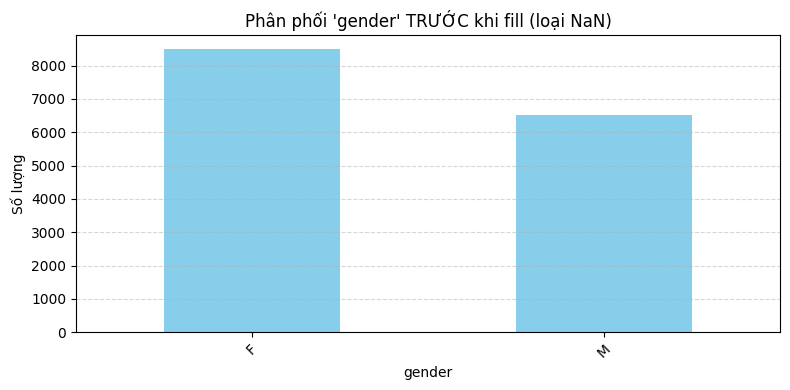

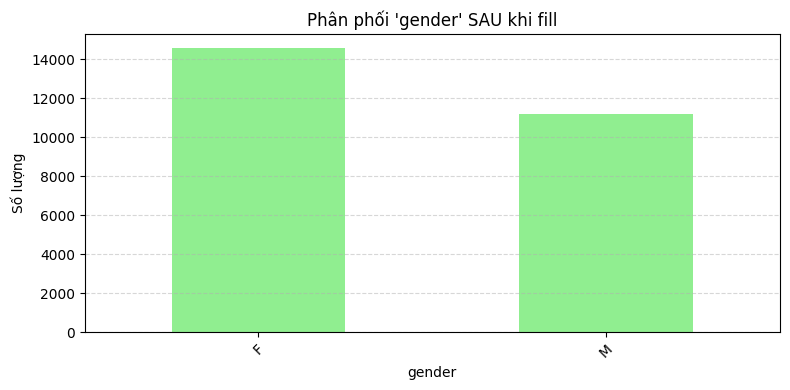

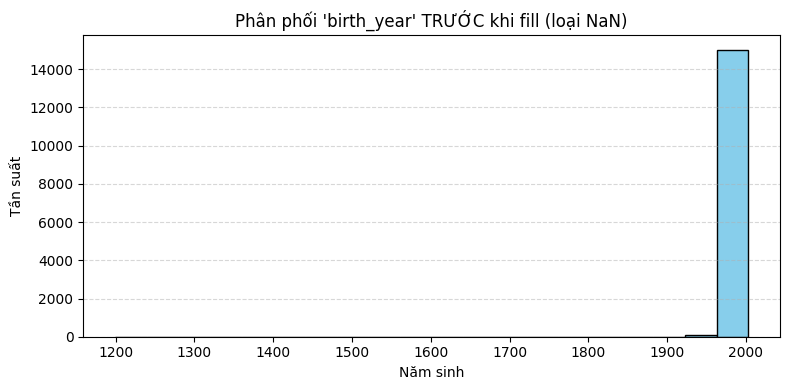

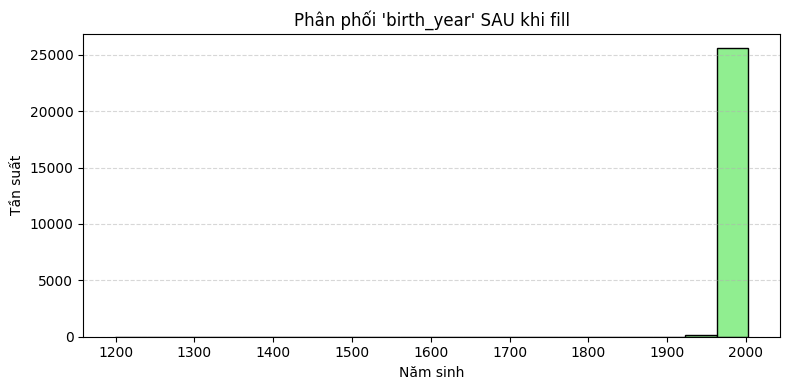

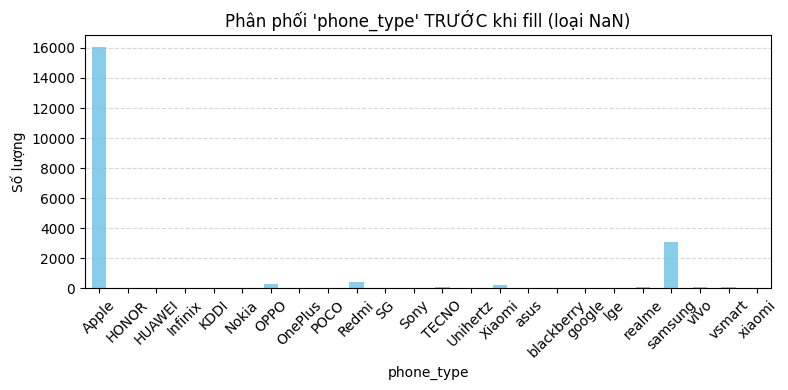

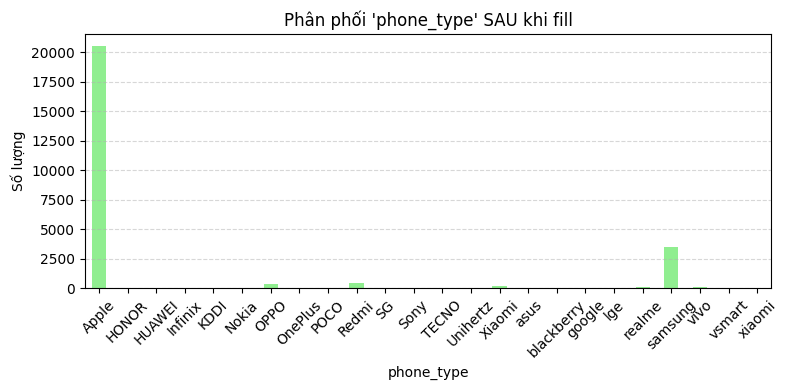

In [27]:
import matplotlib.pyplot as plt

cols_to_plot = ['gender', 'birth_year', 'phone_type']

for col in cols_to_plot:
    if col == 'birth_year':
        # 🟦 Histogram TRƯỚC khi fill (loại NaN)
        before_vals = df[col].dropna()
        plt.figure(figsize=(8, 4))
        plt.hist(before_vals, bins=20, color='skyblue', edgecolor='black')
        plt.title("Phân phối 'birth_year' TRƯỚC khi fill (loại NaN)")
        plt.xlabel("Năm sinh")
        plt.ylabel("Tần suất")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # 🟩 Histogram SAU khi fill
        after_vals = df_context[col].dropna()
        plt.figure(figsize=(8, 4))
        plt.hist(after_vals, bins=20, color='lightgreen', edgecolor='black')
        plt.title("Phân phối 'birth_year' SAU khi fill")
        plt.xlabel("Năm sinh")
        plt.ylabel("Tần suất")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    else:
        # Biểu đồ cột cho gender và phone_type
        before_dist = df[col].dropna().value_counts().sort_index()
        plt.figure(figsize=(8, 4))
        before_dist.plot(kind='bar', color='skyblue')
        plt.title(f"Phân phối '{col}' TRƯỚC khi fill (loại NaN)")
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        after_dist = df_context[col].value_counts(dropna=False).sort_index()
        plt.figure(figsize=(8, 4))
        after_dist.plot(kind='bar', color='lightgreen')
        plt.title(f"Phân phối '{col}' SAU khi fill")
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()


In [28]:
df_context.isna().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,5081
os_version,5081
rejected_reason,22679
stop_point,0


In [29]:
# prompt: Xoá cột age ở df_context

df_context = df_context.drop(columns=['age'])

## **4. FIll null những cột mới**

In [30]:
import pandas as pd

# Giả sử bạn đã có DataFrame df từ trước, ví dụ:
# df = pd.read_csv("ten_file.csv")

# Đếm số lượng null trước khi điền
null_before = df_context['device_system_name'].isnull().sum()
print("Số giá trị null cột device_system_name trước khi fill:", null_before)


# Điền giá trị null cho device_system_name theo phone_type
df_context['device_system_name'] = df_context.apply(
    lambda row: 'iOS' if pd.isnull(row['device_system_name']) and row['phone_type'] == 'Apple'
    else ('Android' if pd.isnull(row['device_system_name']) else row['device_system_name']),
    axis=1
)

# Đếm số lượng null sau khi điền
null_after = df_context['device_system_name'].isnull().sum()
print("Số giá trị null sau khi fill:", null_after)


Số giá trị null cột device_system_name trước khi fill: 5081
Số giá trị null sau khi fill: 0


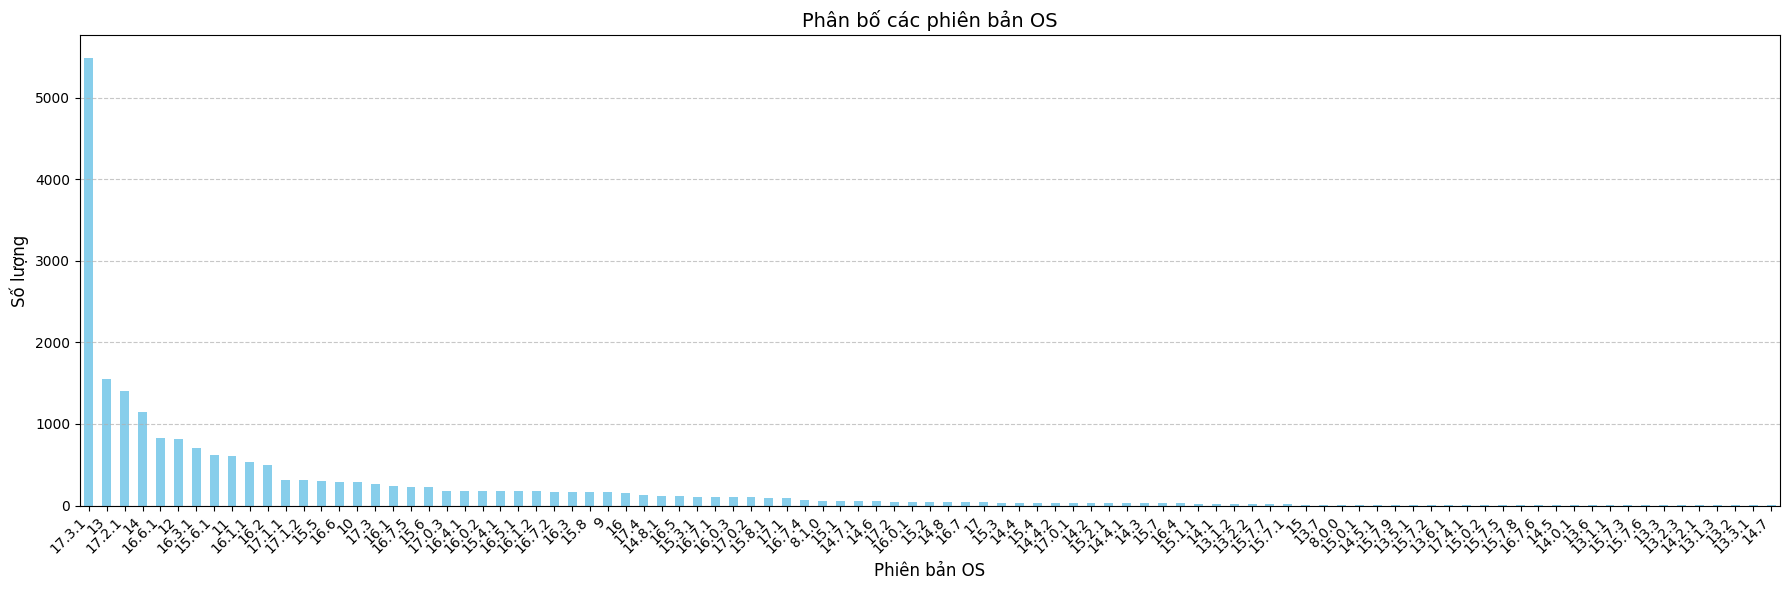

In [31]:
# prompt: hiện phân bổ os_version bằng bar chart

# Đếm số lượng mỗi phiên bản OS
os_version_counts = df['os_version'].value_counts()

# Tạo bar chart
plt.figure(figsize=(18, 6))
os_version_counts.plot(kind='bar', color='skyblue')
plt.title('Phân bố các phiên bản OS', fontsize=14)
plt.xlabel('Phiên bản OS', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục x cho dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Điều chỉnh layout để tránh cắt xén
plt.show()

In [32]:



# Tính mode theo từng nhóm
mode_table = (
    df_context.dropna(subset=['os_version'])  # Bỏ các dòng có os_version bị thiếu
    .groupby(['phone_type', 'device_system_name'])['os_version']
    .agg(lambda x: x.mode().tolist())  # Lấy danh sách mode (có thể nhiều hơn 1 giá trị)
    .reset_index()
    .rename(columns={'os_version': 'os_version_mode'})
)

# In kết quả
print(mode_table)

    phone_type device_system_name os_version_mode
0        Apple                iOS        [17.3.1]
1        Apple             iPadOS        [17.3.1]
2        HONOR            Android            [14]
3       HUAWEI            Android             [9]
4      Infinix            Android            [12]
5         KDDI            Android            [12]
6        Nokia            Android            [13]
7         OPPO            Android            [13]
8      OnePlus            Android            [14]
9         POCO            Android            [13]
10       Redmi            Android            [13]
11          SG            Android            [12]
12        Sony            Android            [14]
13       TECNO            Android            [13]
14    Unihertz            Android            [11]
15      Xiaomi            Android            [13]
16        asus            Android            [13]
17  blackberry            Android         [8.1.0]
18      google            Android            [14]


In [33]:
# Tính mode của os_version theo groupby phone_type và device_system_name
mode_per_group = (
    df_context.groupby(['phone_type', 'device_system_name'])['os_version']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'os_version': 'os_version_mode'})
)

# Gộp giá trị mode vào df_context
df_context = df_context.merge(mode_per_group, on=['phone_type', 'device_system_name'], how='left')

# Điền các giá trị null trong os_version bằng mode của nhóm
df_context['os_version'] = df_context['os_version'].fillna(df_context['os_version_mode'])

# Loại bỏ cột phụ sau khi đã fill xong
df_context.drop(columns=['os_version_mode'], inplace=True)


In [34]:
# prompt: df_context.isna.sum()

df_context.isna().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,0
os_version,0
rejected_reason,22679
stop_point,0


In [35]:
df.stop_point.value_counts()

,count
stop_point,
account-creation,8543
otp-failed,5612
ocr-failed,5404
data-privacy-rejected,2398
contract-rejected,1785
check-failed,1632
selfie-failed,372


In [36]:
# Tạo bảng đếm số lần xuất hiện rejected_reason theo từng stop_point
rejected_table = pd.crosstab(df_context['stop_point'], df_context['rejected_reason'])

# Hiển thị bảng
rejected_table


rejected_reason,aml-warning,contract-rejected,contract_rejected,document-check-declined,document-ocr-failed,face-deduplicated,face-matching-low,fatca,id-deduplicated,liveness-low,otp-check-failed,selfie-check-declined
stop_point,,,,,,,,,,,,
check-failed,13,0,0,83,0,0,0,15,6,0,0,0
contract-rejected,0,10,1,68,0,0,0,0,0,0,0,0
ocr-failed,0,0,0,0,2622,0,0,0,0,0,0,0
otp-failed,0,0,0,0,0,0,0,0,1,0,45,0
selfie-failed,0,0,0,0,0,2,28,0,0,97,0,76


In [37]:
df_context

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,01/03/2024 10:32,01/03/2024 10:32,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0
1,01/03/2024 19:38,01/03/2024 19:41,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,01/03/2024 10:25,01/03/2024 10:25,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,01/03/2024 16:16,01/03/2024 16:17,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,04/03/2024 13:30,04/03/2024 13:31,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
...,...,...,...,...,...,...,...,...,...,...,...
25741,29/02/2024 14:20,29/02/2024 14:23,succeed,F,1990.0,Apple,iOS,16.4.1,NaN,account-creation,9146
25742,01/03/2024 15:29,01/03/2024 15:30,fail,M,1984.0,Apple,iOS,17.3.1,document-ocr-failed,ocr-failed,9147
25743,01/03/2024 15:31,01/03/2024 15:31,pending,M,1984.0,Apple,iOS,17.3.1,NaN,otp-failed,9147
25744,01/03/2024 15:32,01/03/2024 15:36,succeed,M,1984.0,Apple,iOS,17.3.1,NaN,account-creation,9147


###Check lại sau khi fill null

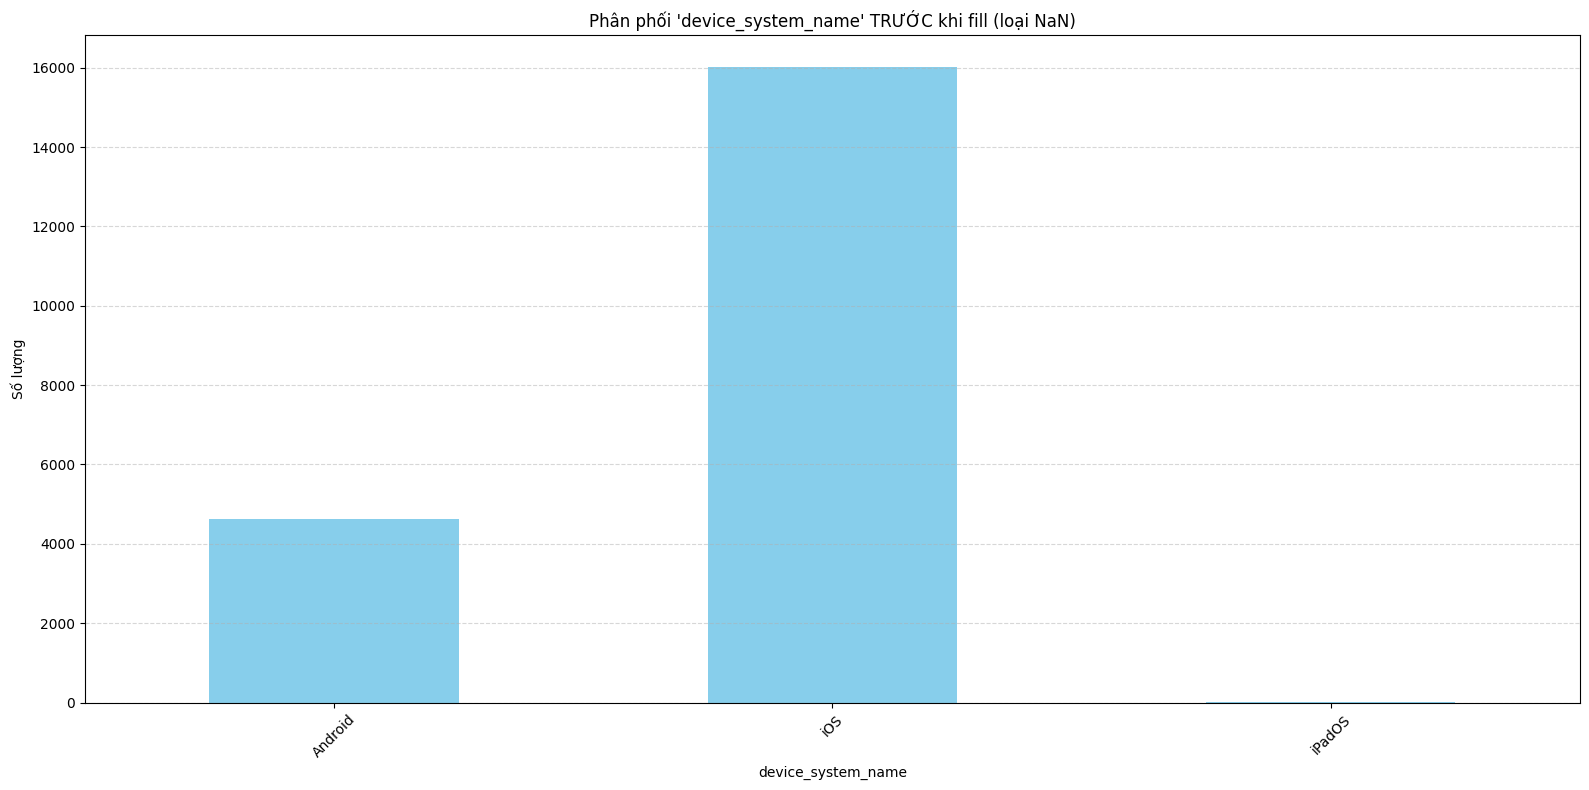

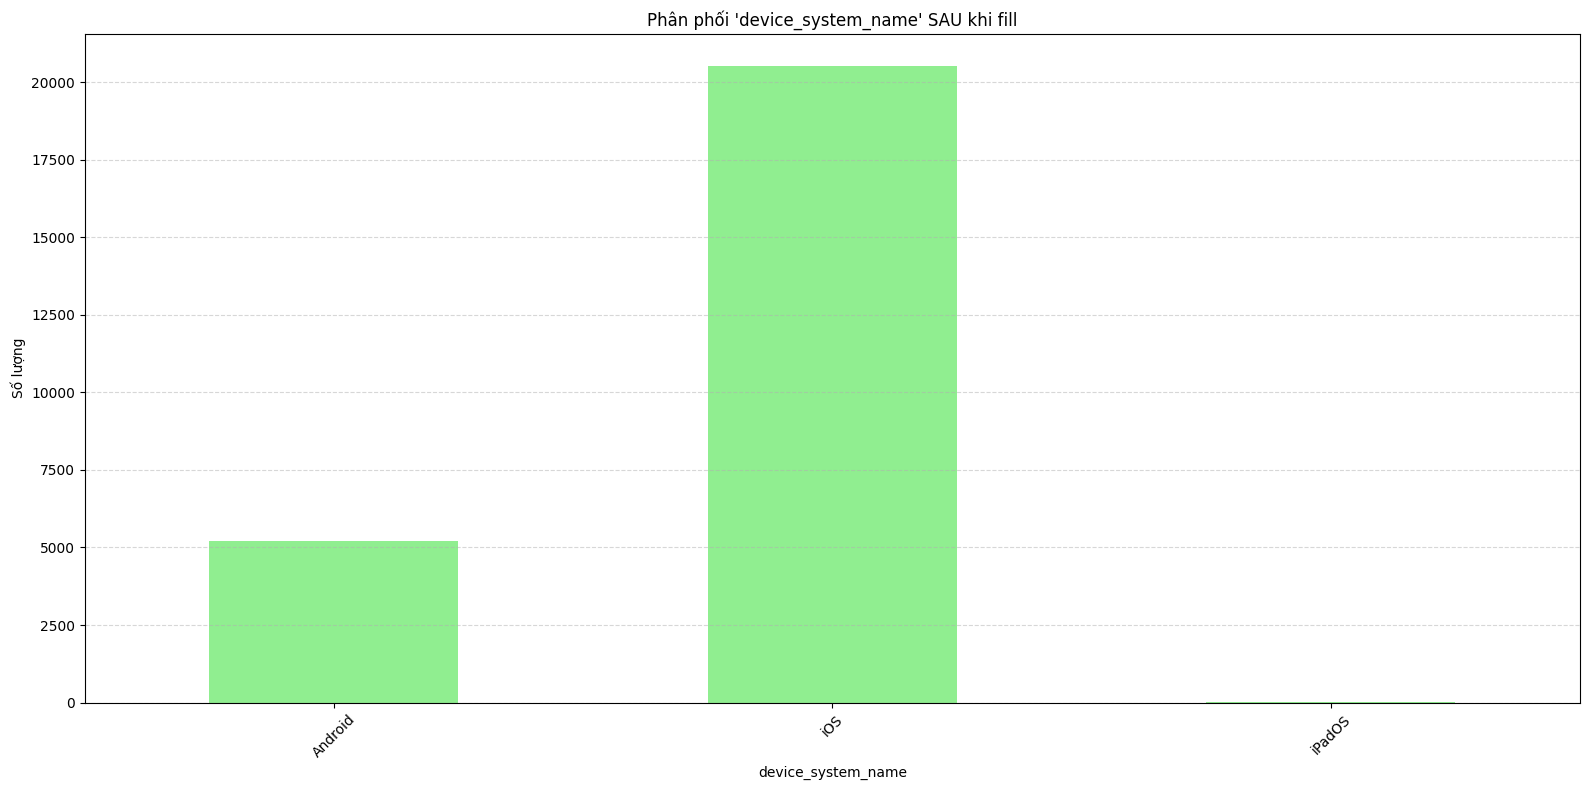

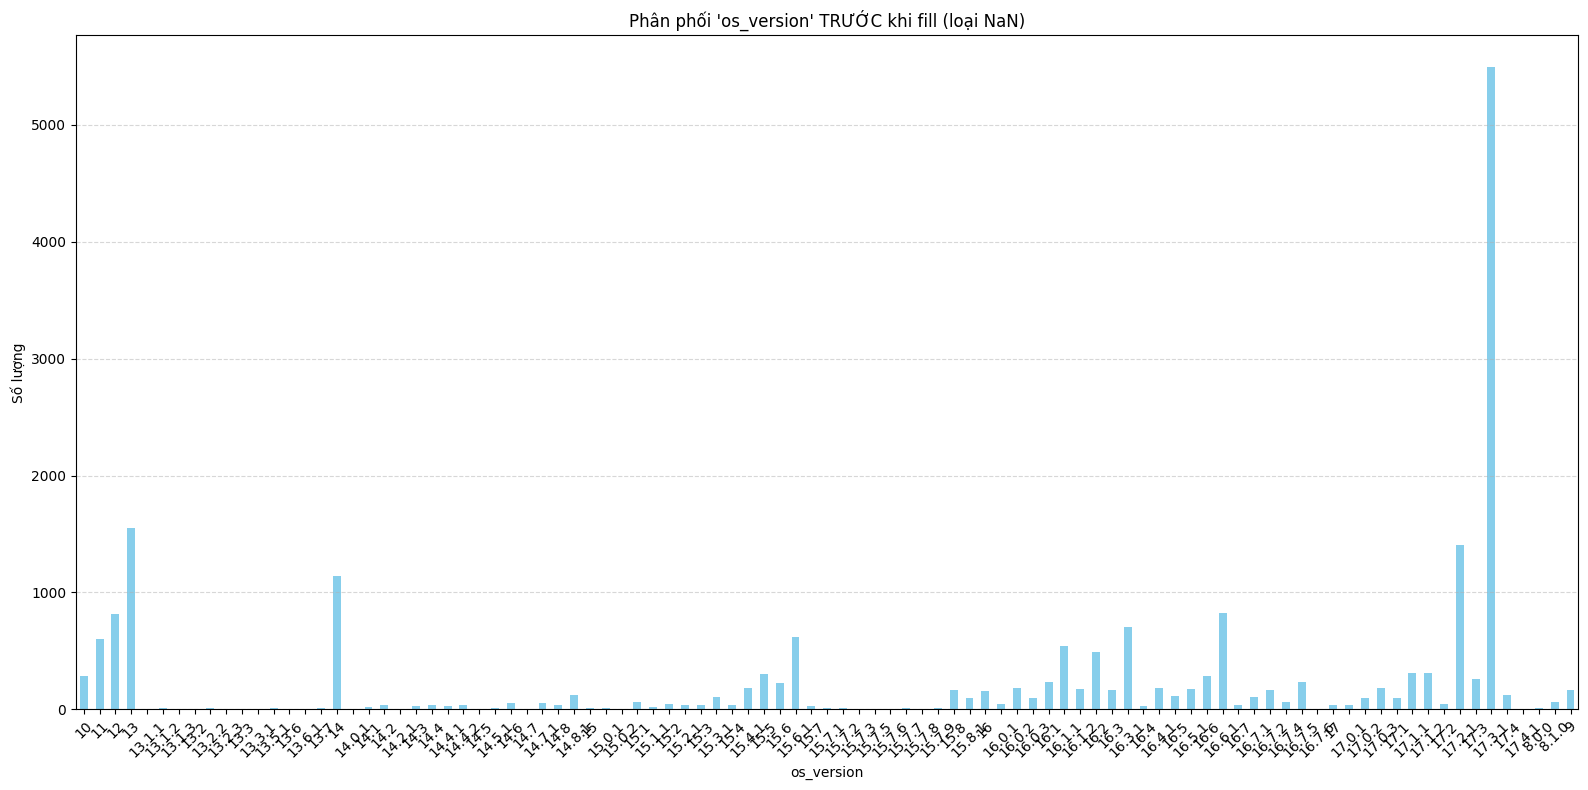

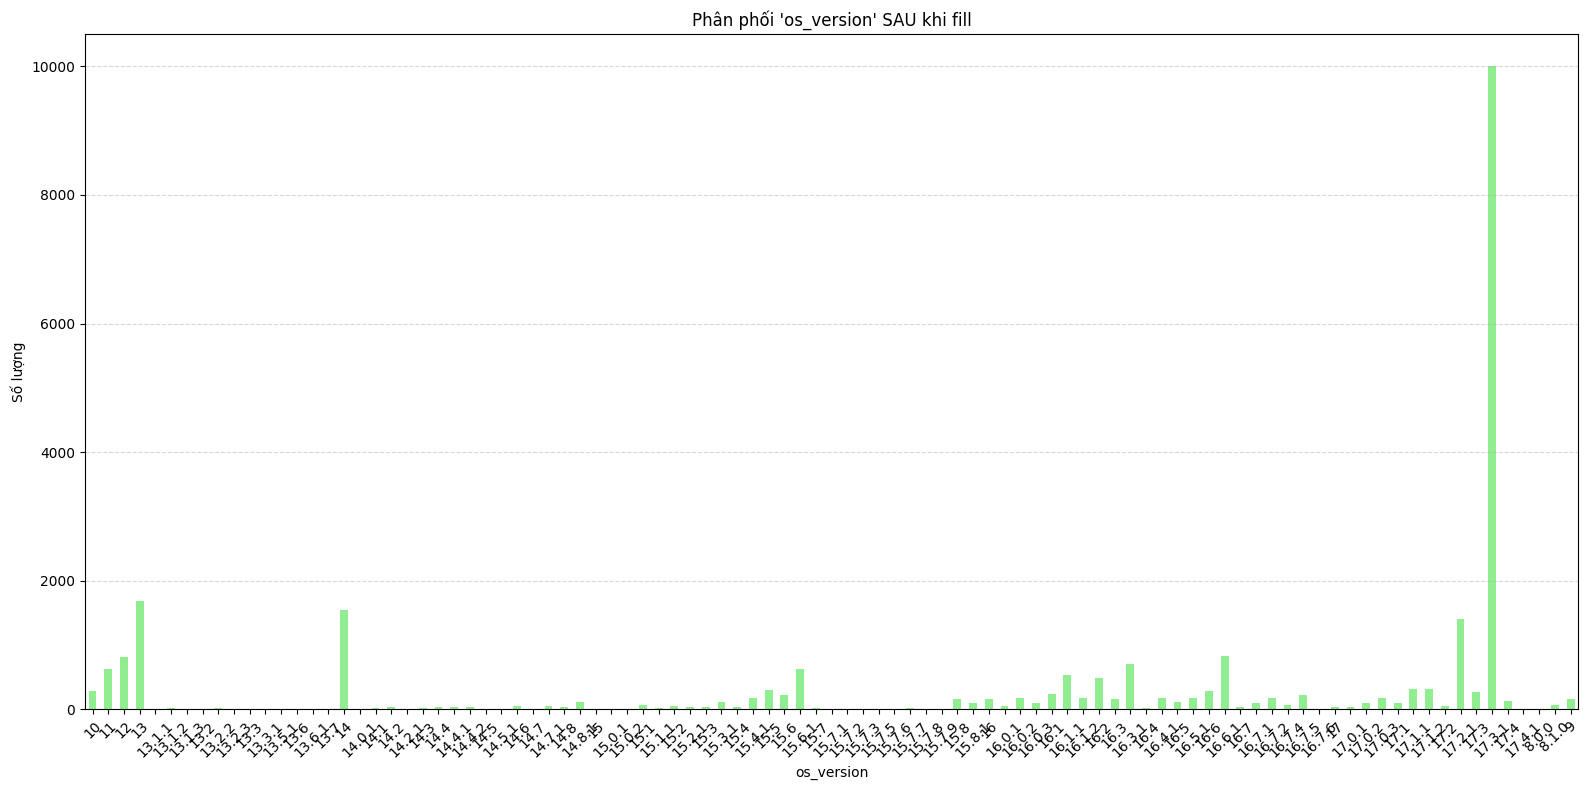

In [38]:
import matplotlib.pyplot as plt

cols_to_plot = ['device_system_name', 'os_version']

for col in cols_to_plot:
    # Biểu đồ cột trước khi fill
    before_dist = df[col].dropna().value_counts().sort_index()
    plt.figure(figsize=(16, 8))
    before_dist.plot(kind='bar', color='skyblue')
    plt.title(f"Phân phối '{col}' TRƯỚC khi fill (loại NaN)")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Biểu đồ cột sau khi fill
    after_dist = df_context[col].value_counts(dropna=False).sort_index()
    plt.figure(figsize=(16, 8))
    after_dist.plot(kind='bar', color='lightgreen')
    plt.title(f"Phân phối '{col}' SAU khi fill")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## **5. Định dạng lại các cột cần thiết**

In [39]:
df_cleaned = df_context.copy()
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'], errors='coerce', dayfirst=True)
df_cleaned['close_time'] = pd.to_datetime(df_cleaned['close_time'], errors='coerce', dayfirst=True)

df_cleaned.dtypes

,0
begin_time,datetime64[ns]
close_time,datetime64[ns]
status,object
gender,object
birth_year,float64
phone_type,object
device_system_name,object
os_version,object
rejected_reason,object
stop_point,object


In [40]:
df_context.head(25)

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,01/03/2024 10:32,01/03/2024 10:32,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0
1,01/03/2024 19:38,01/03/2024 19:41,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,01/03/2024 10:25,01/03/2024 10:25,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,01/03/2024 16:16,01/03/2024 16:17,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,04/03/2024 13:30,04/03/2024 13:31,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
5,04/03/2024 13:31,04/03/2024 13:31,pending,F,1998.0,Apple,iOS,15.6,NaN,data-privacy-rejected,1
6,12/03/2024 14:10,12/03/2024 14:10,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
7,12/03/2024 17:01,12/03/2024 17:01,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
8,13/03/2024 11:33,13/03/2024 11:34,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
9,29/02/2024 15:06,29/02/2024 15:06,pending,F,1998.0,Apple,iOS,15.6,NaN,otp-failed,1


In [41]:
df_cleaned.head(25)

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
5,2024-03-04 13:31:00,2024-03-04 13:31:00,pending,F,1998.0,Apple,iOS,15.6,NaN,data-privacy-rejected,1
6,2024-03-12 14:10:00,2024-03-12 14:10:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
7,2024-03-12 17:01:00,2024-03-12 17:01:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
8,2024-03-13 11:33:00,2024-03-13 11:34:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
9,2024-02-29 15:06:00,2024-02-29 15:06:00,pending,F,1998.0,Apple,iOS,15.6,NaN,otp-failed,1


In [42]:
# prompt: df_context.isna.sum

df_cleaned.isna().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,0
os_version,0
rejected_reason,22679
stop_point,0


In [43]:
df.begin_time.value_counts()

,count
begin_time,
29/02/2024 13:48,172
29/02/2024 13:43,165
29/02/2024 13:44,161
29/02/2024 13:45,157
29/02/2024 13:47,155
...,...
31/01/2024 14:08,1
31/01/2024 15:13,1
31/01/2024 15:16,1


## **6. Tạo thêm các cột cần thiết**

In [44]:


# Tạo cột duration (đơn vị: phút)
df_cleaned['duration'] = (df_cleaned['close_time'] - df_cleaned['begin_time']).dt.total_seconds() / 60

# Tạo cột age
df_cleaned['age'] = 2024 - df_cleaned['birth_year']


In [45]:
import pandas as pd

# Chuyển cột begin_time sang kiểu datetime nếu chưa
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'])

# Tạo cột weekday (thứ trong tuần)
df_cleaned['weekday'] = df_cleaned['begin_time'].dt.day_name()

import pandas as pd
import matplotlib.pyplot as plt

# Chuyển đổi cột thời gian
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'])

# Phân loại theo buổi
def classify_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df_cleaned['time_period'] = df_cleaned['begin_time'].dt.hour.apply(classify_period)

def categorize_generation(age):
    if age >= 60:
        return 'Boomers'
    elif 44 <= age < 60:
        return 'Gen X'
    elif 28 <= age < 44:
        return 'Gen Y (Millennials)'
    elif age < 28:
        return 'Gen Z'
    else:
        return 'Unknown'

df_cleaned['generation'] = df_cleaned['age'].apply(categorize_generation)

## **7. Dữ liệu đã Cleaned, xuất ra xlsx**

In [46]:
df_cleaned.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials)
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials)
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z


In [47]:
# prompt: df_cleaned.isnull.value_counts()

df_cleaned.isnull().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,0
os_version,0
rejected_reason,22679
stop_point,0


In [48]:
# prompt: df_cleaned ra excel

df_cleaned.to_excel("data_cleaned.xlsx", index=False)

# **III. Explore Data Analysis (EDA)**

In [49]:
df_eda = df_cleaned.copy()

## **1. Tổng quan**

In [50]:
df_eda.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials)
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials)
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z


In [51]:
df_eda['begin_time'].describe()

,begin_time
count,25746
mean,2024-02-28 14:27:20.249359104
min,2024-01-02 11:17:00
25%,2024-02-29 11:44:15
50%,2024-03-01 10:11:00
75%,2024-03-05 11:48:00
max,2024-03-31 21:05:00


In [52]:
# Số khách hàng

unique_customers = df_eda['customer_id'].nunique()
print(f"Total unique customers: {unique_customers}")

# prompt: Đếm sô unique khách hàng có status = succeed

# Filter the DataFrame to include only rows where 'status' is 'succeed'
df_succeed = df_eda[df_eda['status'] == 'succeed']

# Count the number of unique customer_ids in the filtered DataFrame
unique_success_customers = df_succeed['customer_id'].nunique()

print(f"Số unique khách hàng có status = 'succeed': {unique_success_customers}")

Total unique customers: 9148
Số unique khách hàng có status = 'succeed': 8543


/tmp/ipykernel_17872/1669294453.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])
/tmp/ipykernel_17872/1669294453.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['month'] = df_customer['begin_time'].dt.month
/tmp/ipykernel_17872/1669294453.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_labels)


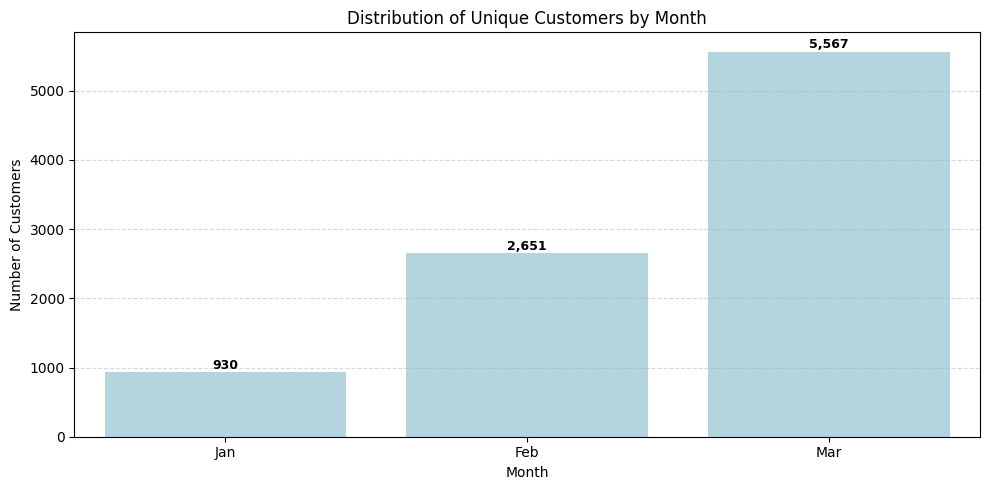

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_customer = df_eda.drop_duplicates(subset='customer_id')

# Đảm bảo begin_time là datetime
df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])

# Trích xuất tháng
df_customer['month'] = df_customer['begin_time'].dt.month

# Tạo mapping tên tháng (tuỳ chọn)
month_order = list(range(1, 4))
month_labels = ['Jan', 'Feb', 'Mar']

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_customer, x='month', order=month_order, color='lightblue')

# Thêm data label
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 10,
        s=f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Trang trí
ax.set_xticklabels(month_labels)
plt.title('Distribution of Unique Customers by Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [54]:
unique_success_customers = df_succeed['customer_id'].nunique()

print(f"Số unique khách hàng có status = 'succeed': {unique_success_customers}")

Số unique khách hàng có status = 'succeed': 8543


In [55]:
# Tỷ lệ tổng thể
total_all = df_eda['customer_id'].nunique()
total_succeed = df_succeed['customer_id'].nunique()

overall_rate = total_succeed / total_all * 100
print(f'Tổng thể: {overall_rate:.2f}%')


Tổng thể: 93.39%


In [56]:
# Tính duration trung bình theo status
avg_duration_by_status = df_eda.groupby('status')['duration'].mean().reset_index()

# Hiển thị kết quả
print(avg_duration_by_status)

    status    duration
0     fail  197.131543
1  pending    6.642408
2  succeed  554.740489


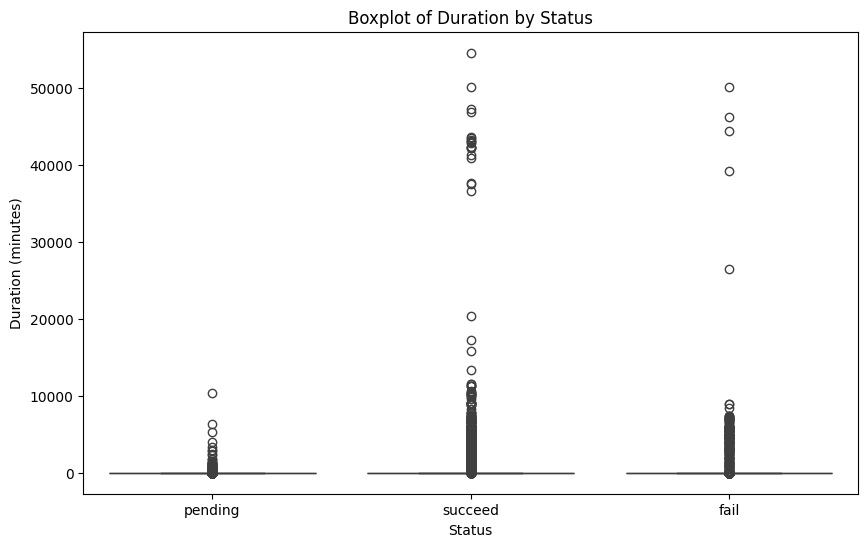

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ boxplot
sns.boxplot(x='status', y='duration', data=df_eda)

# Tiêu đề và nhãn
plt.title('Boxplot of Duration by Status')
plt.xlabel('Status')
plt.ylabel('Duration (minutes)')

# Hiển thị biểu đồ
plt.show()


In [58]:
import pandas as pd
import numpy as np

# Hàm thay outlier bằng median theo từng nhóm status
def replace_outliers_by_median(df, col='duration', group_col='status'):
    def process_group(group):
        mean = group[col].mean()
        std = group[col].std()
        lower = mean - 1.96 * std
        upper = mean + 1.96 * std
        median = group[col].median()
        # Thay các giá trị ngoài khoảng CI bằng median
        group[col] = group[col].apply(lambda x: x if lower <= x <= upper else median)
        return group

    return df.groupby(group_col, group_keys=False).apply(process_group)

# Áp dụng lên df_eda
df_eda = replace_outliers_by_median(df_eda, col='duration', group_col='status')


/tmp/ipykernel_17872/1603097457.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col, group_keys=False).apply(process_group)


In [59]:
# Tính duration trung bình theo status
avg_duration_by_status = df_eda.groupby('status')['duration'].mean().reset_index()

# Hiển thị kết quả
print(avg_duration_by_status)

    status    duration
0     fail   17.300743
1  pending    0.817658
2  succeed  303.050334


**Kết luận**: Dữ liệu trong 3 tháng đầu năm 2024 cho thấy tỷ lệ mở tài khoản thành công đạt mức cao 93%, tuy nhiên quá trình thu thập dữ liệu thời gian (begin – close time) có dấu hiệu sai lệch nghiêm trọng và cần được rà soát lại để đảm bảo độ tin cậy cho phân tích.

Cụ thể, thời gian ghi nhận cho một số bước trong quy trình mở tài khoản lên tới hàng nghìn phút, thậm chí có trường hợp kéo dài gần 5 tuần – vượt xa ngưỡng hợp lý từ 5–10 phút thường thấy trong thực tế. Điều này cho thấy khả năng cao hệ thống ghi nhận thời gian đang gặp lỗi hoặc có quy trình vận hành chưa được kiểm soát chặt. Mặc dù đã sử dụng 95% CI để loại bỏ outlier nhưng dữ liệu thời gian của việc tạo tài khoản vẫn chưa thực sự phù hợp với thực tế để phân tích.

In [60]:
# Tính tổng số hàng
total_rows = len(df_eda)

# Tính số hàng có status là pending hoặc fail
num_pending_fail = df_eda[df_eda['status'].isin(['pending', 'fail'])].shape[0]

# Tính tỉ lệ
ratio = num_pending_fail / total_rows

# In ra kết quả dưới dạng %
print(f"Tỉ lệ (pending + fail) trên tổng số hàng: {ratio:.2%}")


Tỉ lệ (pending + fail) trên tổng số hàng: 66.82%


/tmp/ipykernel_17872/2681651518.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_stats = df_eda.groupby('month').apply(


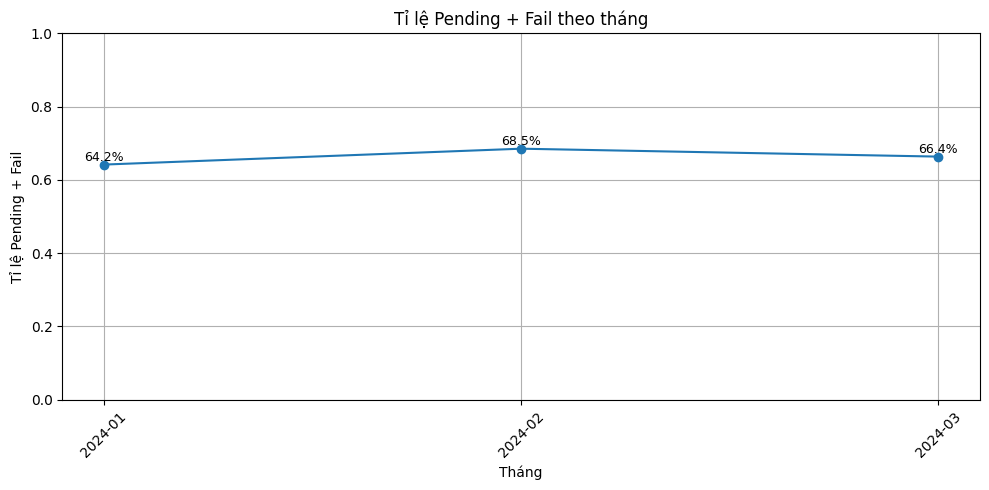

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Đảm bảo cột thời gian đúng định dạng
df_eda['begin_time'] = pd.to_datetime(df_eda['begin_time'])
df_eda['month'] = df_eda['begin_time'].dt.to_period('M')

# Tính tỉ lệ pending + fail theo từng tháng
monthly_stats = df_eda.groupby('month').apply(
    lambda g: g[g['status'].isin(['pending', 'fail'])].shape[0] / g.shape[0]
).reset_index(name='fail_pending_ratio')

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
x = monthly_stats['month'].astype(str)
y = monthly_stats['fail_pending_ratio']
plt.plot(x, y, marker='o')
plt.xticks(rotation=45)
plt.ylabel('Tỉ lệ Pending + Fail')
plt.xlabel('Tháng')
plt.title('Tỉ lệ Pending + Fail theo tháng')
plt.ylim(0, 1)
plt.grid(True)

# Thêm data label cho từng điểm
for i in range(len(x)):
    plt.text(x[i], y[i] + 0.01, f'{y[i]*100:.1f}%', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


##**2. Phân tích khách hàng**

In [62]:
# Đếm số dòng có age > 100
count_age = df_eda[df_eda['age'] > 100].shape[0]
print(f"Số dòng có age > 100: {count_age}")


Số dòng có age > 100: 2


In [63]:
# --- 1. Thay age > 100 bằng trung bình các age hợp lệ ---
valid_age_mean = df_eda.loc[df_eda['age'] <= 100, 'age'].mean()
df_eda.loc[df_eda['age'] > 100, 'age'] = round(valid_age_mean)
count_age = df_eda[df_eda['age'] > 100].shape[0]
print(f"Số dòng có age > 100: {count_age}")


Số dòng có age > 100: 0


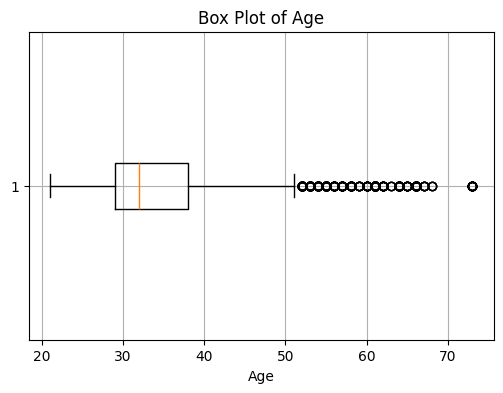

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử bạn đã đọc dữ liệu vào DataFrame tên là df_eda
# df_eda = pd.read_csv("your_file.csv")  # nếu bạn cần đọc từ file

# Vẽ box plot cho cột age
plt.figure(figsize=(6, 4))
plt.boxplot(df_eda['age'].dropna(), vert=False)
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.grid(True)
plt.show()


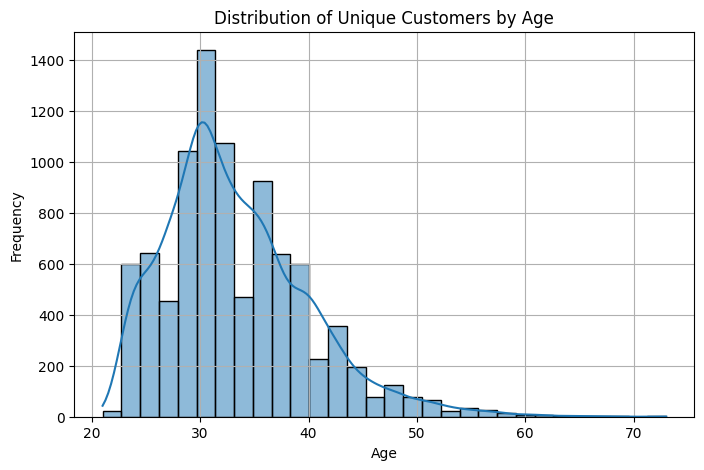

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc chỉ giữ lại mỗi customer_id một lần
df_customer = df_eda.drop_duplicates(subset='customer_id')

# Vẽ biểu đồ phân phối cho cột age đã lọc trùng
plt.figure(figsize=(8, 5))
sns.histplot(df_customer['age'], kde=True, bins=30)
plt.title('Distribution of Unique Customers by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [66]:
df_eda.age.describe()

,age
count,25746.000000
mean,33.761866
std,7.230981
min,21.000000
25%,29.000000
50%,32.000000
75%,38.000000
max,73.000000


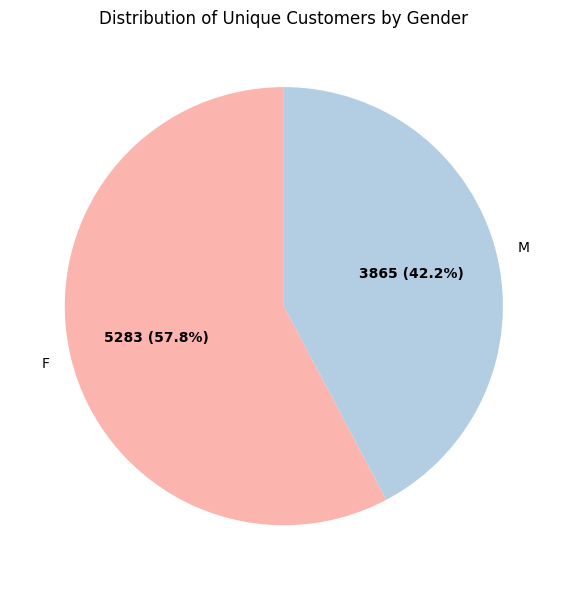

In [67]:
import matplotlib.pyplot as plt

# Tính số lượng và phần trăm theo giới tính
gender_counts = df_customer['gender'].value_counts()
gender_percent = gender_counts / gender_counts.sum() * 100

# Vẽ biểu đồ tròn với nhãn bên trong
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct=lambda pct: f'{int(round(pct/100 * gender_counts.sum()))} ({pct:.1f}%)',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    textprops=dict(color='black', fontsize=10)
)

# Căn giữa và thêm tiêu đề
plt.setp(autotexts, size=10, weight='bold')
plt.title('Distribution of Unique Customers by Gender')
plt.tight_layout()
plt.show()


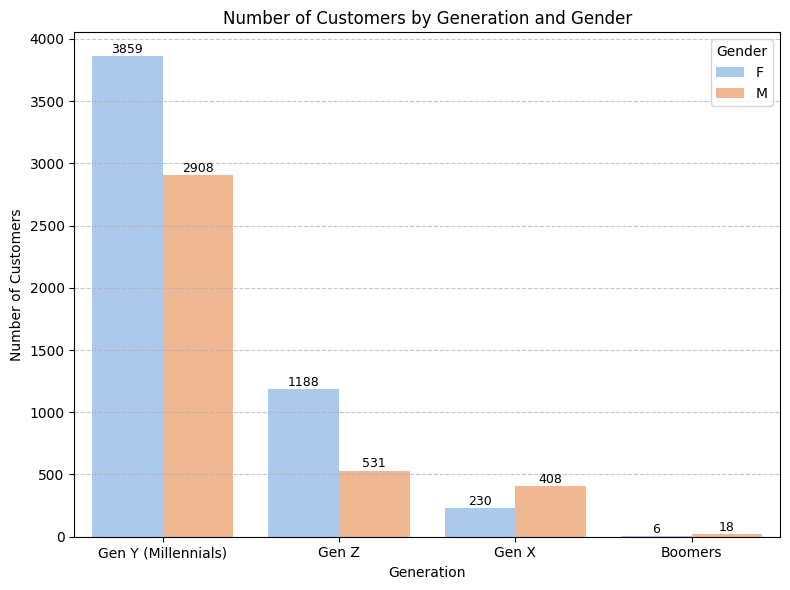

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ cột có phân loại theo giới tính (gender)
ax = sns.countplot(data=df_customer, x='generation', hue='gender', palette='pastel')

# Thêm data label trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 1,
            s=f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Thiết lập tiêu đề và nhãn
plt.title('Number of Customers by Generation and Gender')
plt.xlabel('Generation')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


/tmp/ipykernel_17872/3348484623.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['phone_type_grouped'] = df_customer['phone_type'].apply(lambda x: x if x in phone_map else 'Others')
/tmp/ipykernel_17872/3348484623.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_customer, x='phone_type_grouped', order=sorted_order, palette='Set3')


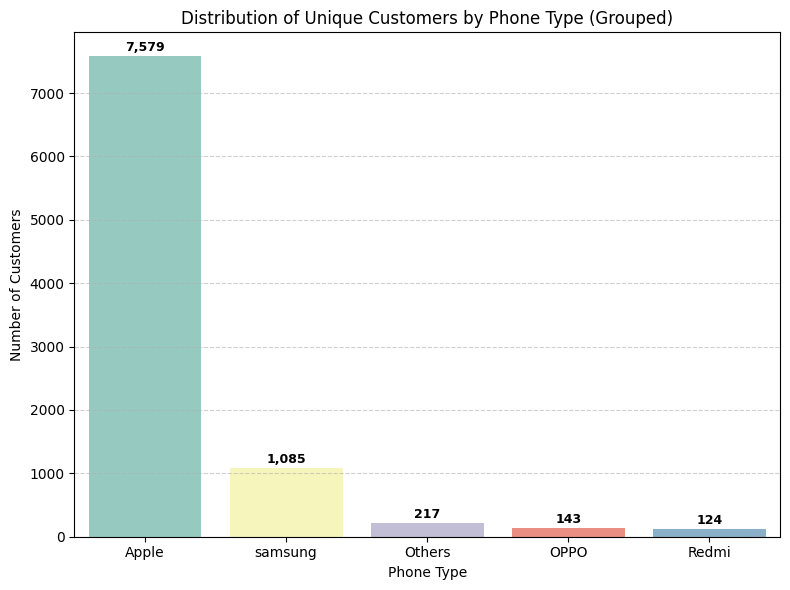

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Bước 1: Tính tỷ lệ từng loại phone_type
phone_counts = df_customer['phone_type'].value_counts(normalize=True)

# Bước 2: Gộp các loại < 1% thành 'Others'
phone_map = phone_counts[phone_counts >= 0.01].index.tolist()
df_customer['phone_type_grouped'] = df_customer['phone_type'].apply(lambda x: x if x in phone_map else 'Others')

# Bước 3: Sắp xếp theo số lượng giảm dần
sorted_order = df_customer['phone_type_grouped'].value_counts().index

# Bước 4: Vẽ biểu đồ với data label
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_customer, x='phone_type_grouped', order=sorted_order, palette='Set3')

# Thêm nhãn số lên trên từng cột
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 30,
        s=f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Trang trí
plt.title('Distribution of Unique Customers by Phone Type (Grouped)')
plt.xlabel('Phone Type')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [70]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25746 entries, 0 to 25745
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   begin_time          25746 non-null  datetime64[ns]
 1   close_time          25746 non-null  datetime64[ns]
 2   status              25746 non-null  object        
 3   gender              25746 non-null  object        
 4   birth_year          25746 non-null  float64       
 5   phone_type          25746 non-null  object        
 6   device_system_name  25746 non-null  object        
 7   os_version          25746 non-null  object        
 8   rejected_reason     3067 non-null   object        
 9   stop_point          25746 non-null  object        
 10  customer_id         25746 non-null  int64         
 11  duration            25746 non-null  float64       
 12  age                 25746 non-null  float64       
 13  weekday             25746 non-null  object        


device_system_name
iOS        20529
Android     5195
iPadOS        22
Name: count, dtype: int64


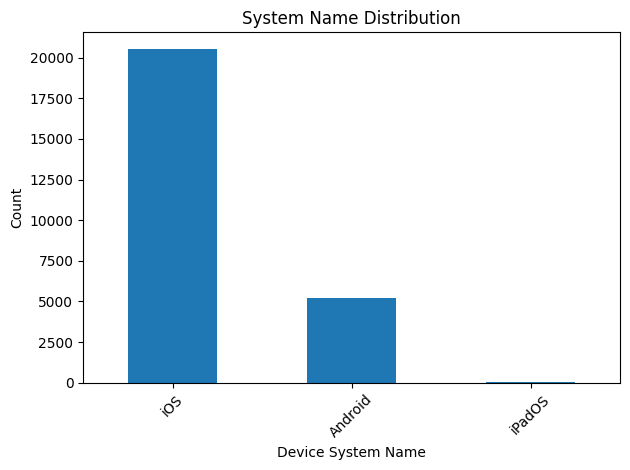

In [71]:
# Phân phối tần suất của device_system_name
distribution = df_eda['device_system_name'].value_counts(dropna=False)

# Hiển thị kết quả
print(distribution)
import matplotlib.pyplot as plt

# Vẽ biểu đồ bar
distribution.head(10).plot(kind='bar')  # chỉ hiển thị 10 hệ điều hành phổ biến nhất
plt.title('System Name Distribution')
plt.xlabel('Device System Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


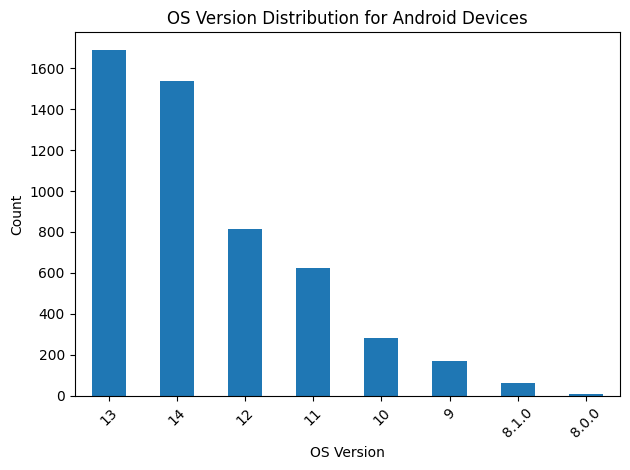

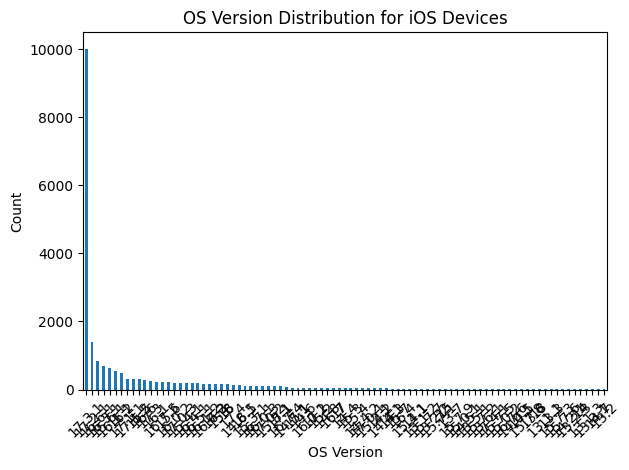

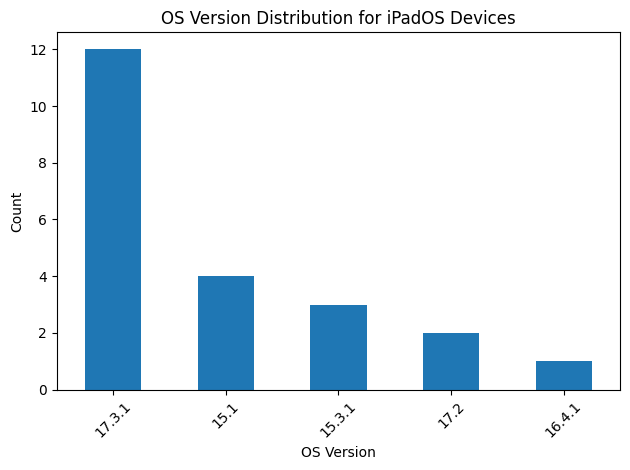

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Phân bổ os_version theo device_system_name (dạng bảng số lượng) ----
distribution_count = df_eda.groupby('device_system_name')['os_version'].value_counts().unstack(fill_value=0)

# ---- Phân bổ os_version theo device_system_name (dạng tỷ lệ %) ----
distribution_percent = df_eda.groupby('device_system_name')['os_version'].value_counts(normalize=True).unstack(fill_value=0) * 100


# --- Trực quan hóa cho từng hệ điều hành ---
target_devices = ['Android', 'iOS', 'iPadOS']

for device in target_devices:
    if device in df_eda['device_system_name'].unique():
        os_dist = df_eda[df_eda['device_system_name'] == device]['os_version'].value_counts()

        plt.figure()
        os_dist.plot(kind='bar')
        plt.title(f'OS Version Distribution for {device} Devices')
        plt.xlabel('OS Version')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{device} not found in device_system_name.")

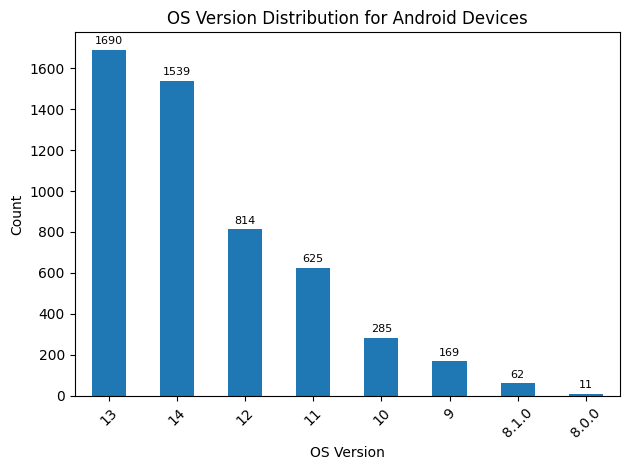

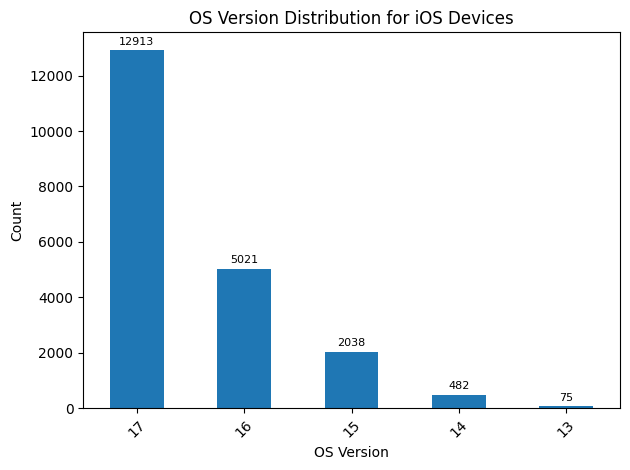

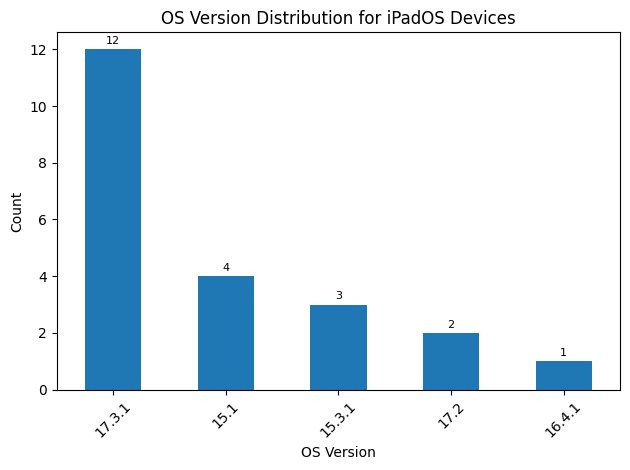

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Tạo bản sao để xử lý ---
df_temp = df_eda.copy()

# --- Gom nhóm iOS theo major version ---
df_temp.loc[df_temp['device_system_name'] == 'iOS', 'os_version'] = (
    df_temp.loc[df_temp['device_system_name'] == 'iOS', 'os_version']
    .astype(str)
    .str.extract(r'^(\d+)', expand=False)  # Lấy phần số trước dấu chấm
)

# --- Phân bổ số lượng ---
distribution_count = df_temp.groupby('device_system_name')['os_version'].value_counts().unstack(fill_value=0)

# --- Phân bổ tỷ lệ phần trăm ---
distribution_percent = df_temp.groupby('device_system_name')['os_version'].value_counts(normalize=True).unstack(fill_value=0) * 100

# --- Trực quan hóa với data label ---
target_devices = ['Android', 'iOS', 'iPadOS']

for device in target_devices:
    if device in df_temp['device_system_name'].unique():
        os_dist = df_temp[df_temp['device_system_name'] == device]['os_version'].value_counts()

        plt.figure()
        ax = os_dist.plot(kind='bar')
        plt.title(f'OS Version Distribution for {device} Devices')
        plt.xlabel('OS Version')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Thêm nhãn dữ liệu (data labels) trên mỗi cột
        for i, val in enumerate(os_dist.values):
            ax.text(i, val + max(os_dist.values)*0.01, str(val), ha='center', va='bottom', fontsize=8)

        plt.show()
    else:
        print(f"{device} not found in device_system_name.")


In [74]:
import pandas as pd

# Đảm bảo cột thời gian là datetime
df_eda['begin_time'] = pd.to_datetime(df_eda['begin_time'])

# Trích xuất ngày (yyyy-mm-dd)
df_eda['date'] = df_eda['begin_time'].dt.date

# Nhóm theo ngày và đếm số lượng unique khách hàng
top_days = df_eda.groupby('date')['customer_id'].nunique().sort_values(ascending=False).head(5)

# Hiển thị kết quả
print("Top 5 ngày có số lượng mở tài khoản cao nhất:")
print(top_days)


Top 5 ngày có số lượng mở tài khoản cao nhất:
date
2024-03-01    3018
2024-02-29    2408
2024-03-14     658
2024-03-04     646
2024-02-28     617
Name: customer_id, dtype: int64


In [75]:
# Lọc những dòng thỏa mãn điều kiện
filtered_df = df_eda[
    (df_eda['gender'] == 'F') &
    (df_eda['age'].between(25, 35)) &
    (df_eda['phone_type'] == 'Apple')
]

# Lấy tập hợp duy nhất customer_id thuộc nhóm mục tiêu
target_customers = filtered_df['customer_id'].dropna().unique()

# Lấy toàn bộ customer_id duy nhất trong toàn bộ dữ liệu
all_customers = df_eda['customer_id'].dropna().unique()

# Tính phần trăm
percentage = (len(target_customers) / len(all_customers)) * 100

print(f"Tỷ lệ khách hàng nữ, 25–35 tuổi, dùng Apple (duy nhất theo ID): {percentage:.2f}%")


Tỷ lệ khách hàng nữ, 25–35 tuổi, dùng Apple (duy nhất theo ID): 32.82%


In [76]:
# Lọc những dòng thỏa mãn điều kiện
filtered_df = df_eda[
    (df_eda['gender'] == 'F') &
    (df_eda['generation'] == 'Gen Y (Millennials)') &
    (df_eda['phone_type'] == 'Apple')
]

# Lấy tập hợp duy nhất customer_id thuộc nhóm mục tiêu
target_customers = filtered_df['customer_id'].dropna().unique()

# Lấy toàn bộ customer_id duy nhất trong toàn bộ dữ liệu
all_customers = df_eda['customer_id'].dropna().unique()

# Tính phần trăm
percentage = (len(target_customers) / len(all_customers)) * 100

print(f"Tỷ lệ khách hàng nữ, 25–35 tuổi, dùng Apple (duy nhất theo ID): {percentage:.2f}%")


Tỷ lệ khách hàng nữ, 25–35 tuổi, dùng Apple (duy nhất theo ID): 36.08%


In [77]:
df_eda

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation,month,date
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials),2024-03,2024-03-01
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials),2024-03,2024-03-01
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z,2024-03,2024-03-01
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z,2024-03,2024-03-01
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z,2024-03,2024-03-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25741,2024-02-29 14:20:00,2024-02-29 14:23:00,succeed,F,1990.0,Apple,iOS,16.4.1,NaN,account-creation,9146,3.0,34.0,Thursday,Afternoon,Gen Y (Millennials),2024-02,2024-02-29
25742,2024-03-01 15:29:00,2024-03-01 15:30:00,fail,M,1984.0,Apple,iOS,17.3.1,document-ocr-failed,ocr-failed,9147,1.0,40.0,Friday,Afternoon,Gen Y (Millennials),2024-03,2024-03-01
25743,2024-03-01 15:31:00,2024-03-01 15:31:00,pending,M,1984.0,Apple,iOS,17.3.1,NaN,otp-failed,9147,0.0,40.0,Friday,Afternoon,Gen Y (Millennials),2024-03,2024-03-01
25744,2024-03-01 15:32:00,2024-03-01 15:36:00,succeed,M,1984.0,Apple,iOS,17.3.1,NaN,account-creation,9147,4.0,40.0,Friday,Afternoon,Gen Y (Millennials),2024-03,2024-03-01


/tmp/ipykernel_17872/1063259447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])
/tmp/ipykernel_17872/1063259447.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['day_of_month'] = df_customer['begin_time'].dt.day


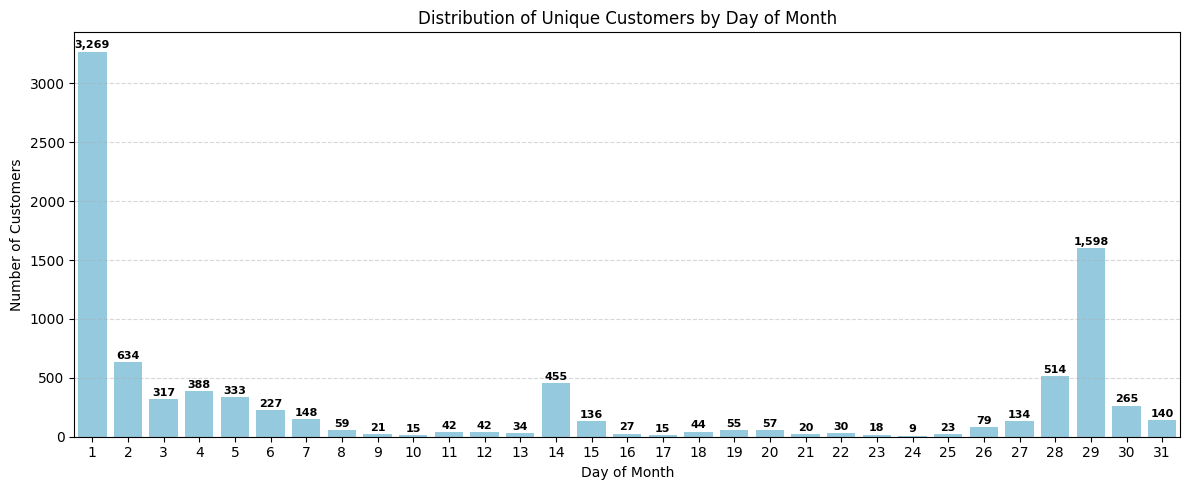

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Đảm bảo cột thời gian đúng định dạng
df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])

# Trích xuất ngày trong tháng
df_customer['day_of_month'] = df_customer['begin_time'].dt.day

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df_customer, x='day_of_month', color='skyblue')

# Thêm data labels
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 10,
        s=f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

# Trang trí
plt.title('Distribution of Unique Customers by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


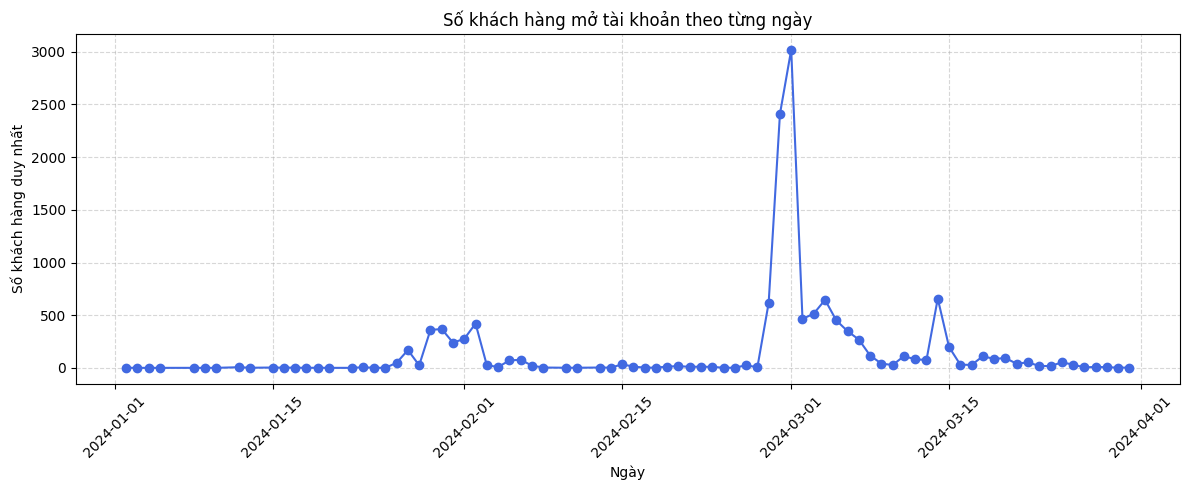

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Đảm bảo begin_time là datetime
df_eda['begin_time'] = pd.to_datetime(df_eda['begin_time'])

# Tạo cột ngày (yyyy-mm-dd)
df_eda['date'] = df_eda['begin_time'].dt.date

# Đếm số khách hàng duy nhất theo ngày
customers_by_date = df_eda.groupby('date')['customer_id'].nunique().reset_index()
customers_by_date.columns = ['Date', 'Unique_Customers']

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 5))
plt.plot(customers_by_date['Date'], customers_by_date['Unique_Customers'], marker='o', linestyle='-', color='royalblue')

# Trang trí biểu đồ
plt.title('Số khách hàng mở tài khoản theo từng ngày')
plt.xlabel('Ngày')
plt.ylabel('Số khách hàng duy nhất')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_17872/2221988644.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])
/tmp/ipykernel_17872/2221988644.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['period'] = df_customer['begin_time'].dt.hour.apply(classify_period)


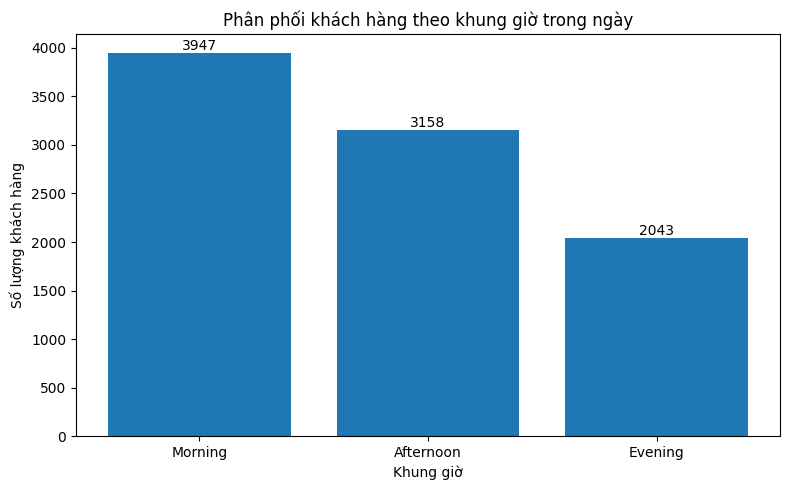

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Chuyển đổi cột thời gian
df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])

# Phân loại theo buổi
def classify_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df_customer['period'] = df_customer['begin_time'].dt.hour.apply(classify_period)

# Thống kê
period_counts = df_customer['period'].value_counts().reindex(['Morning', 'Afternoon', 'Evening'])

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
bars = plt.bar(period_counts.index, period_counts.values)

# Thêm data label
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{int(height)}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.title('Phân phối khách hàng theo khung giờ trong ngày')
plt.xlabel('Khung giờ')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [81]:
df_eda.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation,month,date
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials),2024-03,2024-03-01
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials),2024-03,2024-03-01
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z,2024-03,2024-03-01
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z,2024-03,2024-03-01
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z,2024-03,2024-03-04


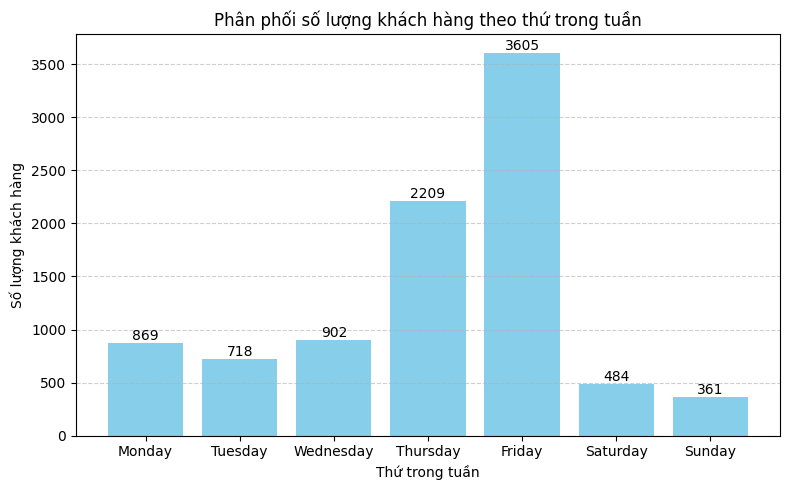

In [82]:
import matplotlib.pyplot as plt

# Nhóm theo weekday và đếm số lượng customer_id duy nhất
weekday_dist = df_customer.groupby('weekday')['customer_id'].nunique().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index(name='num_customers')

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
bars = plt.bar(weekday_dist['weekday'], weekday_dist['num_customers'], color='skyblue')

# Thêm data label trên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.title('Phân phối số lượng khách hàng theo thứ trong tuần')
plt.xlabel('Thứ trong tuần')
plt.ylabel('Số lượng khách hàng')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [83]:
# prompt: df_context đếm customer id

df_cleaned['customer_id'].nunique()

9148

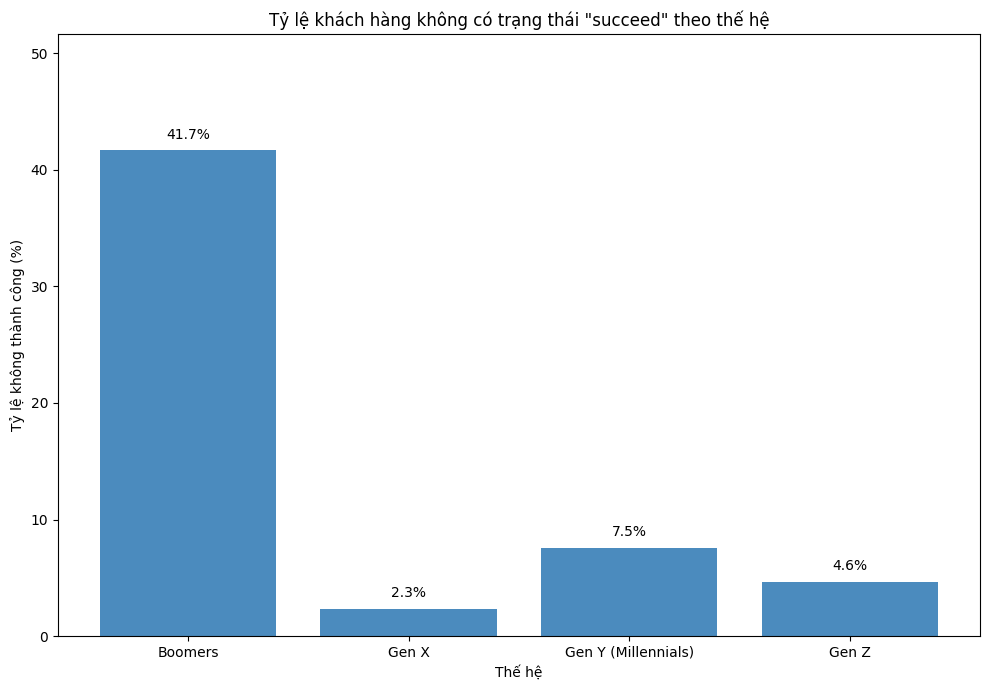

In [84]:
# Bước 2: Xác định các khách hàng không có status = 'succeed'
df_status = df_eda.groupby(['customer_id', 'generation'])['status'].apply(list).reset_index()
df_status['has_succeed'] = df_status['status'].apply(lambda x: 'succeed' in x)
df_status['is_failed'] = ~df_status['has_succeed']  # khách chưa từng succeed

# Bước 3: Tính tỷ lệ theo generation
gen_stats = df_status.groupby('generation').agg(
    total_customers=('customer_id', 'count'),
    failed_customers=('is_failed', 'sum')
).reset_index()

gen_stats['fail_rate_percent'] = (gen_stats['failed_customers'] / gen_stats['total_customers']) * 100

# Bước 4: Vẽ biểu đồ cột
plt.figure(figsize=(10, 7))
plt.bar(gen_stats['generation'], gen_stats['fail_rate_percent'], color='#4B8BBE')
plt.title('Tỷ lệ khách hàng không có trạng thái "succeed" theo thế hệ')
plt.xlabel('Thế hệ')
plt.ylabel('Tỷ lệ không thành công (%)')

# Hiển thị giá trị phần trăm trên cột
for i, val in enumerate(gen_stats['fail_rate_percent']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.ylim(0, gen_stats['fail_rate_percent'].max() + 10)
plt.tight_layout()
plt.show()

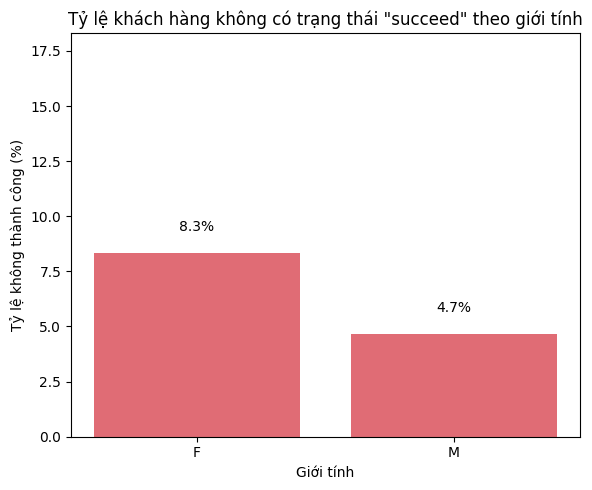

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': plt.rcParamsDefault['font.size']})


# Bước 1: Gom thông tin trạng thái theo từng customer và giới tính
df_status = df_eda.groupby(['customer_id', 'gender'])['status'].apply(list).reset_index()

# Bước 2: Xác định khách không có succeed
df_status['has_succeed'] = df_status['status'].apply(lambda x: 'succeed' in x)
df_status['is_failed'] = ~df_status['has_succeed']  # True nếu không có 'succeed'

# Bước 3: Tính tổng khách và số khách không succeed theo gender
gender_stats = df_status.groupby('gender').agg(
    total_customers=('customer_id', 'count'),
    failed_customers=('is_failed', 'sum')
).reset_index()

gender_stats['fail_rate_percent'] = (gender_stats['failed_customers'] / gender_stats['total_customers']) * 100

# Bước 4: Vẽ biểu đồ
plt.figure(figsize=(6, 5))
plt.bar(gender_stats['gender'], gender_stats['fail_rate_percent'], color='#E06C75')
plt.title('Tỷ lệ khách hàng không có trạng thái "succeed" theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Tỷ lệ không thành công (%)')

# Thêm nhãn phần trăm trên cột
for i, val in enumerate(gender_stats['fail_rate_percent']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.ylim(0, gender_stats['fail_rate_percent'].max() + 10)
plt.tight_layout()
plt.show()


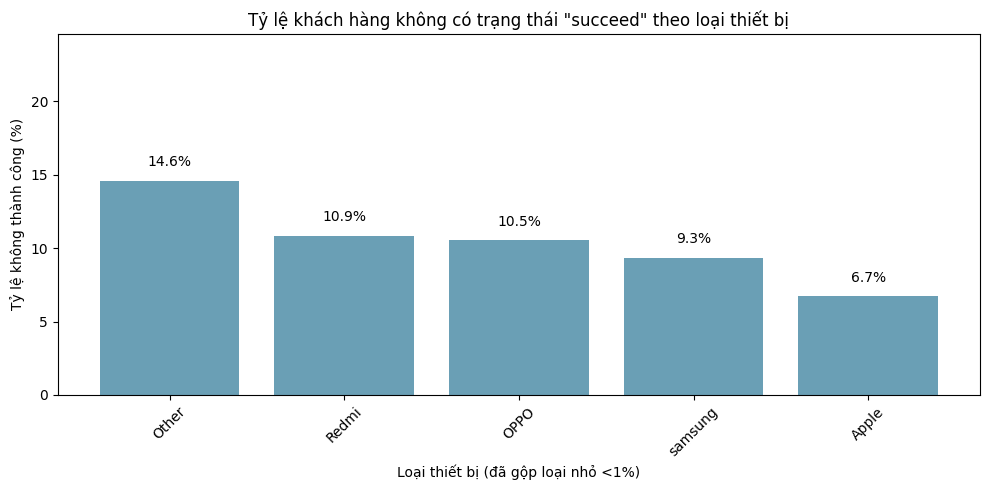

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Bước 1: Gộp các phone_type < 1% thành 'Other'
total_customers = df_eda['customer_id'].nunique()
phone_counts = df_eda.groupby('phone_type')['customer_id'].nunique()
phone_share = phone_counts / total_customers

# Gán nhãn 'Other' cho phone_type chiếm < 1%
small_types = phone_share[phone_share < 0.01].index
df_eda['phone_type_clean'] = df_eda['phone_type'].apply(lambda x: 'Other' if x in small_types else x)

# Bước 2: Gom trạng thái theo customer và phone_type đã làm sạch
df_status = df_eda.groupby(['customer_id', 'phone_type_clean'])['status'].apply(list).reset_index()
df_status['has_succeed'] = df_status['status'].apply(lambda x: 'succeed' in x)
df_status['is_failed'] = ~df_status['has_succeed']

# Bước 3: Tính số lượng và tỷ lệ theo loại thiết bị
phone_stats = df_status.groupby('phone_type_clean').agg(
    total_customers=('customer_id', 'count'),
    failed_customers=('is_failed', 'sum')
).reset_index()

phone_stats['fail_rate_percent'] = (phone_stats['failed_customers'] / phone_stats['total_customers']) * 100
phone_stats = phone_stats.sort_values(by='fail_rate_percent', ascending=False)

# Bước 4: Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.bar(phone_stats['phone_type_clean'], phone_stats['fail_rate_percent'], color='#6A9FB5')
plt.title('Tỷ lệ khách hàng không có trạng thái "succeed" theo loại thiết bị')
plt.xlabel('Loại thiết bị (đã gộp loại nhỏ <1%)')
plt.ylabel('Tỷ lệ không thành công (%)')

# Nhãn dữ liệu trên cột
for i, val in enumerate(phone_stats['fail_rate_percent']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.ylim(0, phone_stats['fail_rate_percent'].max() + 10)
plt.tight_layout()
plt.show()


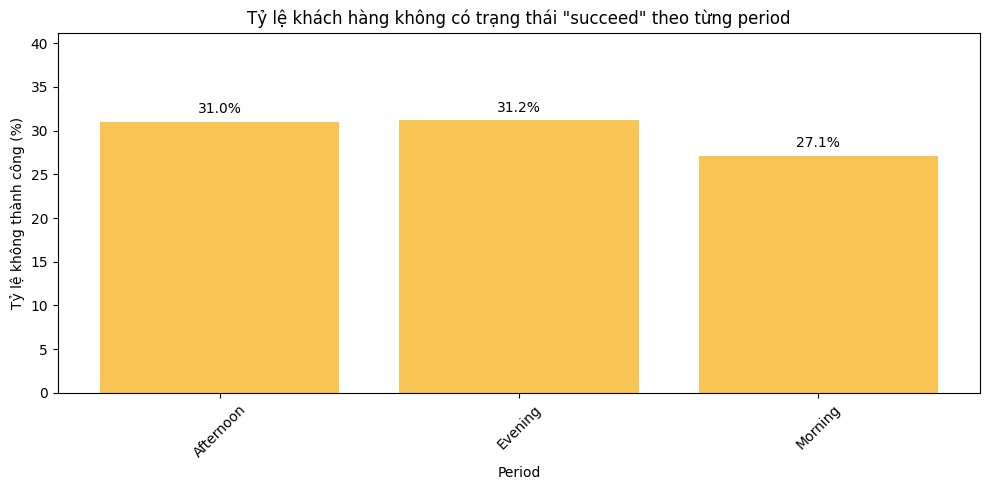

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Bước 1: Gom trạng thái theo customer và period
df_status = df_eda.groupby(['customer_id', 'time_period'])['status'].apply(list).reset_index()

# Bước 2: Xác định khách không có trạng thái succeed
df_status['has_succeed'] = df_status['status'].apply(lambda x: 'succeed' in x)
df_status['is_failed'] = ~df_status['has_succeed']

# Bước 3: Tính số lượng và tỷ lệ theo period
period_stats = df_status.groupby('time_period').agg(
    total_customers=('customer_id', 'count'),
    failed_customers=('is_failed', 'sum')
).reset_index()

period_stats['fail_rate_percent'] = (period_stats['failed_customers'] / period_stats['total_customers']) * 100
period_stats = period_stats.sort_values(by='time_period')

# Bước 4: Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.bar(period_stats['time_period'], period_stats['fail_rate_percent'], color='#F8C555')
plt.title('Tỷ lệ khách hàng không có trạng thái "succeed" theo từng period')
plt.xlabel('Period')
plt.ylabel('Tỷ lệ không thành công (%)')

# Nhãn phần trăm trên cột
for i, val in enumerate(period_stats['fail_rate_percent']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.ylim(0, period_stats['fail_rate_percent'].max() + 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##**3. Phân tích hiệu quả mở tài khoản**

In [88]:
import pandas as pd

# --- Bước 1: Đảm bảo cột thời gian có định dạng datetime ---
# Kiểm tra kiểu dữ liệu của cột 'begin_time'. Nếu chưa phải datetime, chuyển đổi:
# df['begin_time'] = pd.to_datetime(df['begin_time'])
# df['close_time'] = pd.to_datetime(df['close_time'])
# Giả sử nó đã là datetime hoặc string có thể parse được.

# --- Bước 2-4: Nhóm, Sắp xếp và Tìm vị trí 'account-creation' đầu tiên ---

# Định nghĩa hàm tìm vị trí 0-based đầu tiên của 'account-creation' trong một Series
def find_first_account_creation_position(series):
    try:
        # Tìm vị trí 0-based của giá trị 'account-creation'
        # series.tolist() chuyển Series thành list để dùng phương thức index()
        position = series.tolist().index('account-creation')
        return position
    except ValueError:
        # Trả về giá trị đặc biệt (ví dụ: -1) nếu không tìm thấy 'account-creation'
        return -1

# Áp dụng hàm sau khi nhóm theo customer_id và sắp xếp theo thời gian
# groupby('customer_id'): Nhóm DataFrame theo customer_id
# apply(lambda x: ...): Áp dụng hàm cho mỗi nhóm (DataFrame con của 1 customer_id)
#   x.sort_values(by='begin_time')['stop_point']: Sắp xếp nhóm theo thời gian và chọn cột 'stop_point'.
#   find_first_account_creation_position(...): Tìm vị trí đầu tiên của 'account-creation' trong chuỗi stop_point đã sắp xếp.
# Kết quả: Series với index là customer_id, value là vị trí 0-based (-1 nếu không có).
first_ac_positions = df.groupby('customer_id').apply(
    lambda x: find_first_account_creation_position(x.sort_values(by='begin_time')['stop_point'])
)

# --- Bước 5: Đếm số lượng customer_id theo các khoảng vị trí mới ---

# Lọc ra những customer_id mà 'account-creation' có xuất hiện (vị trí >= 0)
customers_with_ac = first_ac_positions[first_ac_positions != -1]

# Đếm số lượng customer_id theo các điều kiện vị trí:
# Vị trí 0: 'account creation' xuất hiện đầu tiên (0 phiên thử trước đó)
count_pos_0 = (customers_with_ac == 0).sum()

# Vị trí 1, 2, hoặc 3: 'account creation' xuất hiện sau 1 đến 3 phiên thử
# Vị trí 0 là phiên 1, vị trí 1 là phiên 2, vị trí 2 là phiên 3, vị trí 3 là phiên 4.
# Xuất hiện sau 1-3 phiên thử nghĩa là ở vị trí 1, 2, hoặc 3 (phiên 2, 3, hoặc 4).
count_pos_1_to_3 = (customers_with_ac.isin([1, 2, 3])).sum()

# Vị trí >= 4: 'account creation' xuất hiện từ phiên thứ 5 trở đi (sau nhiều hơn 3 phiên thử)
# Vị trí 4 là phiên 5, vị trí 5 là phiên 6, ...
count_pos_geq_4 = (customers_with_ac >= 4).sum()


# In kết quả
print(f"Số lượng customer_id duy nhất có 'account-creation' xuất hiện đầu tiên (vị trí 0): {count_pos_0}")
print(f"Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau 1-3 phiên thử (vị trí 1, 2, hoặc 3): {count_pos_1_to_3}")
print(f"Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau nhiều hơn 3 phiên thử (vị trí 4 trở lên): {count_pos_geq_4}")

# (Tùy chọn) Kiểm tra tổng số customer có 'account-creation'
# print(f"\nTổng số customer_id duy nhất có 'account-creation' xuất hiện: {len(customers_with_ac)}")
# print(f"Tổng kiểm tra: {count_pos_0 + count_pos_1_to_3 + count_pos_geq_4}")

Số lượng customer_id duy nhất có 'account-creation' xuất hiện đầu tiên (vị trí 0): 4406
Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau 1-3 phiên thử (vị trí 1, 2, hoặc 3): 3558
Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau nhiều hơn 3 phiên thử (vị trí 4 trở lên): 579


/tmp/ipykernel_17872/914217198.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_ac_positions = df.groupby('customer_id').apply(


In [89]:
# Với mỗi customer_id, kiểm tra xem họ có từng có lần 'succeed' không
customer_status = df_eda.groupby('customer_id')['status'].apply(lambda x: 'succeed' in x.values)

# Số khách hàng không có bất kỳ lần succeed nào
non_succeed_customers = (~customer_status).sum()

# Tổng số khách hàng duy nhất
total_customers = customer_status.shape[0]

# Tỷ lệ %
non_succeed_ratio = non_succeed_customers / total_customers * 100

# In kết quả
print(f"Tỷ lệ khách hàng không có lần nào thành công: {non_succeed_ratio:.2f}%")


Tỷ lệ khách hàng không có lần nào thành công: 6.61%


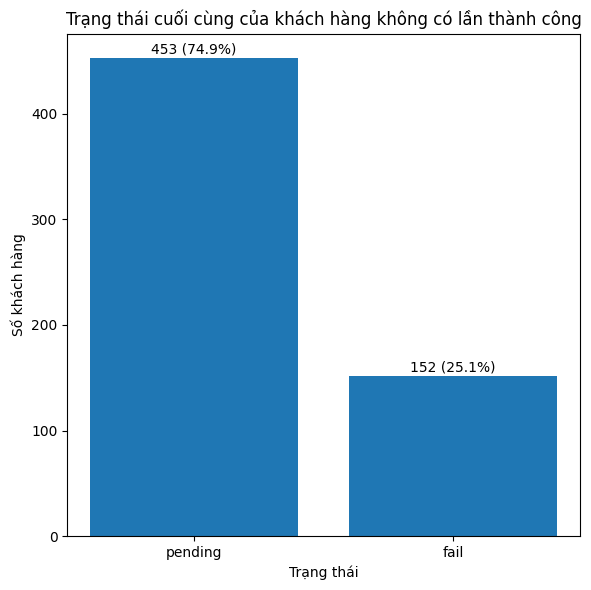

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Bước 1: Với mỗi customer_id, kiểm tra có từng succeed chưa
customer_success = df_eda.groupby('customer_id')['status'].apply(lambda x: 'succeed' in x.values)

# Bước 2: Lọc ra những khách hàng không có lần nào succeed
non_success_ids = customer_success[~customer_success].index

# Bước 3: Lọc dữ liệu chỉ của nhóm khách hàng không thành công
df_non_success = df_eda[df_eda['customer_id'].isin(non_success_ids)]

# Bước 4: Lấy trạng thái cuối cùng (latest status) của mỗi customer
df_non_success_sorted = df_non_success.sort_values(by='close_time')
last_status = df_non_success_sorted.groupby('customer_id').tail(1)

# Bước 5: Đếm số lượng theo trạng thái cuối cùng
status_counts = last_status['status'].value_counts()
total_non_success = len(last_status)
status_percent = status_counts / total_non_success * 100

# Bước 6: Vẽ biểu đồ
plt.figure(figsize=(6, 6))
bars = plt.bar(status_counts.index, status_counts.values)

# Thêm data label: giá trị và %
for i, bar in enumerate(bars):
    count = status_counts.values[i]
    percent = status_percent.values[i]
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{count} ({percent:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title('Trạng thái cuối cùng của khách hàng không có lần thành công')
plt.xlabel('Trạng thái')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [91]:
# Số lượng phiên fail
fail_count = df_eda[df_eda['status'] == 'fail'].shape[0]

# Số lượng customer duy nhất
customer_count = df_eda['customer_id'].nunique()

# Tỷ lệ số lần fail trên mỗi khách hàng
avg_fail_per_customer = fail_count / customer_count

# Hiển thị kết quả
print(f"Số lượt fail: {fail_count}")
print(f"Số lượng khách hàng: {customer_count}")
print(f"Tỷ lệ fail trung bình trên mỗi khách hàng: {avg_fail_per_customer:.2f}")


Số lượt fail: 5922
Số lượng khách hàng: 9148
Tỷ lệ fail trung bình trên mỗi khách hàng: 0.65


In [92]:
df_eda.status.value_counts()

,count
status,
pending,11281
succeed,8543
fail,5922


In [93]:
# Bước 1: Xác định các customer_id có ít nhất một lần status = 'succeed'
customers_with_success = df_eda[df_eda['status'] == 'succeed']['customer_id'].unique()

# Bước 2: Lọc ra các phiên của khách hàng KHÔNG có succeed
df_no_success = df_eda[~df_eda['customer_id'].isin(customers_with_success)]

# Bước 3: Tính số lượt fail của nhóm này
fail_count = df_no_success[df_no_success['status'] == 'fail'].shape[0]

# Bước 4: Tính số lượng khách hàng duy nhất trong nhóm này
customer_count = df_no_success['customer_id'].nunique()

# Bước 5: Tính tỷ lệ fail trung bình trên mỗi khách hàng
fail_rate_per_customer = fail_count / customer_count

# Hiển thị kết quả
print(f"Số lượt fail (trong nhóm không có succeed): {fail_count}")
print(f"Số khách hàng không có succeed: {customer_count}")
print(f"Tỷ lệ fail trung bình / khách hàng (trong nhóm không có succeed): {fail_rate_per_customer:.2f}")


Số lượt fail (trong nhóm không có succeed): 937
Số khách hàng không có succeed: 605
Tỷ lệ fail trung bình / khách hàng (trong nhóm không có succeed): 1.55


In [94]:
# Bước 1: Lấy các customer_id có ít nhất một lần succeed
customers_with_success = df_eda[df_eda['status'] == 'succeed']['customer_id'].unique()

# Bước 2: Lọc ra các bản ghi của nhóm này
df_success_group = df_eda[df_eda['customer_id'].isin(customers_with_success)]

# Bước 3: Đếm số lượt fail trong nhóm này
fail_count = df_success_group[df_success_group['status'] == 'fail'].shape[0]

# Bước 4: Đếm số lượng customer duy nhất trong nhóm
customer_count = df_success_group['customer_id'].nunique()

# Bước 5: Tính tỷ lệ fail trung bình trên mỗi khách hàng
fail_rate_per_customer = fail_count / customer_count

# Hiển thị kết quả
print(f"Số lượt fail (trong nhóm có succeed): {fail_count}")
print(f"Số khách hàng có succeed: {customer_count}")
print(f"Tỷ lệ fail trung bình / khách hàng (trong nhóm có succeed): {fail_rate_per_customer:.2f}")


Số lượt fail (trong nhóm có succeed): 4985
Số khách hàng có succeed: 8543
Tỷ lệ fail trung bình / khách hàng (trong nhóm có succeed): 0.58


In [95]:
# Với từng customer_id duy nhất, tìm những người không có status là 'succeed' trong bất kỳ phiên nào

# Lấy tất cả các customer_id có ít nhất một dòng succeed
succeeded_customers = df_eda[df_eda['status'] == 'succeed']['customer_id'].unique()

# Lấy tất cả customer_id duy nhất
all_customers = df_eda['customer_id'].unique()

# Tìm các customer_id không có bất kỳ phiên nào là succeed
failed_customers = list(set(all_customers) - set(succeeded_customers))

# Đếm tổng số lượng khách không bao giờ thành công
num_failed_customers = len(failed_customers)

# Xuất kết quả dưới dạng DataFrame để kiểm tra
failed_customers_df = pd.DataFrame({'customer_id': failed_customers})

#import ace_tools as tools; tools.display_dataframe_to_user(name="Customer ID không có phiên succeed", dataframe=failed_customers_df)

num_failed_customers

605

In [96]:
# Lọc ra các dòng thuộc các customer không thành công
failed_df = df_eda[df_eda['customer_id'].isin(failed_customers)].copy()

# Sắp xếp theo customer_id và begin_time để lấy phiên cuối cùng của mỗi khách
failed_df_sorted = failed_df.sort_values(by=['customer_id', 'begin_time'])
last_stop_failed = failed_df_sorted.groupby('customer_id').last().reset_index()

# Đếm tần suất stop_point cuối cùng trong nhóm không thành công
stop_point_counts = last_stop_failed['stop_point'].value_counts().reset_index()
stop_point_counts.columns = ['stop_point', 'count']

#import ace_tools as tools; tools.display_dataframe_to_user(name="Stop Point cuối cùng phổ biến nhất (khách thất bại)", dataframe=stop_point_counts)

stop_point_counts.head(10)


,stop_point,count
0,ocr-failed,202
1,otp-failed,171
2,data-privacy-rejected,168
3,contract-rejected,37
4,check-failed,20
5,selfie-failed,7


###Bắt đầu phân tích lỗi sâu

###Bổ sung

In [97]:
df_eda.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation,month,date,phone_type_clean
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials),2024-03,2024-03-01,Apple
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials),2024-03,2024-03-01,Apple
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z,2024-03,2024-03-01,Apple
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z,2024-03,2024-03-01,Apple
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z,2024-03,2024-03-04,Apple


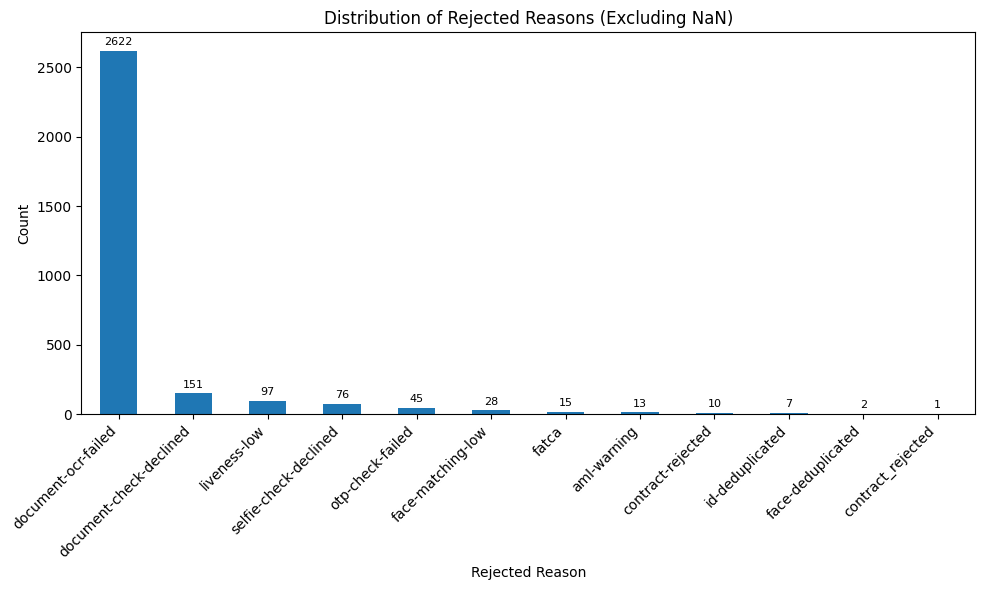

In [98]:
import matplotlib.pyplot as plt

# Đếm số lượng từng lý do bị từ chối (bỏ qua NaN)
rejected_distribution = df_eda['rejected_reason'].dropna().value_counts()

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
ax = rejected_distribution.plot(kind='bar')

plt.title('Distribution of Rejected Reasons (Excluding NaN)')
plt.xlabel('Rejected Reason')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Thêm nhãn dữ liệu trên từng cột
for i, val in enumerate(rejected_distribution.values):
    ax.text(i, val + max(rejected_distribution.values)*0.01, str(val), ha='center', va='bottom', fontsize=8)

plt.show()


####Tổng quan Lỗi

In [99]:
df_eda.stop_point.value_counts()

,count
stop_point,
account-creation,8543
otp-failed,5612
ocr-failed,5404
data-privacy-rejected,2398
contract-rejected,1785
check-failed,1632
selfie-failed,372


              stop_point  avg_fail_repeats
3             ocr-failed          2.380995
4             otp-failed          1.404040
5          selfie-failed          1.144105
0           check-failed          1.129489
2  data-privacy-rejected          1.128205
1      contract-rejected          1.038393


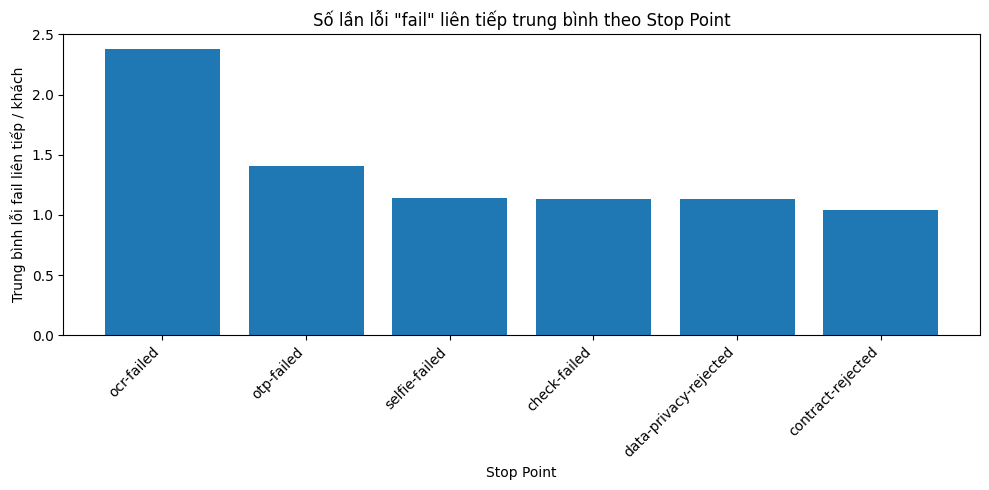

In [100]:
# Lọc chỉ lỗi có status = 'fail'
df_fail = df_sorted[df_sorted['status'] == 'fail'].copy()

# Đảm bảo đúng thứ tự hành trình
df_fail = df_fail.sort_values(by=['customer_id', 'begin_time'])

# So sánh stop_point với dòng trước theo từng customer
df_fail['prev_stop'] = df_fail.groupby('customer_id')['stop_point'].shift(1)
df_fail['new_group'] = (df_fail['stop_point'] != df_fail['prev_stop']).astype(int)
df_fail['repeat_block'] = df_fail.groupby('customer_id')['new_group'].cumsum()

# Đếm độ dài mỗi chuỗi lỗi liên tiếp giống nhau
repeat_lengths = df_fail.groupby(['customer_id', 'repeat_block', 'stop_point']).size().reset_index(name='repeat_count')

# Tính trung bình độ dài lỗi liên tiếp theo stop_point
avg_consecutive_fail = repeat_lengths.groupby('stop_point')['repeat_count'].mean().reset_index()
avg_consecutive_fail.columns = ['stop_point', 'avg_fail_repeats']
avg_consecutive_fail = avg_consecutive_fail.sort_values(by='avg_fail_repeats', ascending=False)

# Hiển thị kết quả
print(avg_consecutive_fail.head(10))

# Vẽ biểu đồ
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(avg_consecutive_fail['stop_point'], avg_consecutive_fail['avg_fail_repeats'])
plt.title('Số lần lỗi "fail" liên tiếp trung bình theo Stop Point')
plt.xlabel('Stop Point')
plt.ylabel('Trung bình lỗi fail liên tiếp / khách')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


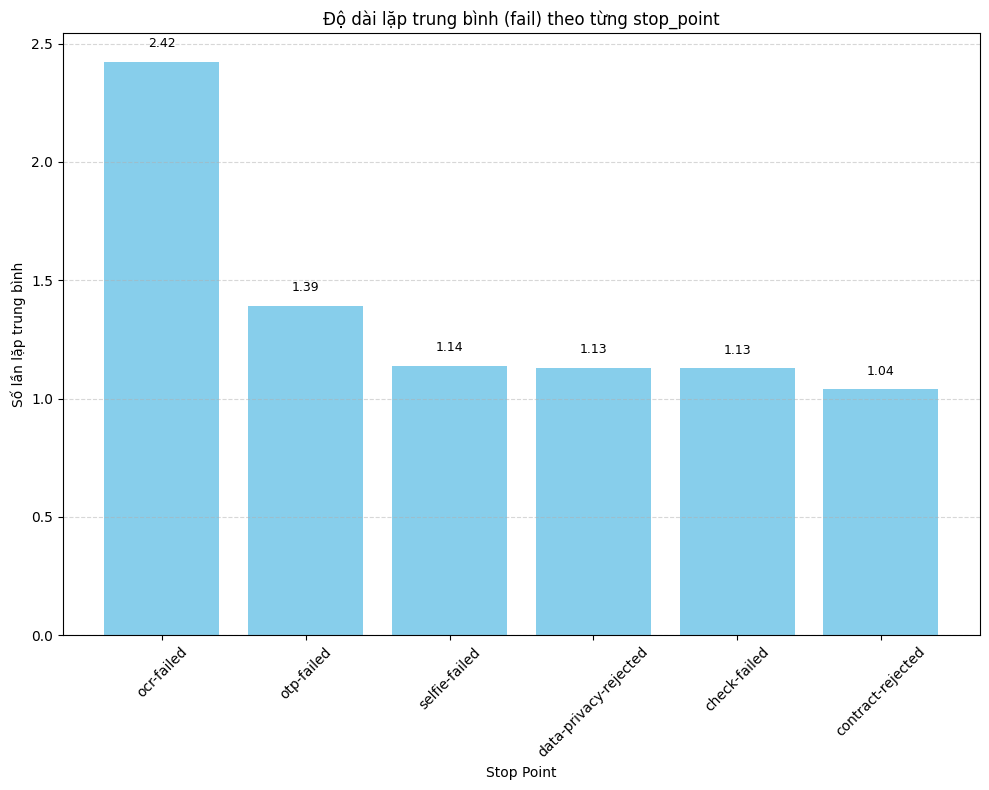

In [101]:
import pandas as pd

# Giả định df có cột: customer_id, begin_time, stop_point, status
# Bước 1: Lọc chỉ những dòng có status là 'fail'
df_fail = df_eda[df_eda['status'] == 'fail'].copy()

# Bước 2: Sắp xếp theo customer_id và thời gian để đảm bảo đúng trình tự
df_sorted = df_fail.sort_values(by=['customer_id', 'begin_time']).copy()

# Bước 3: Gắn nhãn nếu stop_point thay đổi => nhóm mới
df_sorted['stop_shift'] = df_sorted.groupby('customer_id')['stop_point'].shift(1)
df_sorted['new_group'] = (df_sorted['stop_point'] != df_sorted['stop_shift']).astype(int)

# Bước 4: Đánh số nhóm liên tiếp (chỉ trong các dòng failed)
df_sorted['repeat_group'] = df_sorted.groupby('customer_id')['new_group'].cumsum()

# Bước 5: Đếm số lần lặp liên tiếp cho mỗi stop_point trong từng cụm
repeat_lengths = df_sorted.groupby(['stop_point', 'customer_id', 'repeat_group']).size().reset_index(name='repeat_count')

# Bước 6: Tính độ dài lặp trung bình cho mỗi stop_point (chỉ với fail)
repeat_summary = repeat_lengths.groupby('stop_point')['repeat_count'].mean().reset_index()
repeat_summary.rename(columns={'repeat_count': 'avg_repeat_length'}, inplace=True)

# Hiển thị kết quả sắp xếp giảm dần
repeat_summary = repeat_summary.sort_values(by='avg_repeat_length', ascending=False)
repeat_summary
import matplotlib.pyplot as plt

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 8))
bars = plt.bar(repeat_summary['stop_point'], repeat_summary['avg_repeat_length'], color='skyblue')

# Thêm data label trên mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}',
             ha='center', va='bottom', fontsize=9)

# Tùy chỉnh biểu đồ
plt.title('Độ dài lặp trung bình (fail) theo từng stop_point')
plt.xlabel('Stop Point')
plt.ylabel('Số lần lặp trung bình')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


####Phân tích nhóm khách hàng theo lỗi

Với 2 lỗi tick box, team phân tích số lượng người từ chối thẳng và phần lớn nhóm đó như nào để lấy thông tin ban đầu

In [102]:
# Bước 1: Lấy danh sách khách hàng có ít nhất một dòng succeed
succeed_ids = set(df_eda[df_eda['status'] == 'succeed']['customer_id'])

# Bước 2: Giữ lại khách hàng KHÔNG có dòng succeed
df_filtered = df_eda[~df_eda['customer_id'].isin(succeed_ids)]

# Bước 3: Sắp xếp và lấy bước cuối cùng
df_sorted = df_filtered.sort_values(by=['customer_id', 'begin_time'])
last_step = df_sorted.groupby('customer_id').tail(1)

# Bước 4: Lọc các khách hàng kết thúc bằng data-privacy-rejected và fail/pending
target_customers = last_step[
    (last_step['stop_point'] == 'data-privacy-rejected') &
    (last_step['status'].isin(['fail', 'pending']))
]

# Bước 5: Phân tích thông tin
count = target_customers['customer_id'].nunique()
avg_age = target_customers['age'].mean()
mode_gender = target_customers['gender'].mode().iloc[0]
main_device = target_customers['phone_type'].mode().iloc[0]

# Hiển thị kết quả
print(f"Số khách hàng không có succeed và kết thúc bằng data-privacy-rejected: {count}")
print(f"Tuổi trung bình của nhóm này: {avg_age:.1f}")
print(f"Giới tính phổ biến nhất: {mode_gender}")
print(f"Loại thiết bị chính: {main_device}")


Số khách hàng không có succeed và kết thúc bằng data-privacy-rejected: 168
Tuổi trung bình của nhóm này: 31.7
Giới tính phổ biến nhất: F
Loại thiết bị chính: Apple


In [103]:
df.stop_point.value_counts()

,count
stop_point,
account-creation,8543
otp-failed,5612
ocr-failed,5404
data-privacy-rejected,2398
contract-rejected,1785
check-failed,1632
selfie-failed,372


In [104]:
# Bước 1: Lấy danh sách khách hàng có ít nhất một dòng succeed
succeed_ids = set(df_eda[df_eda['status'] == 'succeed']['customer_id'])

# Bước 2: Giữ lại khách hàng KHÔNG có dòng succeed
df_filtered = df_eda[~df_eda['customer_id'].isin(succeed_ids)]

# Bước 3: Sắp xếp và lấy bước cuối cùng
df_sorted = df_filtered.sort_values(by=['customer_id', 'begin_time'])
last_step = df_sorted.groupby('customer_id').tail(1)

# Bước 4: Lọc các khách hàng kết thúc bằng data-privacy-rejected và fail/pending
target_customers = last_step[
    (last_step['stop_point'] == 'contract-rejected') &
    (last_step['status'].isin(['fail', 'pending']))
]

# Bước 5: Phân tích thông tin
count = target_customers['customer_id'].nunique()
avg_age = target_customers['age'].mean()
mode_gender = target_customers['gender'].mode().iloc[0]
main_device = target_customers['phone_type'].mode().iloc[0]

# Hiển thị kết quả
print(f"Số khách hàng không có succeed và kết thúc bằng contract-agreement-rejected: {count}")
print(f"Tuổi trung bình của nhóm này: {avg_age:.1f}")
print(f"Giới tính phổ biến nhất: {mode_gender}")
print(f"Loại thiết bị chính: {main_device}")


Số khách hàng không có succeed và kết thúc bằng contract-agreement-rejected: 37
Tuổi trung bình của nhóm này: 33.7
Giới tính phổ biến nhất: M
Loại thiết bị chính: Apple


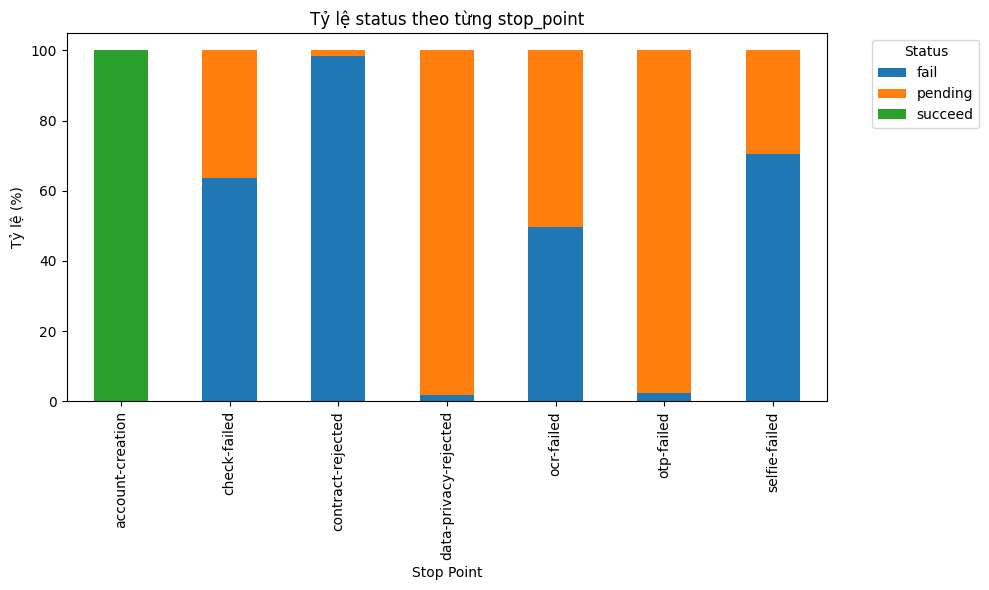

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# Tính số lượng mỗi status theo stop_point
status_counts = df_eda.groupby(['stop_point', 'status']).size().unstack(fill_value=0)

# Chuyển thành tỷ lệ phần trăm theo từng stop_point
status_percent = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

# Vẽ biểu đồ cột chồng
status_percent.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Tỷ lệ status theo từng stop_point')
plt.xlabel('Stop Point')
plt.ylabel('Tỷ lệ (%)')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


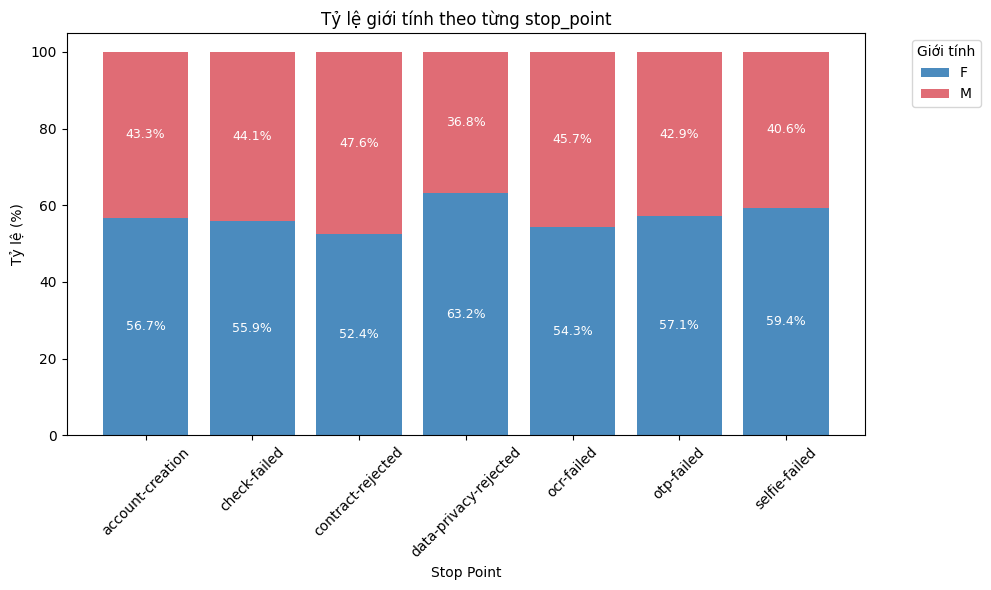

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# Đếm số lượng từng giới tính theo stop_point
gender_counts = df_eda.groupby(['stop_point', 'gender']).size().unstack(fill_value=0)

# Tính tỷ lệ phần trăm
gender_percent = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ từng phần giới tính
bottom = pd.Series([0] * len(gender_percent), index=gender_percent.index)
colors = ['#4B8BBE', '#E06C75']  # Ví dụ: màu cho nam và nữ

for i, gender in enumerate(gender_percent.columns):
    ax.bar(gender_percent.index,
           gender_percent[gender],
           bottom=bottom,
           label=gender,
           color=colors[i] if i < len(colors) else None)

    # Thêm nhãn dữ liệu
    for j, (value, btm) in enumerate(zip(gender_percent[gender], bottom)):
        if value > 0:
            ax.text(j, btm + value / 2,
                    f'{value:.1f}%',
                    ha='center', va='center', fontsize=9, color='white')

    bottom += gender_percent[gender]

# Thiết lập biểu đồ
ax.set_title('Tỷ lệ giới tính theo từng stop_point')
ax.set_xlabel('Stop Point')
ax.set_ylabel('Tỷ lệ (%)')
ax.legend(title='Giới tính', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


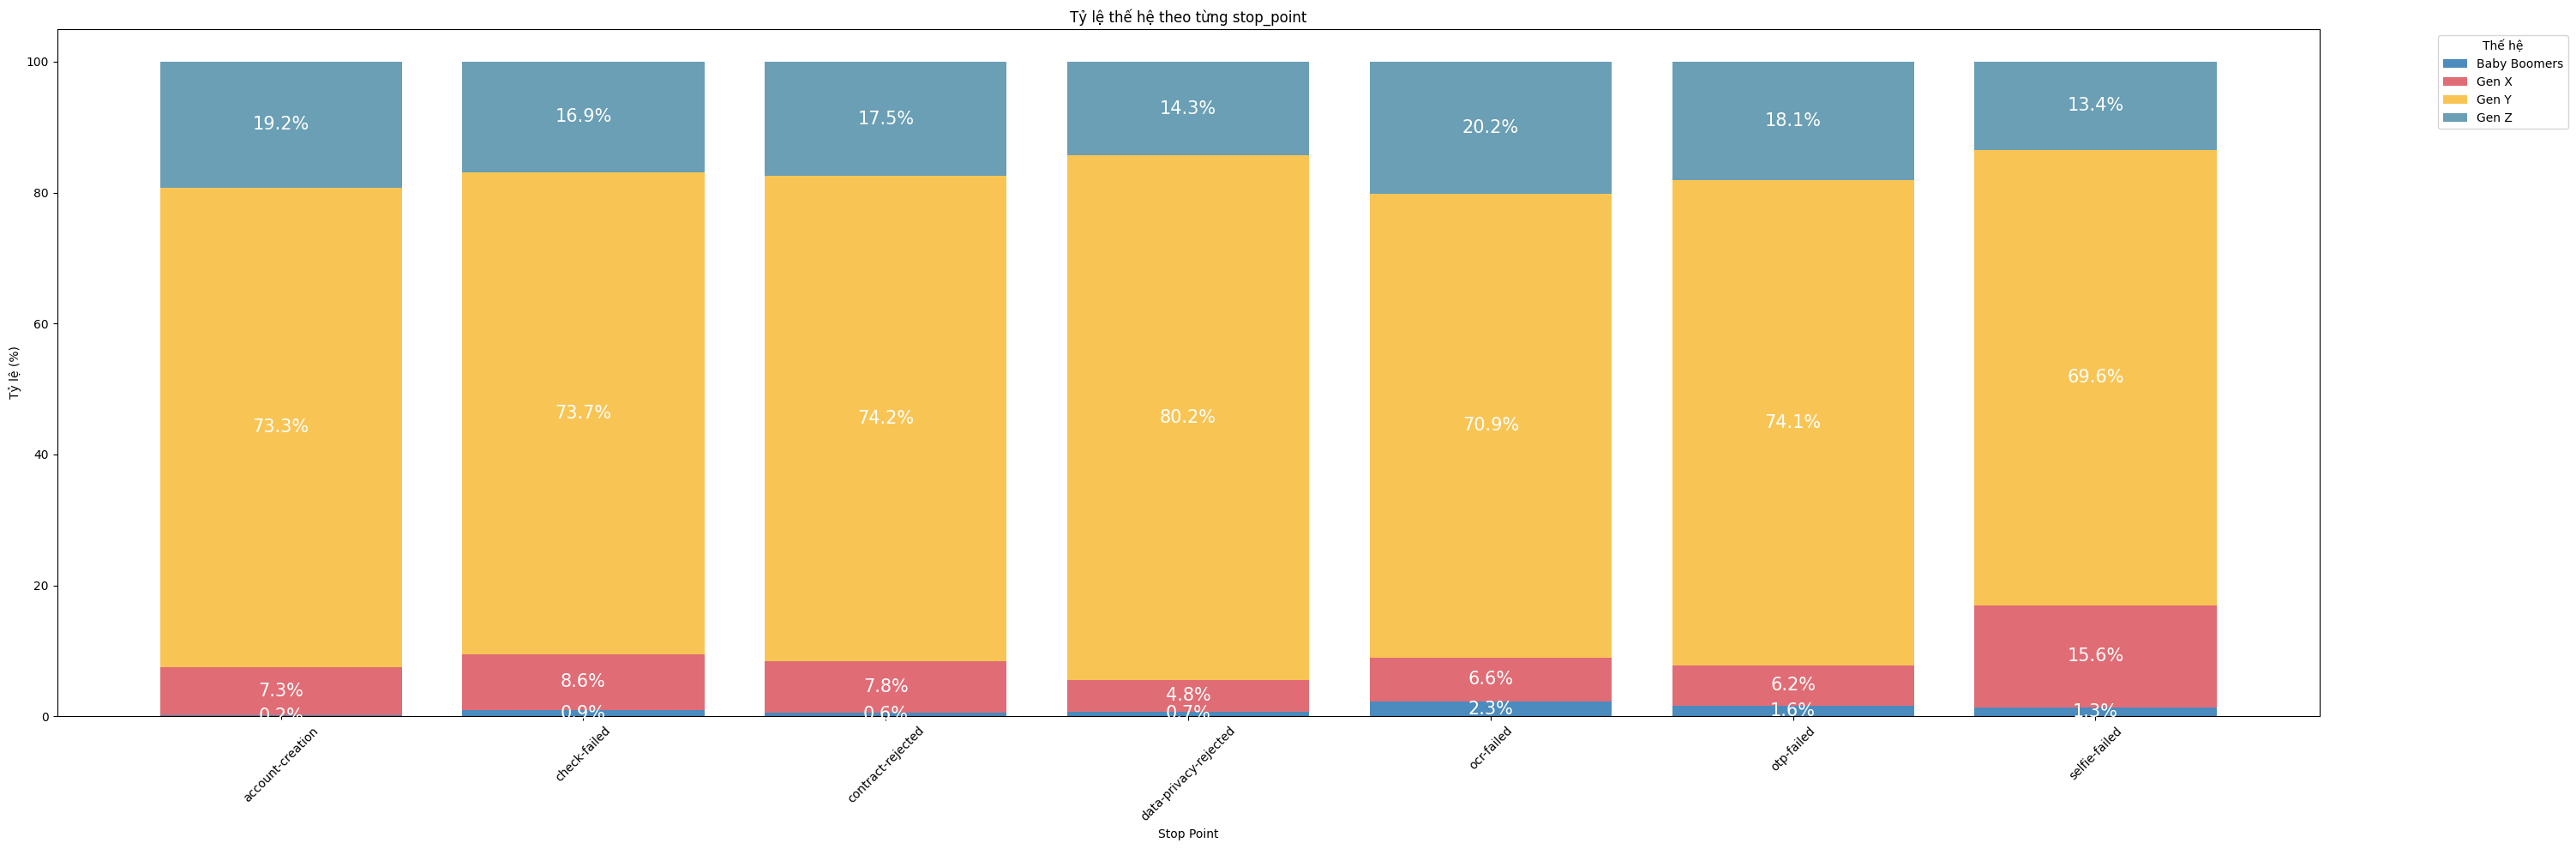

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to categorize generation based on birth year
def categorize_generation(year):
    if year >= 1997:
        return 'Gen Z'
    elif year >= 1981:
        return 'Gen Y'
    elif year >= 1965:
        return 'Gen X'
    elif year >= 1946:
        return 'Baby Boomers'


# Apply the function to create the 'generation' column
df_eda['generation'] = df_eda['birth_year'].apply(categorize_generation)

# Bước 1: Đếm số lượng mỗi thế hệ trong từng stop_point
gen_counts = df_eda.groupby(['stop_point', 'generation']).size().unstack(fill_value=0)

# Bước 2: Tính tỷ lệ phần trăm
gen_percent = gen_counts.div(gen_counts.sum(axis=1), axis=0) * 100

# Bước 3: Vẽ biểu đồ cột chồng có nhãn dữ liệu
fig, ax = plt.subplots(figsize=(30, 10))

# Khởi tạo vị trí bắt đầu cho mỗi cột (dùng cho stacked bar)
bottom = pd.Series([0] * len(gen_percent), index=gen_percent.index)

# Lựa chọn màu sắc cho từng thế hệ
colors = ['#4B8BBE', '#E06C75', '#F8C555', '#6A9FB5', '#9370DB'] # Added a color for Silent Generation

for i, gen in enumerate(gen_percent.columns):
    ax.bar(gen_percent.index,
           gen_percent[gen],
           bottom=bottom,
           label=gen,
           color=colors[i] if i < len(colors) else None)

    # Thêm data label
    for j, (value, btm) in enumerate(zip(gen_percent[gen], bottom)):
        if value > 0:
            ax.text(j, btm + value / 2,
        f'{value:.1f}%',
        ha='center', va='center',
        fontsize=15,  # <-- tăng từ 8 (cũ) hoặc 10 lên 12, 14 tùy nhu cầu
        color='white')

    bottom += gen_percent[gen]

# Tùy chỉnh biểu đồ
ax.set_title('Tỷ lệ thế hệ theo từng stop_point')
ax.set_xlabel('Stop Point')
ax.set_ylabel('Tỷ lệ (%)')
ax.legend(title='Thế hệ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

     Generation  Percentage (%)
0         Gen Y            73.7
1         Gen Z            18.4
2         Gen X             6.9
3  Baby Boomers             1.1


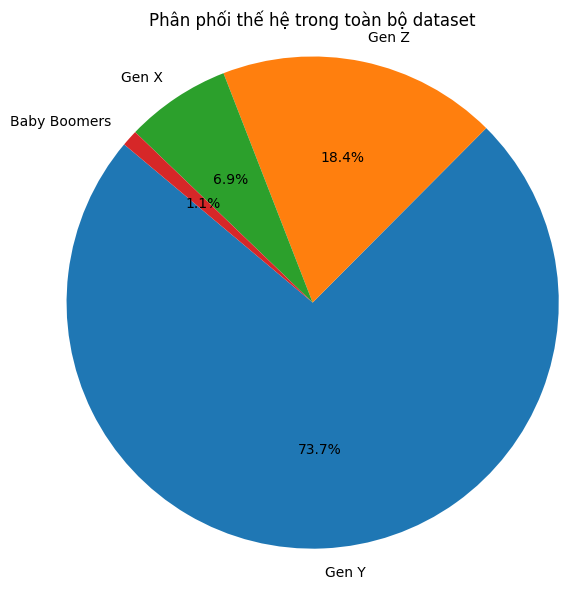

In [108]:
# Đếm số lượng từng thế hệ và tính phần trăm
gen_dist = df_eda['generation'].value_counts(normalize=True) * 100
gen_dist = gen_dist.round(1).reset_index()
gen_dist.columns = ['Generation', 'Percentage (%)']

print(gen_dist)
import matplotlib.pyplot as plt

# Đếm số lượng từng thế hệ
gen_counts = df_eda['generation'].value_counts()

# Vẽ pie chart
plt.figure(figsize=(6, 6))
plt.pie(gen_counts, labels=gen_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Phân phối thế hệ trong toàn bộ dataset')
plt.axis('equal')  # Giữ hình tròn
plt.tight_layout()
plt.show()


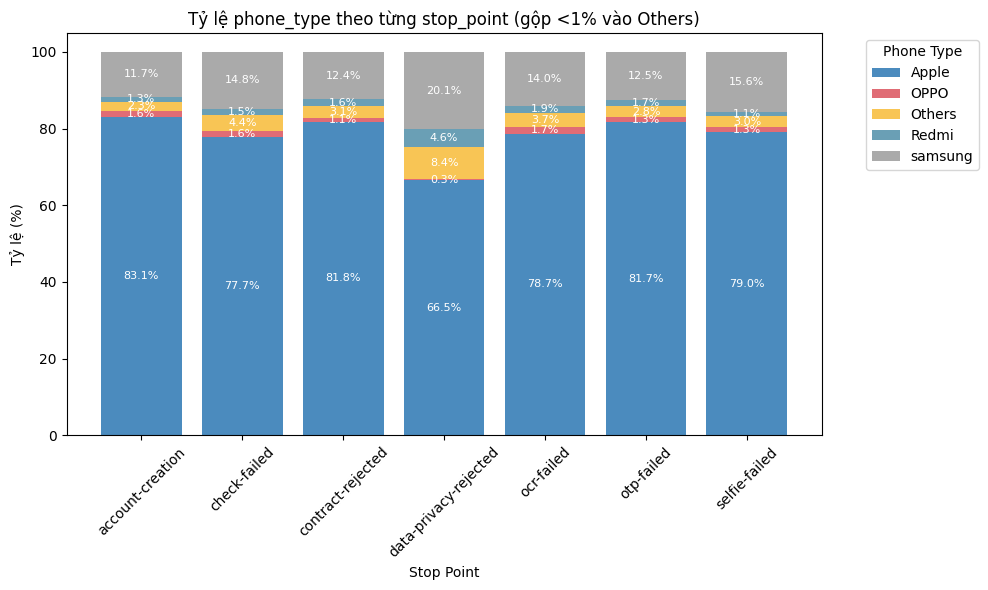

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
# Đếm tỷ lệ tổng thể của từng phone_type
phone_type_ratio = df_eda['phone_type'].value_counts(normalize=True)

# Lấy các phone_type chiếm dưới 1%
low_freq_types = phone_type_ratio[phone_type_ratio < 0.01].index

# Gộp lại thành 'Others'
df_eda['phone_type_grouped'] = df_eda['phone_type'].apply(lambda x: 'Others' if x in low_freq_types else x)

import matplotlib.pyplot as plt

# Tính lại số lượng theo stop_point và phone_type_grouped
phone_counts = df_eda.groupby(['stop_point', 'phone_type_grouped']).size().unstack(fill_value=0)

# Tính phần trăm
phone_percent = phone_counts.div(phone_counts.sum(axis=1), axis=0) * 100

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
bottom = pd.Series([0] * len(phone_percent), index=phone_percent.index)
colors = ['#4B8BBE', '#E06C75', '#F8C555', '#6A9FB5', '#AAAAAA']  # Thêm màu cho Others nếu cần

for i, ptype in enumerate(phone_percent.columns):
    ax.bar(phone_percent.index,
           phone_percent[ptype],
           bottom=bottom,
           label=ptype,
           color=colors[i % len(colors)])

    # Thêm data label
    for j, (value, btm) in enumerate(zip(phone_percent[ptype], bottom)):
        if value > 0:
            ax.text(j, btm + value / 2,
                    f'{value:.1f}%',
                    ha='center', va='center', fontsize=8, color='white')

    bottom += phone_percent[ptype]

# Tùy chỉnh biểu đồ
ax.set_title('Tỷ lệ phone_type theo từng stop_point (gộp <1% vào Others)')
ax.set_xlabel('Stop Point')
ax.set_ylabel('Tỷ lệ (%)')
ax.legend(title='Phone Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



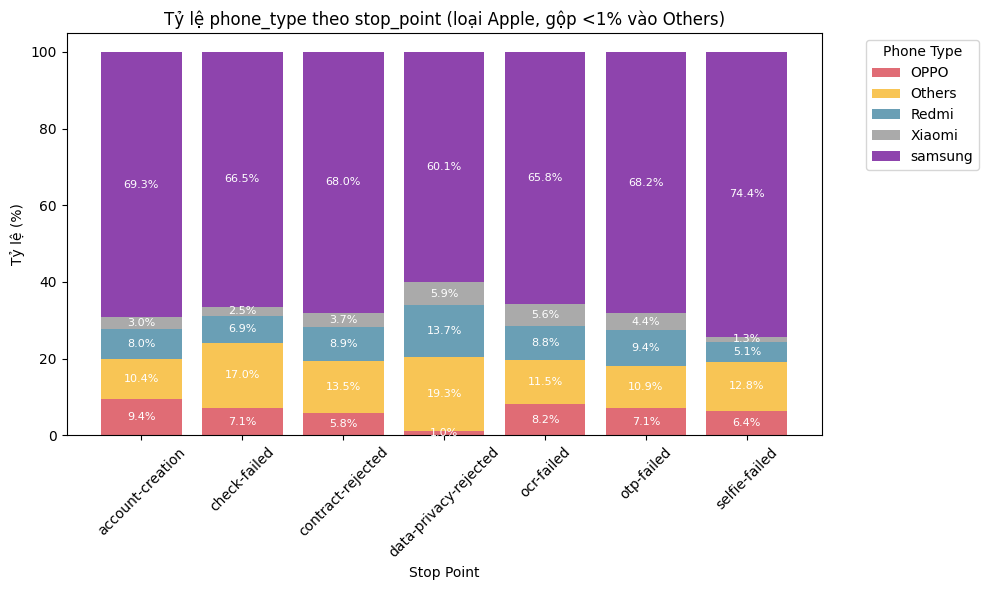

In [110]:
# Bỏ riêng Apple khỏi phân tích
df_phone = df_eda[df_eda['phone_type'] != 'Apple'].copy()

# Tính tỷ lệ phân bố phone_type (sau khi loại Apple)
phone_type_ratio = df_phone['phone_type'].value_counts(normalize=True)

# Xác định các phone_type chiếm <1% để gộp
low_freq_types = phone_type_ratio[phone_type_ratio < 0.03].index

# Gộp nhóm nhỏ thành "Others"
df_phone['phone_type_grouped'] = df_phone['phone_type'].apply(
    lambda x: 'Others' if x in low_freq_types else x
)
import matplotlib.pyplot as plt

# Đếm số lượng từng phone_type_grouped theo stop_point
phone_counts = df_phone.groupby(['stop_point', 'phone_type_grouped']).size().unstack(fill_value=0)

# Tính phần trăm
phone_percent = phone_counts.div(phone_counts.sum(axis=1), axis=0) * 100

# Vẽ biểu đồ stacked bar chart có data label
fig, ax = plt.subplots(figsize=(10, 6))
bottom = pd.Series([0] * len(phone_percent), index=phone_percent.index)
colors = ['#E06C75', '#F8C555', '#6A9FB5', '#AAAAAA', '#8E44AD']  # Có màu cho Others

for i, ptype in enumerate(phone_percent.columns):
    ax.bar(phone_percent.index,
           phone_percent[ptype],
           bottom=bottom,
           label=ptype,
           color=colors[i % len(colors)])

    # Gắn nhãn phần trăm
    for j, (value, btm) in enumerate(zip(phone_percent[ptype], bottom)):
        if value > 0:
            ax.text(j, btm + value / 2,
                    f'{value:.1f}%',
                    ha='center', va='center', fontsize=8, color='white')

    bottom += phone_percent[ptype]

# Tùy chỉnh biểu đồ
ax.set_title('Tỷ lệ phone_type theo stop_point (loại Apple, gộp <1% vào Others)')
ax.set_xlabel('Stop Point')
ax.set_ylabel('Tỷ lệ (%)')
ax.legend(title='Phone Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sau đó t bắt đâu phân tích sâu hơn

In [111]:
count = df_eda[(df_eda['stop_point'] == 'phone-failed') & (df_eda['status'] == 'fail')].shape[0]
print(f"Số dòng có stop_point = 'phone-failed' và status = 'fail': {count}")


Số dòng có stop_point = 'phone-failed' và status = 'fail': 0


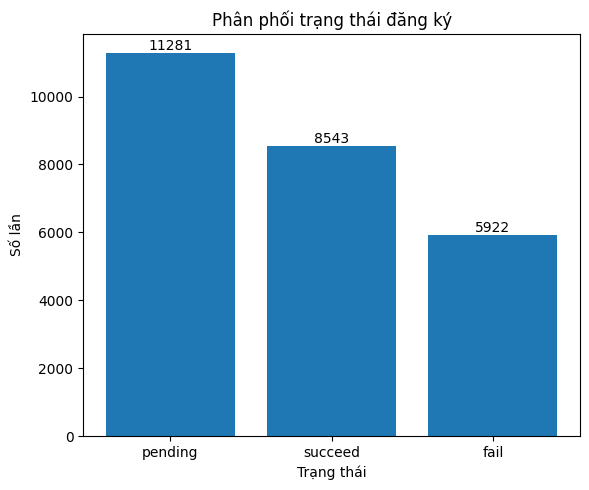

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# Đếm số lượng từng trạng thái
status_counts = df_eda['status'].value_counts()

# Vẽ biểu đồ
plt.figure(figsize=(6, 5))
bars = plt.bar(status_counts.index, status_counts.values)

# Thêm nhãn số lượng lên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 0.5,
             f'{int(height)}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.title('Phân phối trạng thái đăng ký')
plt.xlabel('Trạng thái')
plt.ylabel('Số lần')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [113]:
def categorize_generation(age):
    if age >= 60:
        return 'Boomer'
    elif 44 <= age < 60:
        return 'Gen X'
    elif 28 <= age < 44:
        return 'Gen Y (Millennials)'
    elif age < 28:
        return 'Gen Z'
    else:
        return 'Unknown'

# Thêm cột thế hệ vào df_eda
df_eda['generation'] = df_eda['age'].apply(categorize_generation)


In [114]:
df_eda.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation,month,date,phone_type_clean,phone_type_grouped
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z,2024-03,2024-03-01,Apple,Apple
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z,2024-03,2024-03-01,Apple,Apple
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z,2024-03,2024-03-04,Apple,Apple


In [115]:
df_eda

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation,month,date,phone_type_clean,phone_type_grouped
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z,2024-03,2024-03-01,Apple,Apple
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z,2024-03,2024-03-01,Apple,Apple
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z,2024-03,2024-03-04,Apple,Apple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25741,2024-02-29 14:20:00,2024-02-29 14:23:00,succeed,F,1990.0,Apple,iOS,16.4.1,NaN,account-creation,9146,3.0,34.0,Thursday,Afternoon,Gen Y (Millennials),2024-02,2024-02-29,Apple,Apple
25742,2024-03-01 15:29:00,2024-03-01 15:30:00,fail,M,1984.0,Apple,iOS,17.3.1,document-ocr-failed,ocr-failed,9147,1.0,40.0,Friday,Afternoon,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple
25743,2024-03-01 15:31:00,2024-03-01 15:31:00,pending,M,1984.0,Apple,iOS,17.3.1,NaN,otp-failed,9147,0.0,40.0,Friday,Afternoon,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple
25744,2024-03-01 15:32:00,2024-03-01 15:36:00,succeed,M,1984.0,Apple,iOS,17.3.1,NaN,account-creation,9147,4.0,40.0,Friday,Afternoon,Gen Y (Millennials),2024-03,2024-03-01,Apple,Apple


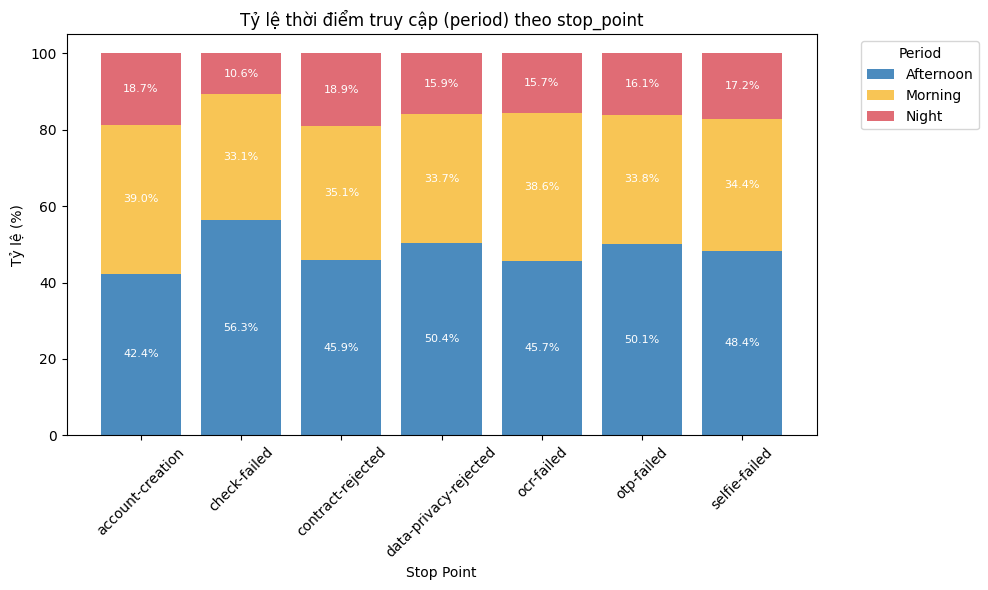

In [116]:
def classify_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Night'

df_eda['period'] = pd.to_datetime(df_eda['begin_time']).dt.hour.apply(classify_period)

import matplotlib.pyplot as plt
import pandas as pd

# Đếm số lượng mỗi period theo stop_point
period_counts = df_eda.groupby(['stop_point', 'period']).size().unstack(fill_value=0)

# Tính phần trăm theo từng stop_point
period_percent = period_counts.div(period_counts.sum(axis=1), axis=0) * 100

# Vẽ stacked bar chart có nhãn
fig, ax = plt.subplots(figsize=(10, 6))
bottom = pd.Series([0] * len(period_percent), index=period_percent.index)
colors = ['#4B8BBE', '#F8C555', '#E06C75', '#6A9FB5']  # Tùy chọn màu cho Morning, Afternoon...

for i, period in enumerate(period_percent.columns):
    ax.bar(period_percent.index,
           period_percent[period],
           bottom=bottom,
           label=period,
           color=colors[i % len(colors)])

    # Thêm nhãn phần trăm
    for j, (value, btm) in enumerate(zip(period_percent[period], bottom)):
        if value > 0:
            ax.text(j, btm + value / 2,
                    f'{value:.1f}%',
                    ha='center', va='center', fontsize=8, color='white')

    bottom += period_percent[period]

# Tùy chỉnh hiển thị
ax.set_title('Tỷ lệ thời điểm truy cập (period) theo stop_point')
ax.set_xlabel('Stop Point')
ax.set_ylabel('Tỷ lệ (%)')
ax.legend(title='Period', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


      Period  Percentage (%)
0  Afternoon            46.7
1    Morning            36.6
2      Night            16.7


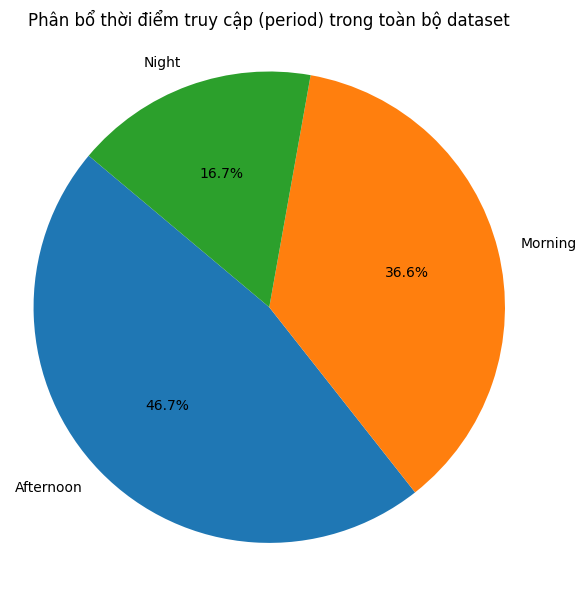

In [117]:
# Tính phần trăm từng period
period_dist = df_eda['period'].value_counts(normalize=True) * 100
period_dist = period_dist.round(1).reset_index()
period_dist.columns = ['Period', 'Percentage (%)']

print(period_dist)
import matplotlib.pyplot as plt

# Đếm số lượng từng period
period_counts = df_eda['period'].value_counts()

# Vẽ pie chart
plt.figure(figsize=(6, 6))
plt.pie(period_counts,
        labels=period_counts.index,
        autopct='%1.1f%%',
        startangle=140)
plt.title('Phân bổ thời điểm truy cập (period) trong toàn bộ dataset')
plt.axis('equal')  # Giữ hình tròn
plt.tight_layout()
plt.show()


In [118]:
# Bước 1: Sắp xếp dữ liệu theo customer_id và begin_time để đảm bảo đúng thứ tự hành trình
df_sorted = df_eda.sort_values(by=['customer_id', 'begin_time']).copy()

# Bước 2: Gán thứ tự dòng (step position) trong hành trình của mỗi customer
df_sorted['step_position'] = df_sorted.groupby('customer_id').cumcount() + 1

# Bước 3: Lọc các dòng lỗi (pending hoặc fail)
df_error = df_sorted[df_sorted['status'].isin(['pending', 'fail'])]

# Bước 4: Đếm số lượng customer_id duy nhất bị lỗi ở từng vị trí
error_by_position = df_error.groupby('step_position')['customer_id'].nunique().reset_index()
error_by_position.columns = ['step_position', 'num_error_customers']

# Giới hạn đến 8 bước đầu nếu cần
error_by_position = error_by_position[error_by_position['step_position'] <= 84]

print(error_by_position)


    step_position  num_error_customers
0               1                 5417
1               2                 3561
2               3                 2151
3               4                 1265
4               5                  866
..            ...                  ...
77             78                    1
78             79                    1
79             80                    1
80             81                    1
81             83                    1

[82 rows x 2 columns]


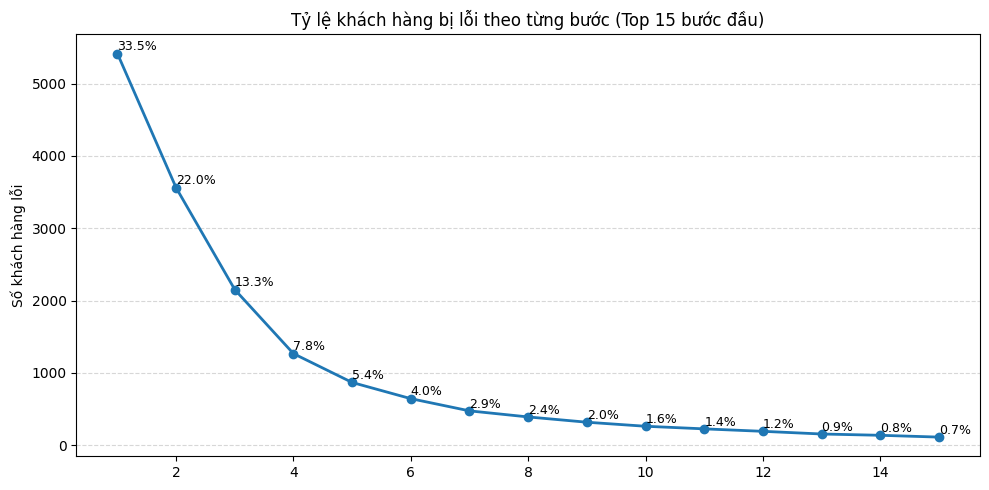

In [119]:
import matplotlib.pyplot as plt

# Lấy 15 dòng đầu
error_top15 = error_by_position.head(15).copy()

# Tính tổng để tính phần trăm
total = error_top15['num_error_customers'].sum()
error_top15['percent'] = (error_top15['num_error_customers'] / total * 100).round(1)

# Vẽ line chart
plt.figure(figsize=(10, 5))
plt.plot(error_top15['step_position'],
         error_top15['num_error_customers'],
         marker='o',
         linewidth=2)

# Thêm nhãn phần trăm trên mỗi điểm
for i in range(len(error_top15)):
    x = error_top15['step_position'].iloc[i]
    y = error_top15['num_error_customers'].iloc[i]
    pct = error_top15['percent'].iloc[i]
    plt.text(x, y + 3, f'{pct}%', ha='left', va='bottom', fontsize=9)

# Tùy chỉnh biểu đồ
plt.title('Tỷ lệ khách hàng bị lỗi theo từng bước (Top 15 bước đầu)')
plt.xlabel('')
plt.ylabel('Số khách hàng lỗi')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


              stop_point  num_customers
0       account-creation            879
1             ocr-failed            684
2      contract-rejected            422
3             otp-failed            395
4           check-failed            304
5  data-privacy-rejected            296
6          selfie-failed             50


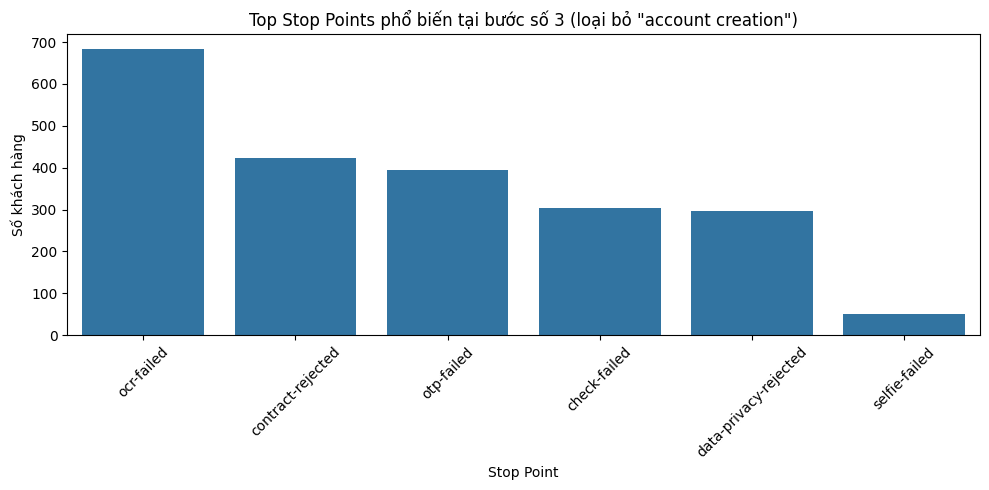

In [120]:
# Lọc ra những dòng có step_position = 3
step3_data = df_sorted[df_sorted['step_position'] == 3]

# Đếm số lượng khách hàng ở từng stop_point tại bước 3
stop_counts = step3_data['stop_point'].value_counts().reset_index()
stop_counts.columns = ['stop_point', 'num_customers']

# Hiển thị top các stop point phổ biến nhất
print(stop_counts.head(10))
import seaborn as sns

# Lọc dữ liệu bước 3 và loại bỏ 'account creation'
step3_data = df_sorted[(df_sorted['step_position'] == 3) &
                       (df_sorted['stop_point'] != 'account-creation')]

# Đếm số lượng khách hàng ở từng stop_point
stop_counts = step3_data['stop_point'].value_counts().reset_index()
stop_counts.columns = ['stop_point', 'num_customers']

# Vẽ biểu đồ
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.barplot(data=stop_counts.head(10), x='stop_point', y='num_customers')
plt.title('Top Stop Points phổ biến tại bước số 3 (loại bỏ "account creation")')
plt.xlabel('Stop Point')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



              stop_point  num_customers
0             ocr-failed            494
1       account-creation            424
2  data-privacy-rejected            235
3             otp-failed            203
4      contract-rejected            158
5           check-failed            152
6          selfie-failed             23


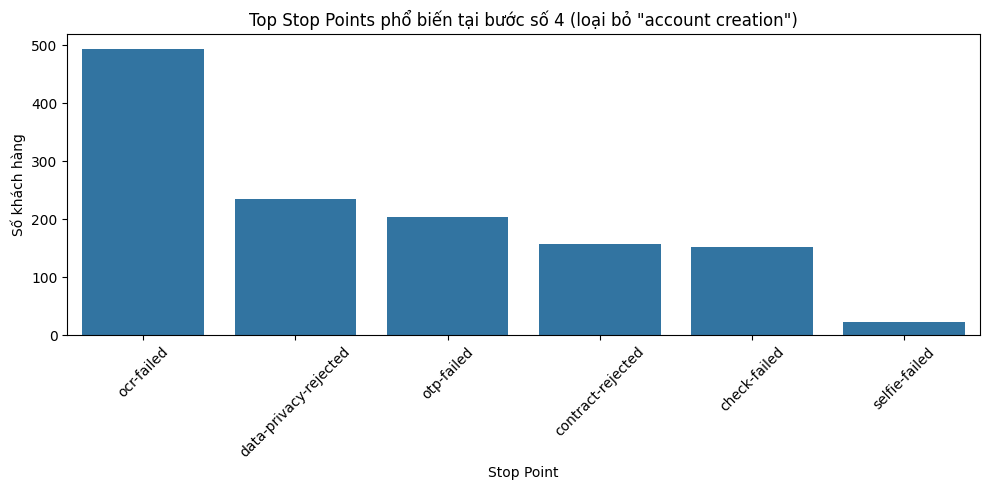

In [121]:
# Lọc ra những dòng có step_position = 3
step3_data = df_sorted[df_sorted['step_position'] == 4]

# Đếm số lượng khách hàng ở từng stop_point tại bước 3
stop_counts = step3_data['stop_point'].value_counts().reset_index()
stop_counts.columns = ['stop_point', 'num_customers']

# Hiển thị top các stop point phổ biến nhất
print(stop_counts.head(10))
import seaborn as sns

# Lọc dữ liệu bước 4 và loại bỏ 'account creation'
step3_data = df_sorted[(df_sorted['step_position'] == 4) &
                       (df_sorted['stop_point'] != 'account-creation')]

# Đếm số lượng khách hàng ở từng stop_point
stop_counts = step3_data['stop_point'].value_counts().reset_index()
stop_counts.columns = ['stop_point', 'num_customers']

# Vẽ biểu đồ
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.barplot(data=stop_counts.head(10), x='stop_point', y='num_customers')
plt.title('Top Stop Points phổ biến tại bước số 4 (loại bỏ "account creation")')
plt.xlabel('Stop Point')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [122]:
# Lọc các dòng có lỗi
df_errors = df_eda[df_eda['status'].isin(['pending', 'fail'])]

# Đếm số lỗi theo customer_id
error_counts = df_errors.groupby('customer_id').size().reset_index(name='num_errors')

# Lọc ra khách có đúng 50 lỗi
customers_with_50_errors = error_counts[error_counts['num_errors'] == 20]

# Lấy dữ liệu chi tiết các dòng lỗi của những khách này
df_50_errors = df_errors[df_errors['customer_id'].isin(customers_with_50_errors['customer_id'])]

# Hiển thị
df_50_errors.head(20)


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,...,duration,age,weekday,time_period,generation,month,date,phone_type_clean,phone_type_grouped,period
11727,2024-03-02 09:20:00,2024-03-02 09:21:00,fail,M,1951.0,samsung,Android,14,document-ocr-failed,ocr-failed,...,1.0,73.0,Saturday,Morning,Boomer,2024-03,2024-03-02,samsung,samsung,Morning
11728,2024-03-05 16:08:00,2024-03-05 16:09:00,fail,M,1951.0,samsung,Android,14,document-ocr-failed,ocr-failed,...,1.0,73.0,Tuesday,Afternoon,Boomer,2024-03,2024-03-05,samsung,samsung,Afternoon
11729,2024-03-14 15:57:00,2024-03-14 15:59:00,fail,M,1951.0,samsung,Android,14,otp-check-failed,otp-failed,...,2.0,73.0,Thursday,Afternoon,Boomer,2024-03,2024-03-14,samsung,samsung,Afternoon
11730,2024-03-25 07:50:00,2024-03-25 10:25:00,fail,M,1951.0,samsung,Android,14,selfie-check-declined,selfie-failed,...,155.0,73.0,Monday,Morning,Boomer,2024-03,2024-03-25,samsung,samsung,Morning
11731,2024-03-25 07:52:00,2024-03-25 07:56:00,fail,M,1951.0,samsung,Android,14,NaN,contract-rejected,...,4.0,73.0,Monday,Morning,Boomer,2024-03,2024-03-25,samsung,samsung,Morning
11732,2024-03-26 07:30:00,2024-03-26 07:32:00,pending,M,1951.0,samsung,Android,14,NaN,ocr-failed,...,2.0,73.0,Tuesday,Morning,Boomer,2024-03,2024-03-26,samsung,samsung,Morning
11734,2024-03-26 07:35:00,2024-03-26 07:41:00,fail,M,1951.0,samsung,Android,14,NaN,contract-rejected,...,6.0,73.0,Tuesday,Morning,Boomer,2024-03,2024-03-26,samsung,samsung,Morning
11735,2024-03-26 09:35:00,2024-03-26 09:35:00,fail,M,1951.0,samsung,Android,14,NaN,check-failed,...,0.0,73.0,Tuesday,Morning,Boomer,2024-03,2024-03-26,samsung,samsung,Morning
11736,2024-02-28 19:30:00,2024-02-28 19:30:00,pending,M,1951.0,samsung,Android,14,NaN,data-privacy-rejected,...,0.0,73.0,Wednesday,Evening,Boomer,2024-02,2024-02-28,samsung,samsung,Night
11737,2024-02-28 19:35:00,2024-02-28 19:35:00,pending,M,1951.0,samsung,Android,14,NaN,otp-failed,...,0.0,73.0,Wednesday,Evening,Boomer,2024-02,2024-02-28,samsung,samsung,Night


Trong các customer id duy nhất tạo tài khoản thành công theo từng thế hệ X Y Z Boomers, có bao nhiêu người thuộc từng thế hệ mất 0 lần thử để tạo tài khoản thành công, 1-3 lần thử để tạo tài khoản thành công, nhiều hơn 3 lần thử để tạo tài khoản thành công không

In [123]:
ocr_fail_df = df_eda[df_eda['stop_point'] == 'ocr-failed'].copy()

In [124]:
df_eda['is_ocr_failed'] = (df_eda['stop_point'] == 'ocr-failed').astype(int) # Chuyển True/False thành 1/0


Tỷ lệ OCR-failed theo Loại Điện thoại:
phone_type_grouped
OPPO       0.260388
Others     0.222973
samsung    0.219111
Redmi      0.211618
Apple      0.206851
Name: is_ocr_failed, dtype: float64


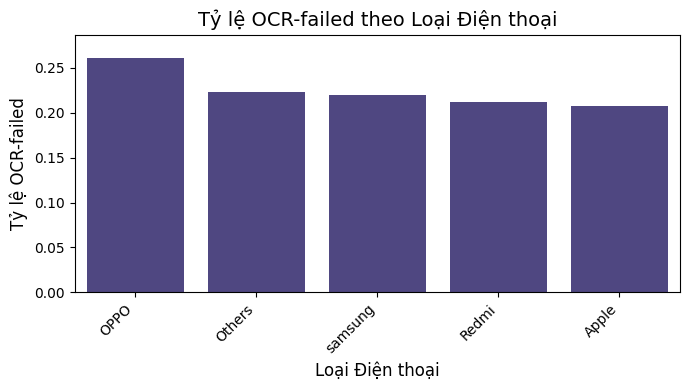

In [125]:
# Tạo cột phone_type_grouped trong df_eda
# Tính tỷ lệ từng loại phone_type trong df_eda
phone_counts_eda = df_eda['phone_type'].value_counts(normalize=True)

# Gộp các loại < 1% thành 'Others' trong df_eda
phone_map_eda = phone_counts_eda[phone_counts_eda >= 0.01].index.tolist()
df_eda['phone_type_grouped'] = df_eda['phone_type'].apply(lambda x: x if x in phone_map_eda else 'Others')


print("\nTỷ lệ OCR-failed theo Loại Điện thoại:")
ocr_fail_rate_by_phone = df_eda.groupby('phone_type_grouped')['is_ocr_failed'].mean().sort_values(ascending=False)
print(ocr_fail_rate_by_phone)

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.barplot(x=ocr_fail_rate_by_phone.index, y=ocr_fail_rate_by_phone.values, color='darkslateblue')
plt.title('Tỷ lệ OCR-failed theo Loại Điện thoại', fontsize=14)
plt.xlabel('Loại Điện thoại', fontsize=12)
plt.ylabel('Tỷ lệ OCR-failed', fontsize=12)
plt.ylim(0, ocr_fail_rate_by_phone.max() * 1.1)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if they overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


Tỷ lệ OTP-failed theo Loại Điện thoại:
phone_type_grouped
Apple      0.223103
OPPO       0.202216
samsung    0.202079
Redmi      0.201245
Others     0.176802
Name: is_otp_failed, dtype: float64

Vẽ biểu đồ Tỷ lệ OTP-failed theo Loại Điện thoại...


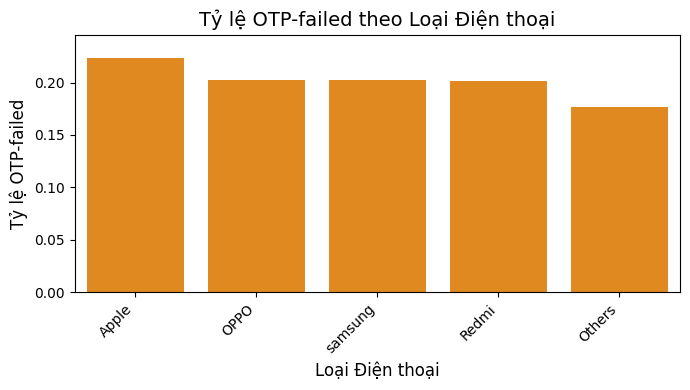


Đã hoàn thành phân tích và vẽ biểu đồ cho OTP-failed theo Loại Điện thoại.


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử DataFrame df_eda đã được tải và có cột 'stop_point' và 'phone_type_grouped'

# --- Bước 1: Tạo cột boolean/integer đánh dấu sự kiện 'otp-failed' ---
# Điều này giúp dễ dàng tính tỷ lệ bằng cách tính trung bình sau khi nhóm
df_eda['is_otp_failed'] = (df_eda['stop_point'] == 'otp-failed').astype(int) # Chuyển True/False thành 1/0

# --- Bước 2: Tính tỷ lệ 'otp-failed' theo từng nhóm Loại Điện thoại ---
# Nhóm theo 'phone_type_grouped' và tính trung bình của cột 'is_otp_failed'
# .mean() của cột 0/1 sẽ cho tỷ lệ các giá trị là 1 (lỗi OTP)
otp_fail_rate_by_phone = df_eda.groupby('phone_type_grouped')['is_otp_failed'].mean().sort_values(ascending=False)

print("\nTỷ lệ OTP-failed theo Loại Điện thoại:")
print(otp_fail_rate_by_phone)

# --- Bước 3: Trực quan hóa bằng biểu đồ cột ---

print("\nVẽ biểu đồ Tỷ lệ OTP-failed theo Loại Điện thoại...")

plt.figure(figsize=(7, 4)) # Kích thước biểu đồ, có thể điều chỉnh

# Sử dụng seaborn barplot. Cần reset index để 'phone_type_grouped' và tỷ lệ trở thành cột
otp_plot_data = otp_fail_rate_by_phone.reset_index()
otp_plot_data.columns = ['phone_type_grouped', 'otp_failed_rate'] # Đổi tên cột cho rõ nghĩa

sns.barplot(data=otp_plot_data, x='phone_type_grouped', y='otp_failed_rate', color='darkorange')

plt.title('Tỷ lệ OTP-failed theo Loại Điện thoại', fontsize=14)
plt.xlabel('Loại Điện thoại', fontsize=12)
plt.ylabel('Tỷ lệ OTP-failed', fontsize=12)
# Đặt giới hạn trục Y để biểu đồ dễ đọc và tránh outlier (nếu có) làm lệch scale
# Lấy max_rate * 1.1 để có khoảng trống trên đỉnh cột cao nhất
plt.ylim(0, otp_plot_data['otp_failed_rate'].max() * 1.1)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục x nếu dài để tránh chồng lấn
plt.tight_layout() # Điều chỉnh layout để tránh bị cắt nhãn
plt.show()

print("\nĐã hoàn thành phân tích và vẽ biểu đồ cho OTP-failed theo Loại Điện thoại.")

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_eda has 'birth_year' to calculate 'age' and 'generation'
# Assuming df_eda is already defined from previous steps

# Define the categorize_generation function again if needed
def categorize_generation(age):
    if pd.isna(age): # Handle potential NaN values in age
        return np.nan
    elif age >= 60:
        return 'Boomers'
    elif 44 <= age < 60:
        return 'Gen X'
    elif 28 <= age < 44:
        return 'Gen Y (Millennials)'
    elif age < 28:
        return 'Gen Z'
    else: # Handle any other cases, though bins should cover all ages
        return np.nan

# Create 'age' and 'generation' columns in df_eda
# Assuming 'birth_year' is already present in df_eda from the cleaning steps
df_eda['age'] = 2024 - df_eda['birth_year']
df_eda['generation'] = df_eda['age'].apply(categorize_generation)

# Now, you can perform the groupby operation
ocr_fail_rate_generation = df_eda.groupby('generation')['is_ocr_failed'].mean().dropna()
print(ocr_fail_rate_generation)

generation
Boomers                0.451264
Gen X                  0.201572
Gen Y (Millennials)    0.202046
Gen Z                  0.230379
Name: is_ocr_failed, dtype: float64


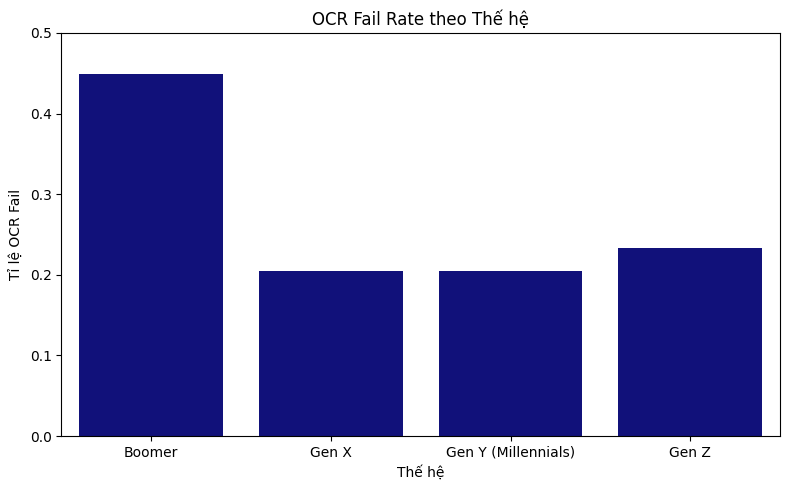

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo dataframe từ dữ liệu ocr_fail_rate_dropna
ocr_fail_rate_generation = pd.Series({
    'Boomer': 0.448905,
    'Gen X': 0.204923,
    'Gen Y (Millennials)': 0.204947,
    'Gen Z': 0.232698
}, name='is_ocr_failed')

# Chuyển thành DataFrame để dễ trực quan hóa
ocr_fail_df = ocr_fail_rate_generation.reset_index()
ocr_fail_df.columns = ['generation', 'ocr_fail_rate']

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 5))
sns.barplot(data=ocr_fail_df, x='generation', y='ocr_fail_rate', color='darkblue')
plt.title('OCR Fail Rate theo Thế hệ')
plt.ylabel('Tỉ lệ OCR Fail')
plt.xlabel('Thế hệ')
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

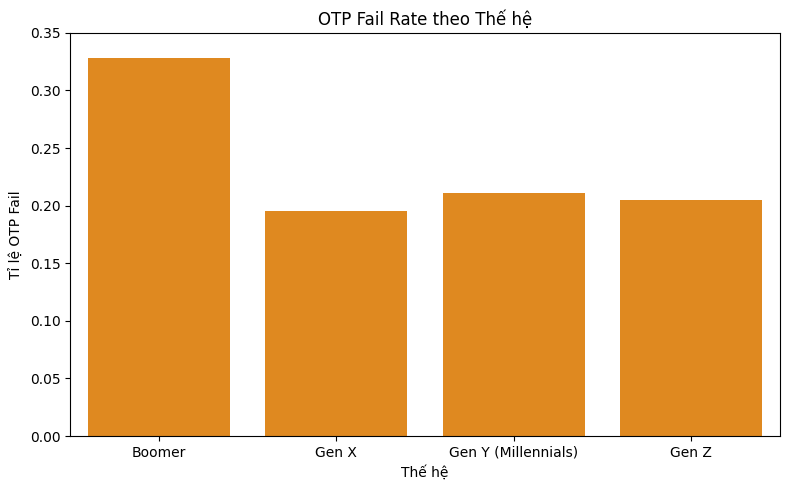

In [129]:
# Tạo dataframe từ dữ liệu otp_fail_rate_dropna
otp_fail_rate_generation = pd.Series({
    'Boomer':  0.328520,
    'Gen X': 0.195764,
    'Gen Y (Millennials)': 0.211150,
    'Gen Z':  0.205057
}, name='is_otp_failed')

# Chuyển thành DataFrame để dễ trực quan hóa
otp_fail_df = otp_fail_rate_generation.reset_index()
otp_fail_df.columns = ['generation', 'otp_fail_rate']

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 5))
sns.barplot(data=otp_fail_df, x='generation', y='otp_fail_rate', color='darkorange')
plt.title('OTP Fail Rate theo Thế hệ')
plt.ylabel('Tỉ lệ OTP Fail')
plt.xlabel('Thế hệ')
plt.ylim(0, 0.35)
plt.tight_layout()
plt.show()

In [130]:
ocr_fail_rate_gender = df_eda.groupby('gender')['is_ocr_failed'].mean().dropna()
print(ocr_fail_rate_gender)

gender
F    0.201332
M    0.221059
Name: is_ocr_failed, dtype: float64


In [131]:
otp_fail_rate_gender = df_eda.groupby('gender')['is_otp_failed'].mean().dropna()
print(otp_fail_rate_gender)

gender
F    0.219865
M    0.215513
Name: is_otp_failed, dtype: float64


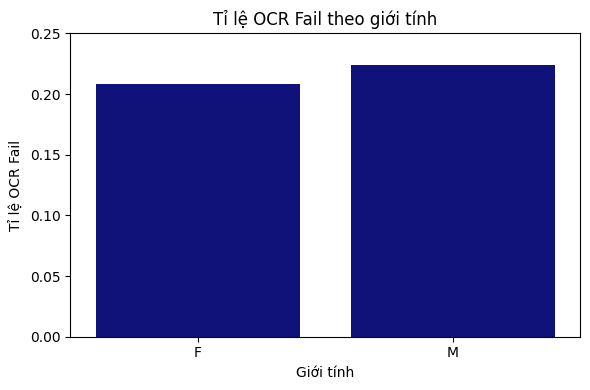

In [132]:
# Trực quan hóa chỉ riêng tỉ lệ OCR Fail theo giới tính
ocr_fail_rate_gender = pd.Series({'F': 0.208337, 'M': 0.224254}, name='ocr_fail_rate')

# Chuyển thành DataFrame để trực quan
ocr_fail_df = ocr_fail_rate_gender.reset_index()
ocr_fail_df.columns = ['gender', 'ocr_fail_rate']

# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
sns.barplot(data=ocr_fail_df, x='gender', y='ocr_fail_rate', color='darkblue')
plt.title('Tỉ lệ OCR Fail theo giới tính')
plt.ylabel('Tỉ lệ OCR Fail')
plt.xlabel('Giới tính')
plt.ylim(0, 0.25)
plt.tight_layout()
plt.show()

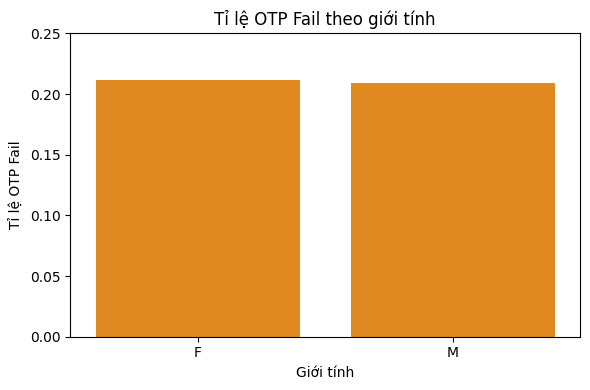

In [133]:
# Trực quan hóa chỉ riêng tỉ lệ OTP Fail theo giới tính
otp_fail_rate_gender = pd.Series({'F': 0.211301, 'M': 0.208879}, name='otp_fail_rate')

# Chuyển thành DataFrame để trực quan
otp_fail_df = otp_fail_rate_gender.reset_index()
otp_fail_df.columns = ['gender', 'otp_fail_rate']

# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
sns.barplot(data=otp_fail_df, x='gender', y='otp_fail_rate', color='darkorange')
plt.title('Tỉ lệ OTP Fail theo giới tính')
plt.ylabel('Tỉ lệ OTP Fail')
plt.xlabel('Giới tính')
plt.ylim(0, 0.25)
plt.tight_layout()
plt.show()

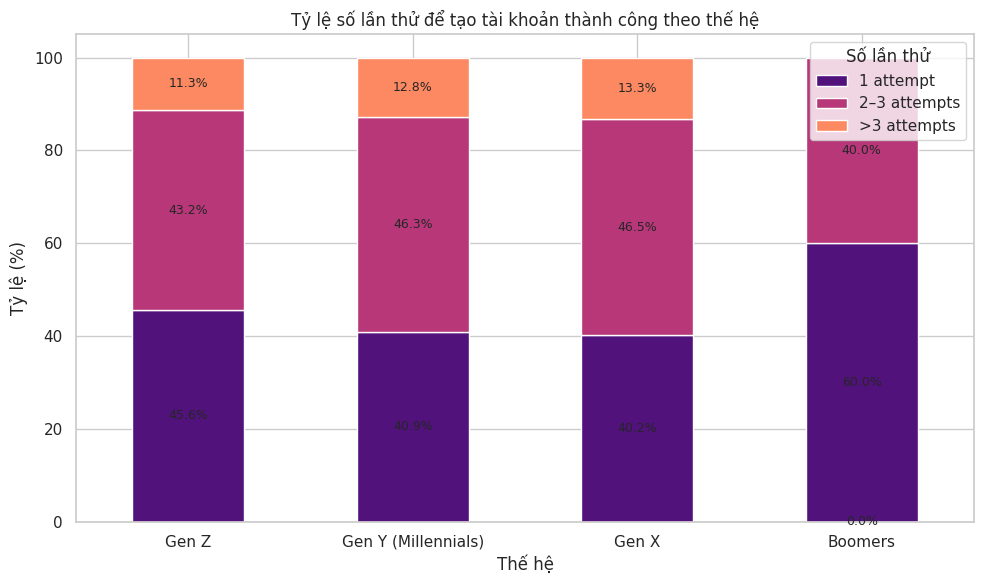

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đếm số lần thử của mỗi customer_id
attempt_counts = df_eda.groupby('customer_id').size().reset_index(name='num_attempts')

# Sắp xếp theo thời gian để lấy dòng cuối cùng cho mỗi customer_id
df_sorted = df_eda.sort_values(by=['customer_id', 'begin_time'])

# Lấy dòng cuối cùng (trạng thái cuối + generation)
last_status = df_sorted.groupby('customer_id').last().reset_index()
last_status = last_status[['customer_id', 'status', 'generation']]

# Gộp dữ liệu
attempt_data = pd.merge(last_status, attempt_counts, on='customer_id')

# Chỉ giữ khách hàng tạo tài khoản thành công
succeeded = attempt_data[attempt_data['status'] == 'succeed'].copy()

# Nhóm theo số lần thử
def attempt_category(n):
    if n == 1:
        return '1 attempt'
    elif 2 <= n <= 3:
        return '2–3 attempts'
    else:
        return '>3 attempts'

succeeded['attempt_group'] = succeeded['num_attempts'].apply(attempt_category)

# Tạo bảng pivot: số khách theo generation và số lần thử
pivot_attempts = succeeded.groupby(['generation', 'attempt_group'])['customer_id'] \
    .nunique().reset_index()

pivot_attempts = pivot_attempts.pivot(index='generation',
                                      columns='attempt_group',
                                      values='customer_id').fillna(0).astype(int)

# Sắp xếp thứ tự thế hệ
generation_order = ['Gen Z', 'Gen Y (Millennials)', 'Gen X', 'Boomers']
pivot_attempts = pivot_attempts.reindex(generation_order)

# Tính phần trăm theo hàng (generation)
pivot_attempts_percent = pivot_attempts.div(pivot_attempts.sum(axis=1), axis=0) * 100

# Vẽ stacked bar chart
sns.set(style="whitegrid")
ax = pivot_attempts_percent.plot(kind='bar', figsize=(10, 6), stacked=True,
                                 color=sns.color_palette('magma', n_colors=pivot_attempts_percent.shape[1]))

plt.title('Tỷ lệ số lần thử để tạo tài khoản thành công theo thế hệ')
plt.xlabel('Thế hệ')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Số lần thử', loc='upper right')

# Ghi nhãn phần trăm vào giữa cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.tight_layout()
plt.show()


In [135]:
# Đếm số dòng có age > 100
count_age = df_eda[df_eda['age'] > 100].shape[0]
print(f"Số dòng có age > 100: {count_age}")


Số dòng có age > 100: 2


In [136]:
# --- 1. Thay age > 100 bằng trung bình các age hợp lệ ---
valid_age_mean = df_eda.loc[df_eda['age'] <= 100, 'age'].mean()
df_eda.loc[df_eda['age'] > 100, 'age'] = round(valid_age_mean)
count_age = df_eda[df_eda['age'] > 100].shape[0]
print(f"Số dòng có age > 100: {count_age}")

df_cleaned = df_eda.copy()

Số dòng có age > 100: 0


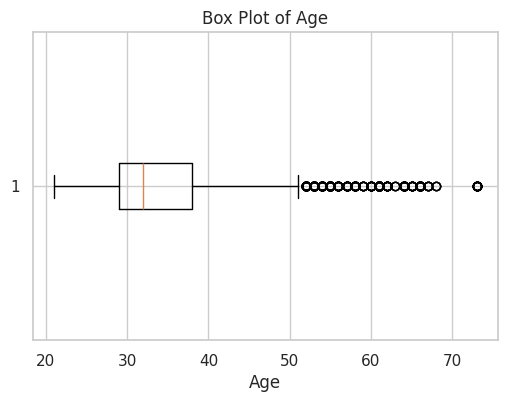

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử bạn đã đọc dữ liệu vào DataFrame tên là df_eda
# df_eda = pd.read_csv("your_file.csv")  # nếu bạn cần đọc từ file

# Vẽ box plot cho cột age
plt.figure(figsize=(6, 4))
plt.boxplot(df_eda['age'].dropna(), vert=False)
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.grid(True)
plt.show()


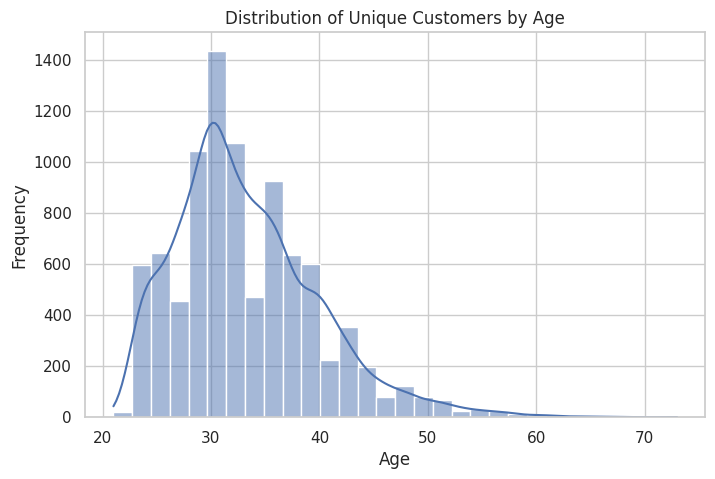

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc chỉ giữ lại mỗi customer_id một lần
df_customer = df_eda.drop_duplicates(subset='customer_id')

# Vẽ biểu đồ phân phối cho cột age đã lọc trùng
plt.figure(figsize=(8, 5))
sns.histplot(df_customer['age'], kde=True, bins=30)
plt.title('Distribution of Unique Customers by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [139]:
df_eda.age.describe()

,age
count,25746.000000
mean,33.761866
std,7.230981
min,21.000000
25%,29.000000
50%,32.000000
75%,38.000000
max,73.000000


/tmp/ipykernel_17872/3527545110.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_customer, x='gender', palette='pastel')


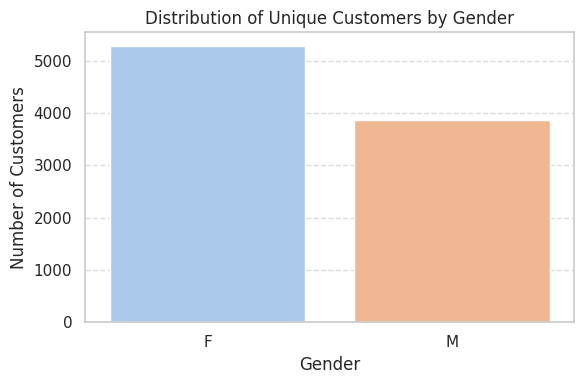

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(6, 4))

# Vẽ biểu đồ đếm số lượng khách hàng theo giới tính
sns.countplot(data=df_customer, x='gender', palette='pastel')

# Thiết lập tiêu đề và nhãn
plt.title('Distribution of Unique Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_17872/3751691845.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['phone_type_grouped'] = df_customer['phone_type'].apply(lambda x: x if x in phone_map else 'Others')
/tmp/ipykernel_17872/3751691845.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_customer, x='phone_type_grouped', order=sorted_order, palette='Set3')


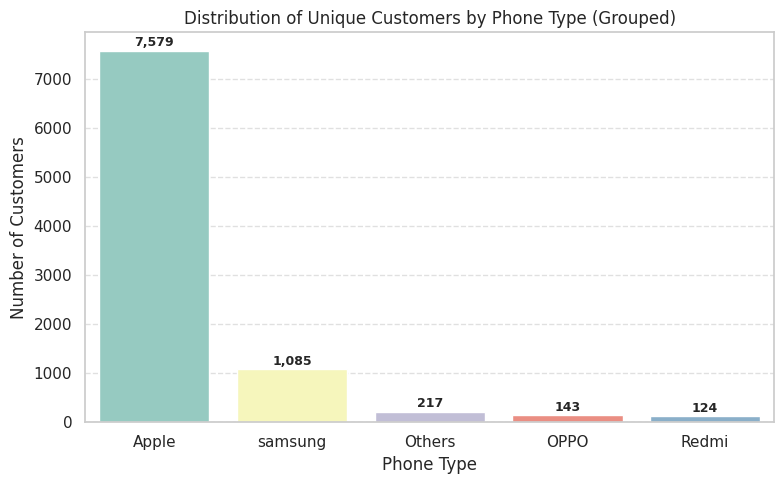

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Bước 1: Tính tỷ lệ từng loại phone_type
phone_counts = df_customer['phone_type'].value_counts(normalize=True)

# Bước 2: Gộp các loại < 1% thành 'Others'
phone_map = phone_counts[phone_counts >= 0.01].index.tolist()
df_customer['phone_type_grouped'] = df_customer['phone_type'].apply(lambda x: x if x in phone_map else 'Others')

# Bước 3: Sắp xếp theo số lượng giảm dần
sorted_order = df_customer['phone_type_grouped'].value_counts().index

# Bước 4: Vẽ biểu đồ với data label
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_customer, x='phone_type_grouped', order=sorted_order, palette='Set3')

# Thêm nhãn số lên trên từng cột
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 30,
        s=f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Trang trí
plt.title('Distribution of Unique Customers by Phone Type (Grouped)')
plt.xlabel('Phone Type')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [142]:
import pandas as pd

# Đảm bảo cột thời gian là datetime
df_eda['begin_time'] = pd.to_datetime(df_eda['begin_time'])

# Trích xuất ngày (yyyy-mm-dd)
df_eda['date'] = df_eda['begin_time'].dt.date

# Nhóm theo ngày và đếm số lượng unique khách hàng
top_days = df_eda.groupby('date')['customer_id'].nunique().sort_values(ascending=False).head(5)

# Hiển thị kết quả
print("Top 5 ngày có số lượng mở tài khoản cao nhất:")
print(top_days)


Top 5 ngày có số lượng mở tài khoản cao nhất:
date
2024-03-01    3018
2024-02-29    2408
2024-03-14     658
2024-03-04     646
2024-02-28     617
Name: customer_id, dtype: int64


/tmp/ipykernel_17872/1063259447.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])
/tmp/ipykernel_17872/1063259447.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['day_of_month'] = df_customer['begin_time'].dt.day


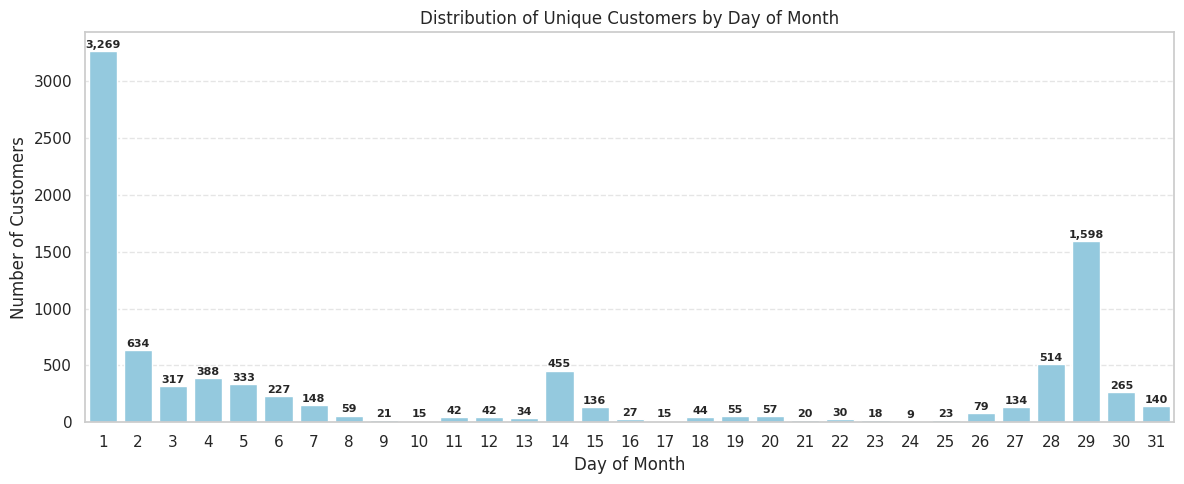

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Đảm bảo cột thời gian đúng định dạng
df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])

# Trích xuất ngày trong tháng
df_customer['day_of_month'] = df_customer['begin_time'].dt.day

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df_customer, x='day_of_month', color='skyblue')

# Thêm data labels
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 10,
        s=f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

# Trang trí
plt.title('Distribution of Unique Customers by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


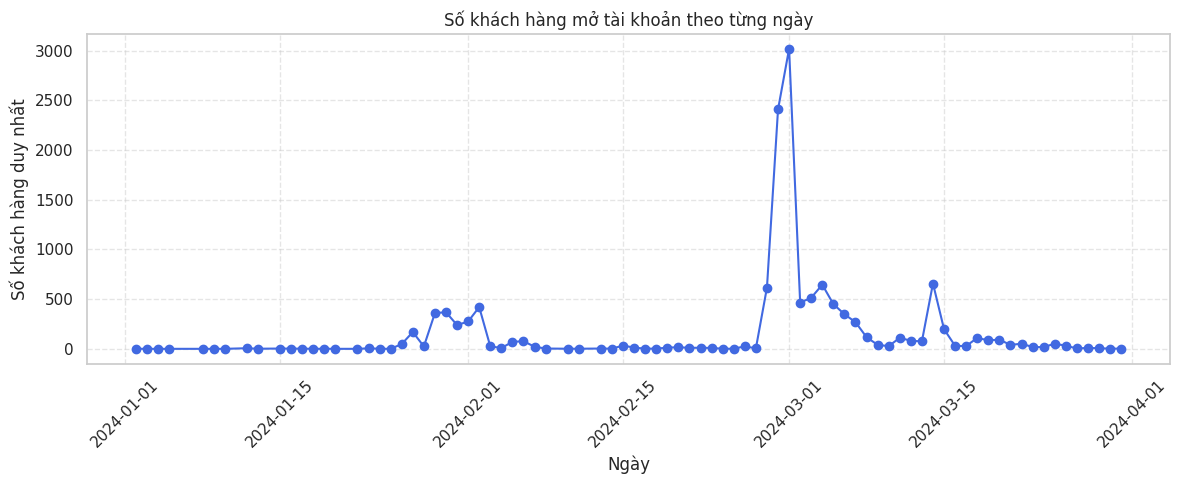

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

# Đảm bảo begin_time là datetime
df_eda['begin_time'] = pd.to_datetime(df_eda['begin_time'])

# Tạo cột ngày (yyyy-mm-dd)
df_eda['date'] = df_eda['begin_time'].dt.date

# Đếm số khách hàng duy nhất theo ngày
customers_by_date = df_eda.groupby('date')['customer_id'].nunique().reset_index()
customers_by_date.columns = ['Date', 'Unique_Customers']

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 5))
plt.plot(customers_by_date['Date'], customers_by_date['Unique_Customers'], marker='o', linestyle='-', color='royalblue')

# Trang trí biểu đồ
plt.title('Số khách hàng mở tài khoản theo từng ngày')
plt.xlabel('Ngày')
plt.ylabel('Số khách hàng duy nhất')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_17872/2328891751.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])
/tmp/ipykernel_17872/2328891751.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer['period'] = df_customer['begin_time'].dt.hour.apply(classify_period)


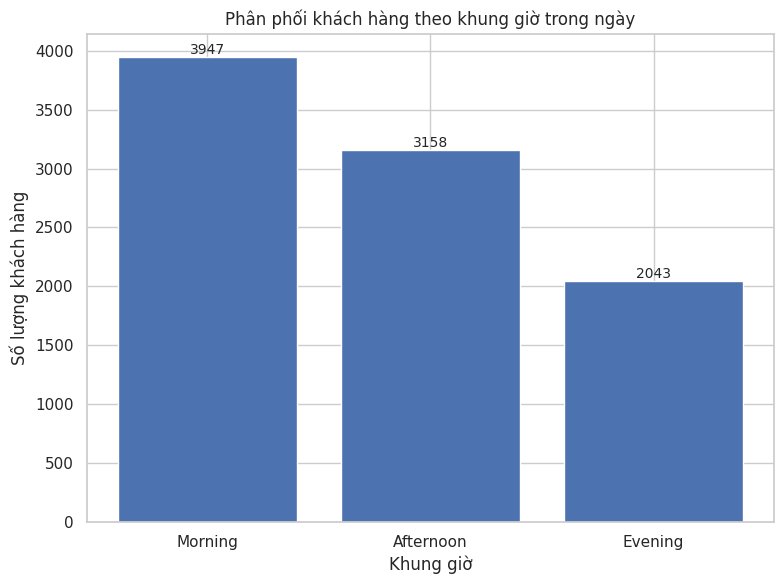

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# Chuyển đổi cột thời gian
df_customer['begin_time'] = pd.to_datetime(df_customer['begin_time'])

# Phân loại theo buổi
def classify_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df_customer['period'] = df_customer['begin_time'].dt.hour.apply(classify_period)

# Thống kê
period_counts = df_customer['period'].value_counts().reindex(['Morning', 'Afternoon', 'Evening'])

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
bars = plt.bar(period_counts.index, period_counts.values)

# Thêm data label
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{int(height)}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.title('Phân phối khách hàng theo khung giờ trong ngày')
plt.xlabel('Khung giờ')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



>>> Phân tích biến 'stop_point':
stop_point
otp-failed               5612
ocr-failed               5404
data-privacy-rejected    2398
contract-rejected        1785
check-failed             1632
selfie-failed             372
Name: count, dtype: int64


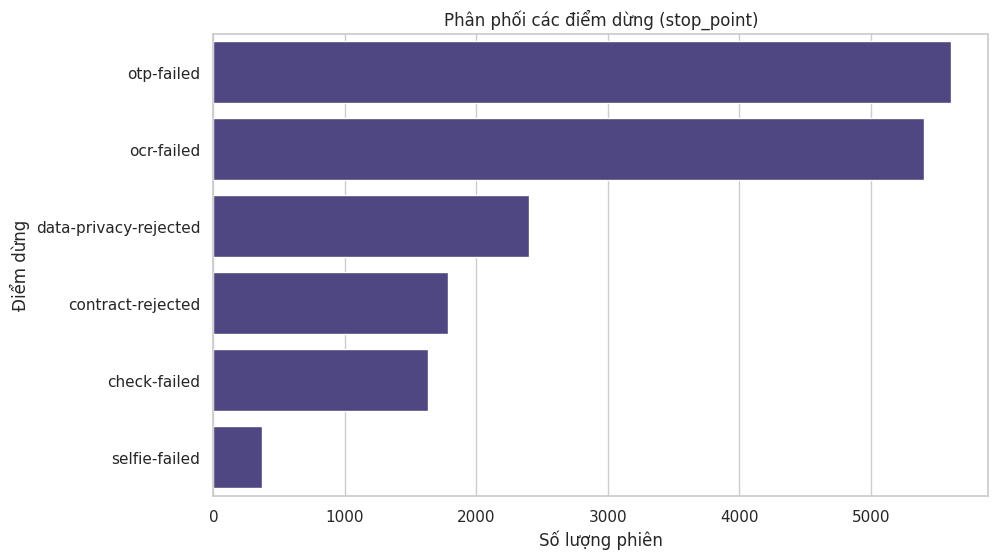

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n>>> Phân tích biến 'stop_point':")
stop_point_counts = df_eda['stop_point'].value_counts()
# Đếm stop_point và loại bỏ 'account-creation'
stop_point_counts = stop_point_counts[stop_point_counts.index != 'account-creation']

print(stop_point_counts)
# Trực quan hóa, xoay nhãn nếu có nhiều điểm dừng
plt.figure(figsize=(10, 6))
# Sử dụng argument color thay cho palette nếu chỉ muốn 1 màu duy nhất cho tất cả các cột
sns.countplot(data=df_eda, y='stop_point', order=stop_point_counts.index, color='darkslateblue')

plt.title('Phân phối các điểm dừng (stop_point)')
plt.xlabel('Số lượng phiên')
plt.ylabel('Điểm dừng')
plt.show()

In [147]:
import pandas as pd

# --- Bước 1: Đảm bảo cột thời gian có định dạng datetime ---
# Kiểm tra kiểu dữ liệu của cột 'begin_time'. Nếu chưa phải datetime, chuyển đổi:
# df['begin_time'] = pd.to_datetime(df['begin_time'])
# df['close_time'] = pd.to_datetime(df['close_time'])
# Giả sử nó đã là datetime hoặc string có thể parse được.

# --- Bước 2-4: Nhóm, Sắp xếp và Tìm vị trí 'account-creation' đầu tiên ---

# Định nghĩa hàm tìm vị trí 0-based đầu tiên của 'account-creation' trong một Series
def find_first_account_creation_position(series):
    try:
        # Tìm vị trí 0-based của giá trị 'account-creation'
        # series.tolist() chuyển Series thành list để dùng phương thức index()
        position = series.tolist().index('account-creation')
        return position
    except ValueError:
        # Trả về giá trị đặc biệt (ví dụ: -1) nếu không tìm thấy 'account-creation'
        return -1

# Áp dụng hàm sau khi nhóm theo customer_id và sắp xếp theo thời gian
# groupby('customer_id'): Nhóm DataFrame theo customer_id
# apply(lambda x: ...): Áp dụng hàm cho mỗi nhóm (DataFrame con của 1 customer_id)
#   x.sort_values(by='begin_time')['stop_point']: Sắp xếp nhóm theo thời gian và chọn cột 'stop_point'.
#   find_first_account_creation_position(...): Tìm vị trí đầu tiên của 'account-creation' trong chuỗi stop_point đã sắp xếp.
# Kết quả: Series với index là customer_id, value là vị trí 0-based (-1 nếu không có).
first_ac_positions = df_eda.groupby('customer_id').apply(
    lambda x: find_first_account_creation_position(x.sort_values(by='begin_time')['stop_point'])
)

# --- Bước 5: Đếm số lượng customer_id theo các khoảng vị trí mới ---

# Lọc ra những customer_id mà 'account-creation' có xuất hiện (vị trí >= 0)
customers_with_ac = first_ac_positions[first_ac_positions != -1]

# Đếm số lượng customer_id theo các điều kiện vị trí:
# Vị trí 0: 'account creation' xuất hiện đầu tiên (0 phiên thử trước đó)
count_pos_0 = (customers_with_ac == 0).sum()

# Vị trí 1, 2, hoặc 3: 'account creation' xuất hiện sau 1 đến 3 phiên thử
# Vị trí 0 là phiên 1, vị trí 1 là phiên 2, vị trí 2 là phiên 3, vị trí 3 là phiên 4.
# Xuất hiện sau 1-3 phiên thử nghĩa là ở vị trí 1, 2, hoặc 3 (phiên 2, 3, hoặc 4).
count_pos_1_to_3 = (customers_with_ac.isin([1, 2, 3])).sum()

# Vị trí >= 4: 'account creation' xuất hiện từ phiên thứ 5 trở đi (sau nhiều hơn 3 phiên thử)
# Vị trí 4 là phiên 5, vị trí 5 là phiên 6, ...
count_pos_geq_4 = (customers_with_ac >= 4).sum()


# In kết quả
print(f"Số lượng customer_id duy nhất có 'account-creation' xuất hiện đầu tiên (vị trí 0): {count_pos_0}")
print(f"Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau 1-3 phiên thử (vị trí 1, 2, hoặc 3): {count_pos_1_to_3}")
print(f"Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau nhiều hơn 3 phiên thử (vị trí 4 trở lên): {count_pos_geq_4}")

# (Tùy chọn) Kiểm tra tổng số customer có 'account-creation'
# print(f"\nTổng số customer_id duy nhất có 'account-creation' xuất hiện: {len(customers_with_ac)}")
# print(f"Tổng kiểm tra: {count_pos_0 + count_pos_1_to_3 + count_pos_geq_4}")

Số lượng customer_id duy nhất có 'account-creation' xuất hiện đầu tiên (vị trí 0): 3731
Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau 1-3 phiên thử (vị trí 1, 2, hoặc 3): 4032
Số lượng customer_id duy nhất có 'account-creation' xuất hiện sau nhiều hơn 3 phiên thử (vị trí 4 trở lên): 780


/tmp/ipykernel_17872/1328565346.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_ac_positions = df_eda.groupby('customer_id').apply(


###Phân tích nhóm khách hàng rời bỏ

In [148]:
# Lọc các customer_id chưa từng có trạng thái "succeed"
unsuccessful_customers = df_eda.groupby('customer_id')['status'].apply(lambda x: 'succeed' not in x.values)
# Lấy danh sách customer_id không có "succeed"
no_succeed_ids = unsuccessful_customers[unsuccessful_customers].index

# Lọc ra các dòng trong df_eda tương ứng với nhóm khách hàng này
df_no_succeed = df_eda[df_eda['customer_id'].isin(no_succeed_ids)]

In [149]:
df_no_succeed.customer_id.nunique()

605

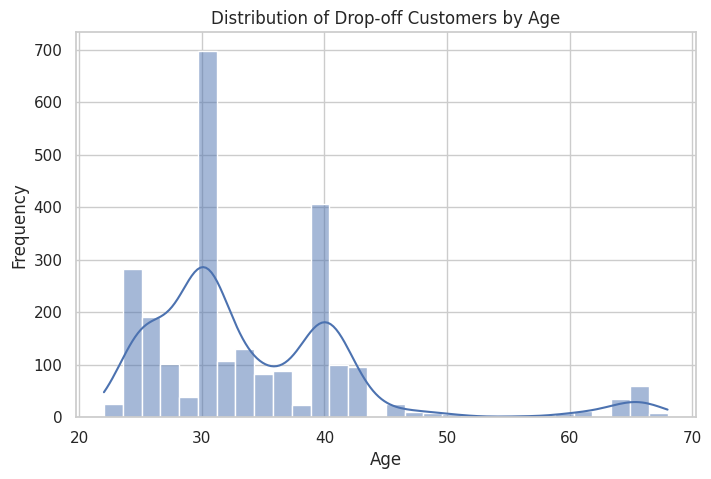

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns


# Vẽ biểu đồ phân phối cho cột age đã lọc trùng
plt.figure(figsize=(8, 5))
sns.histplot(df_no_succeed['age'], kde=True, bins=30)
plt.title('Distribution of Drop-off Customers by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


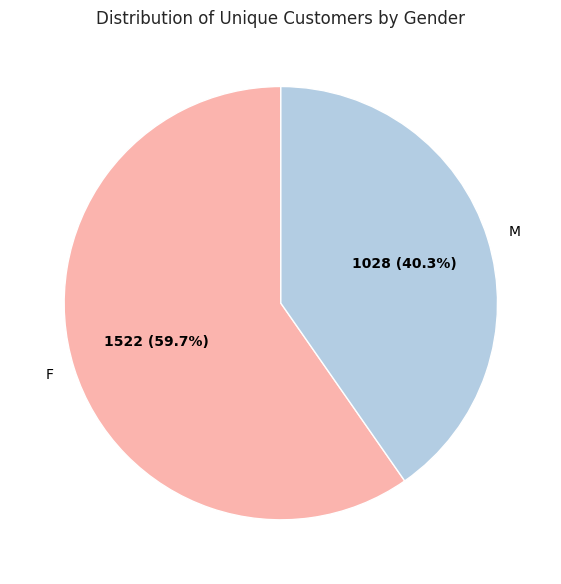

In [151]:
import matplotlib.pyplot as plt

# Tính số lượng và phần trăm theo giới tính
gender_counts = df_no_succeed['gender'].value_counts()
gender_percent = gender_counts / gender_counts.sum() * 100

# Vẽ biểu đồ tròn với nhãn bên trong
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct=lambda pct: f'{int(round(pct/100 * gender_counts.sum()))} ({pct:.1f}%)',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    textprops=dict(color='black', fontsize=10)
)

# Căn giữa và thêm tiêu đề
plt.setp(autotexts, size=10, weight='bold')
plt.title('Distribution of Unique Customers by Gender')
plt.tight_layout()
plt.show()


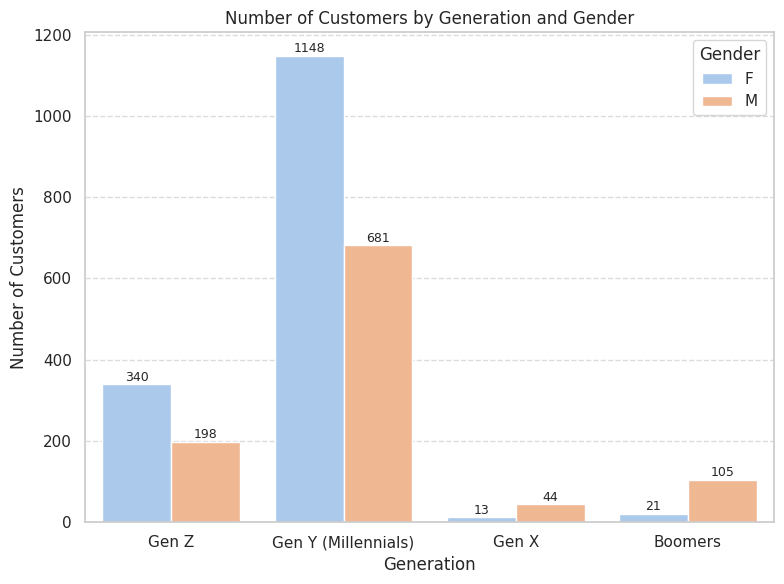

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ cột có phân loại theo giới tính (gender)
ax = sns.countplot(data=df_no_succeed, x='generation', hue='gender', palette='pastel')

# Thêm data label trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 1,
            s=f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Thiết lập tiêu đề và nhãn
plt.title('Number of Customers by Generation and Gender')
plt.xlabel('Generation')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


/tmp/ipykernel_17872/40780365.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_succeed['phone_type_grouped'] = df_no_succeed['phone_type'].apply(lambda x: x if x in phone_map else 'Others')
/tmp/ipykernel_17872/40780365.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_no_succeed, x='phone_type_grouped', order=sorted_order, palette='Set3')


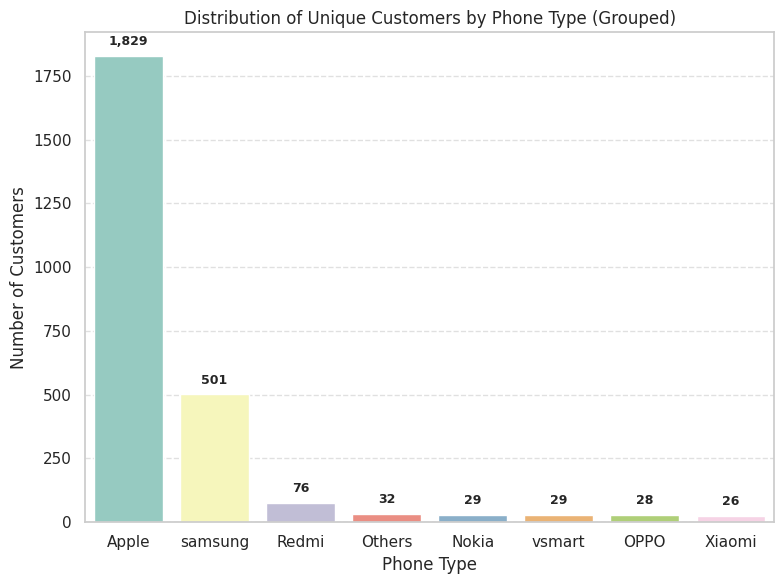

device_system_name
iOS        1818
Android     721
iPadOS       11
Name: count, dtype: int64


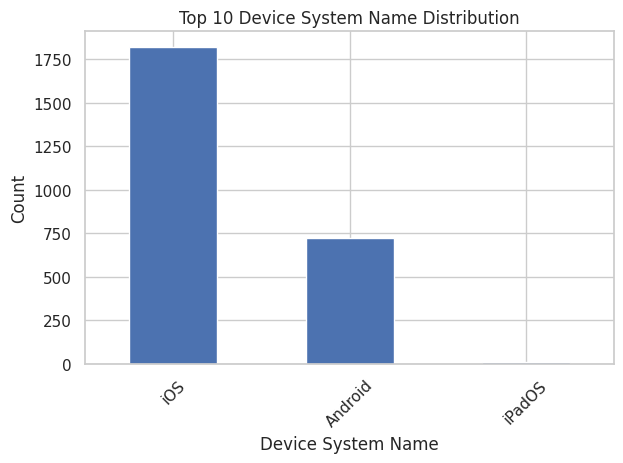

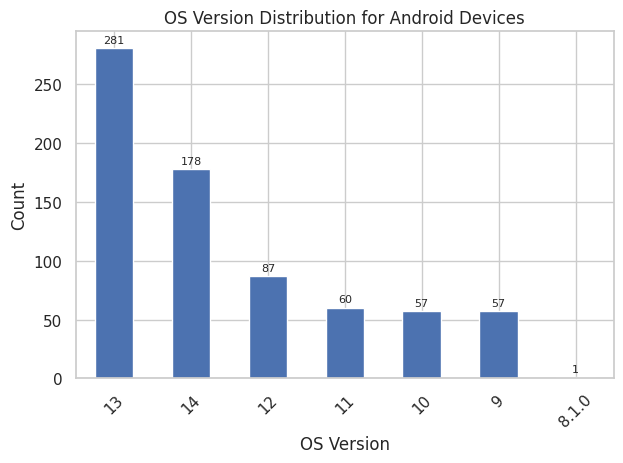

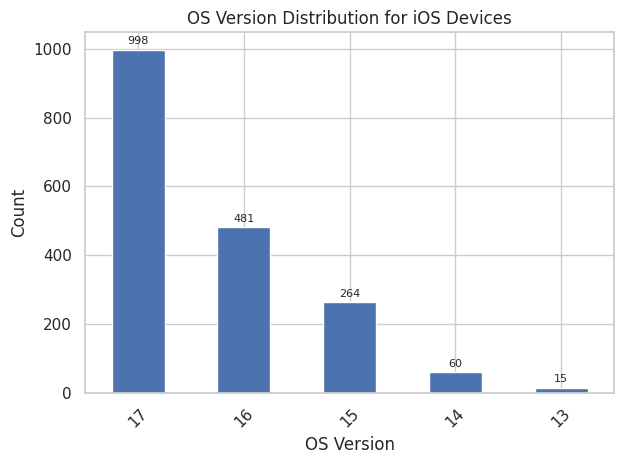

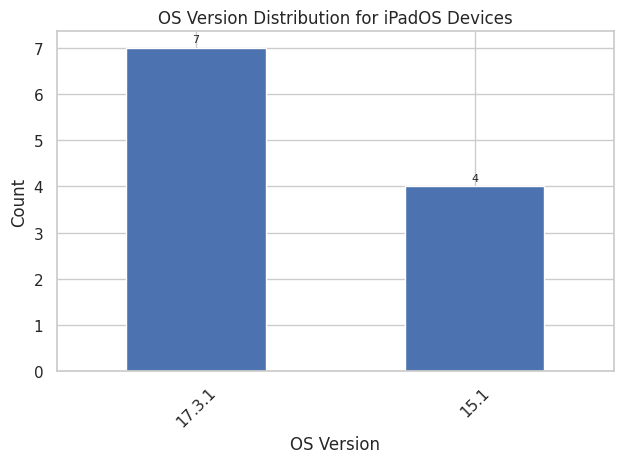

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Bước 1: Tính tỷ lệ từng loại phone_type
phone_counts = df_no_succeed['phone_type'].value_counts(normalize=True)

# Bước 2: Gộp các loại < 1% thành 'Others'
phone_map = phone_counts[phone_counts >= 0.01].index.tolist()
df_no_succeed['phone_type_grouped'] = df_no_succeed['phone_type'].apply(lambda x: x if x in phone_map else 'Others')

# Bước 3: Sắp xếp theo số lượng giảm dần
sorted_order = df_no_succeed['phone_type_grouped'].value_counts().index

# Bước 4: Vẽ biểu đồ với data label
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_no_succeed, x='phone_type_grouped', order=sorted_order, palette='Set3')

# Thêm nhãn số lên trên từng cột
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 30,
        s=f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Trang trí
plt.title('Distribution of Unique Customers by Phone Type (Grouped)')
plt.xlabel('Phone Type')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Phân phối tần suất của device_system_name
distribution = df_no_succeed['device_system_name'].value_counts(dropna=False)

# Hiển thị kết quả
print(distribution)
import matplotlib.pyplot as plt

# Vẽ biểu đồ bar
distribution.head(10).plot(kind='bar')  # chỉ hiển thị 10 hệ điều hành phổ biến nhất
plt.title('Top 10 Device System Name Distribution')
plt.xlabel('Device System Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


import pandas as pd
import matplotlib.pyplot as plt

# --- Tạo bản sao để xử lý ---
df_temp = df_no_succeed.copy()

# --- Gom nhóm iOS theo major version ---
df_temp.loc[df_temp['device_system_name'] == 'iOS', 'os_version'] = (
    df_temp.loc[df_temp['device_system_name'] == 'iOS', 'os_version']
    .astype(str)
    .str.extract(r'^(\d+)', expand=False)  # Lấy phần số trước dấu chấm
)

# --- Phân bổ số lượng ---
distribution_count = df_temp.groupby('device_system_name')['os_version'].value_counts().unstack(fill_value=0)

# --- Phân bổ tỷ lệ phần trăm ---
distribution_percent = df_temp.groupby('device_system_name')['os_version'].value_counts(normalize=True).unstack(fill_value=0) * 100

# --- Trực quan hóa với data label ---
target_devices = ['Android', 'iOS', 'iPadOS']

for device in target_devices:
    if device in df_temp['device_system_name'].unique():
        os_dist = df_temp[df_temp['device_system_name'] == device]['os_version'].value_counts()

        plt.figure()
        ax = os_dist.plot(kind='bar')
        plt.title(f'OS Version Distribution for {device} Devices')
        plt.xlabel('OS Version')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Thêm nhãn dữ liệu (data labels) trên mỗi cột
        for i, val in enumerate(os_dist.values):
            ax.text(i, val + max(os_dist.values)*0.01, str(val), ha='center', va='bottom', fontsize=8)

        plt.show()
    else:
        print(f"{device} not found in device_system_name.")


/tmp/ipykernel_17872/120217099.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=android_ocr_fail_rate.index, y=android_ocr_fail_rate.values, ax=axes[0, 0], palette="Blues_d")
/tmp/ipykernel_17872/120217099.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ios_ocr_fail_rate.index, y=ios_ocr_fail_rate.values, ax=axes[0, 1], palette="Greens_d")
/tmp/ipykernel_17872/120217099.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=android_otp_fail_rate.index, y=android_otp_fail_rate.values, ax=axes[1, 0], palette="Reds_d")
/tmp/ipykern

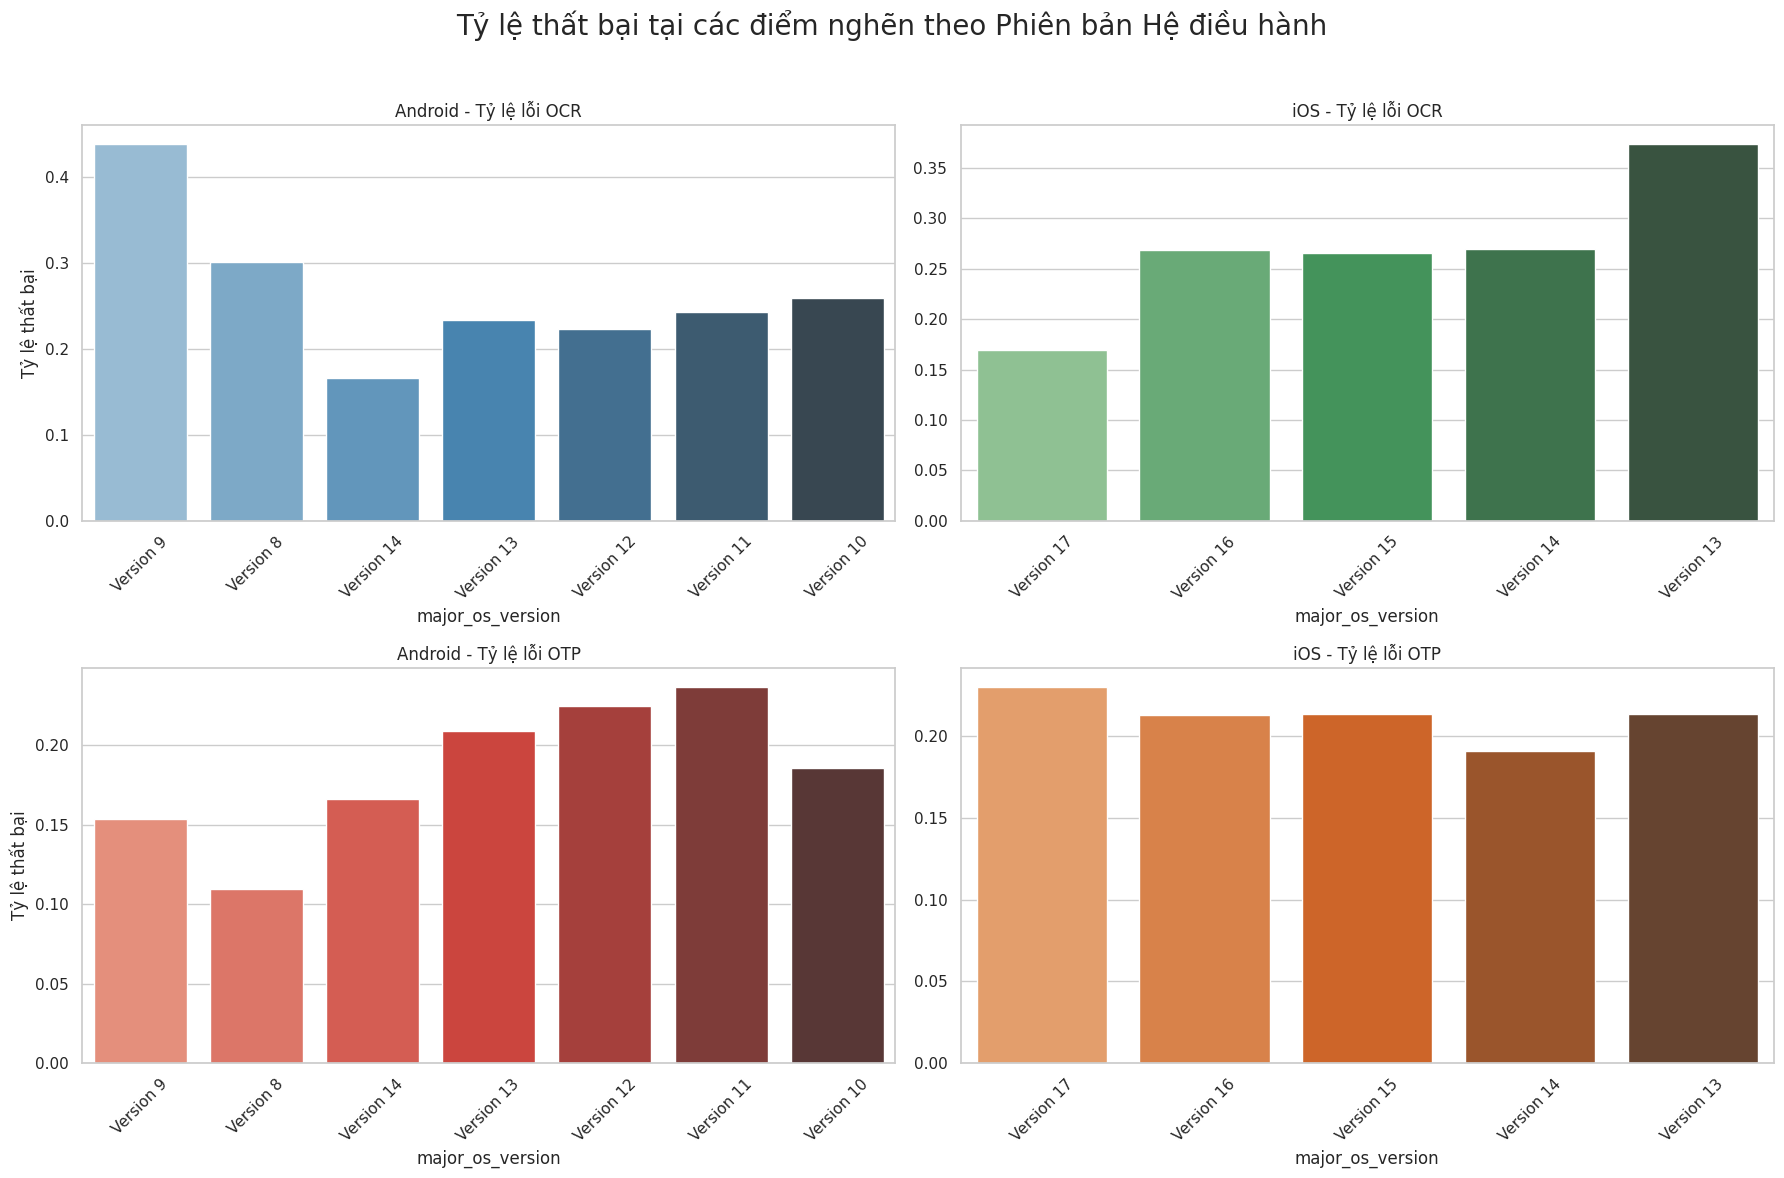

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Giả sử df_cleaned đã tồn tại ---

# --- Bước 1: Chuẩn bị dữ liệu ---
# Tạo cột 'major_os_version' để nhóm các phiên bản lại
def get_major_version(os_str):
    if isinstance(os_str, str):
        # Lấy phần đầu tiên của chuỗi phiên bản (ví dụ: '16.5.1' -> '16')
        match = re.match(r'^\d+', os_str)
        if match:
            return f"Version {match.group(0)}"
    return 'Unknown'

df_cleaned['major_os_version'] = df_cleaned['os_version'].apply(get_major_version)

# Tách riêng Android và iOS
df_android = df_cleaned[df_cleaned['device_system_name'] == 'Android'].copy()
df_ios = df_cleaned[df_cleaned['device_system_name'] == 'iOS'].copy()

# --- Bước 2: Hàm tính tỷ lệ thất bại ---
def calculate_fail_rate(df, stop_point_name, group_col='major_os_version'):
    # Đếm tổng số lượt trong mỗi nhóm
    total_counts = df.groupby(group_col).size()

    # Đếm số lượt thất bại tại điểm nghẽn cụ thể
    fail_counts = df[df['stop_point'] == stop_point_name].groupby(group_col).size()

    # Tính tỷ lệ, điền 0 cho các nhóm không có lỗi
    fail_rate = (fail_counts / total_counts).fillna(0).sort_index(ascending=False)
    return fail_rate

# --- Bước 3: Tính toán tỷ lệ cho từng hệ điều hành ---
# Android
android_ocr_fail_rate = calculate_fail_rate(df_android, 'ocr-failed')
android_otp_fail_rate = calculate_fail_rate(df_android, 'otp-failed')

# iOS
ios_ocr_fail_rate = calculate_fail_rate(df_ios, 'ocr-failed')
ios_otp_fail_rate = calculate_fail_rate(df_ios, 'otp-failed')

# --- Bước 4: Trực quan hóa ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Tỷ lệ thất bại tại các điểm nghẽn theo Phiên bản Hệ điều hành', fontsize=20)

# Biểu đồ 1: Android - OCR Failed
sns.barplot(x=android_ocr_fail_rate.index, y=android_ocr_fail_rate.values, ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title('Android - Tỷ lệ lỗi OCR')
axes[0, 0].set_ylabel('Tỷ lệ thất bại')
axes[0, 0].tick_params(axis='x', rotation=45)

# Biểu đồ 2: iOS - OCR Failed
sns.barplot(x=ios_ocr_fail_rate.index, y=ios_ocr_fail_rate.values, ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title('iOS - Tỷ lệ lỗi OCR')
axes[0, 1].tick_params(axis='x', rotation=45)

# Biểu đồ 3: Android - OTP Failed
sns.barplot(x=android_otp_fail_rate.index, y=android_otp_fail_rate.values, ax=axes[1, 0], palette="Reds_d")
axes[1, 0].set_title('Android - Tỷ lệ lỗi OTP')
axes[1, 0].set_ylabel('Tỷ lệ thất bại')
axes[1, 0].tick_params(axis='x', rotation=45)

# Biểu đồ 4: iOS - OTP Failed
sns.barplot(x=ios_otp_fail_rate.index, y=ios_otp_fail_rate.values, ax=axes[1, 1], palette="Oranges_d")
axes[1, 1].set_title('iOS - Tỷ lệ lỗi OTP')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

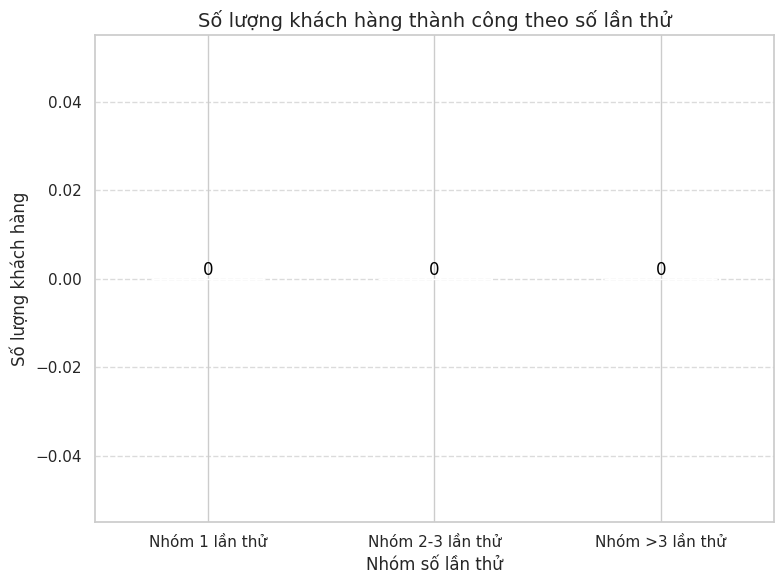

In [155]:
# prompt: trực quan hóa 3 nhóm 1 lần thử, 2-3 lần thử, trên 3 lần thử theo buổi đồ cột, ghi số lượng trên từng cột

# Tính số lượng khách hàng duy nhất trong mỗi nhóm attempt_group
attempt_group_counts = succeeded['attempt_group'].value_counts().reindex(['Nhóm 1 lần thử', 'Nhóm 2-3 lần thử', 'Nhóm >3 lần thử']).fillna(0)

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 6))
ax = attempt_group_counts.plot(kind='bar', color=['#4B8BBE', '#F8C555', '#E06C75'])

# Thêm số lượng trên từng cột
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(),
            f'{int(p.get_height())}',
            fontsize=12, color='black', ha='center', va='bottom')

plt.title('Số lượng khách hàng thành công theo số lần thử', fontsize=14)
plt.xlabel('Nhóm số lần thử', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()